In [1]:
!pip install --upgrade numexpr bottleneck
!pip install ai-edge-litert

In [2]:
import os
import json
import hashlib
import numpy as np
import pandas as pd
from datetime import datetime
import joblib
import tensorflow as tf

from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

In [3]:

DATA_PATH = r"C:\Users\jaymo\OneDrive\Desktop\Desktop\HTA_Internship\USE_CASE_2\iot_health_monitoring_dataset.csv"

MODEL_PATH = r"C:\Users\jaymo\OneDrive\Desktop\Desktop\HTA_Internship\AppCode\m-health-app\model_dev\tiny_uc2_autoencoder.tflite"
SCALER_JOBLIB_PATH = r"C:\Users\jaymo\OneDrive\Desktop\Desktop\HTA_Internship\AppCode\m-health-app\model_dev\tiny_uc2_scaler.joblib"
SCALER_JSON_PATH = r"C:\Users\jaymo\OneDrive\Desktop\Desktop\HTA_Internship\AppCode\m-health-app\model_dev\tiny_uc2_scaler.json"
METADATA_PATH = r"C:\Users\jaymo\OneDrive\Desktop\Desktop\HTA_Internship\AppCode\m-health-app\model_dev\tiny_uc2_metadata.json"

OUTPUT_DIR = "continuous_personalization_sim"
os.makedirs(OUTPUT_DIR, exist_ok=True)

with open(METADATA_PATH, "r") as f:
    metadata = json.load(f)

with open(SCALER_JSON_PATH, "r") as f:
    scaler_json = json.load(f)

scaler = joblib.load(SCALER_JOBLIB_PATH)

FEATURE_ORDER = metadata["feature_cols"]
THRESHOLD = metadata["threshold"]
MODEL_VERSION = metadata.get("model_version", "tiny_ae_uc2_v0.1.0")

print("Loaded metadata")
print("Model version:", MODEL_VERSION)
print("Threshold:", THRESHOLD)
print("Input dim:", len(FEATURE_ORDER))
print("Features:", FEATURE_ORDER)

Loaded metadata
Model version: tiny_ae_uc2_v0.1.0
Threshold: 1.1298478841781616
Input dim: 18
Features: ['heart_rate', 'blood_oxygen', 'blood_pressure_systolic', 'blood_pressure_diastolic', 'glucose_level', 'body_temperature', 'respiratory_rate', 'activity_level', 'sleep_quality', 'stress_level', 'hrv_sdnn', 'steps_count', 'calories_burned', 'pulse_pressure', 'mean_arterial_pressure', 'hour_sin', 'hour_cos', 'is_sleep_window']


In [4]:
df = pd.read_csv(DATA_PATH)
df["timestamp"] = pd.to_datetime(df["timestamp"])

# Binary label for evaluation only
df["event_label"] = (df["health_event"] != 0).astype(int)

# Engineered features
df["pulse_pressure"] = df["blood_pressure_systolic"] - df["blood_pressure_diastolic"]
df["mean_arterial_pressure"] = df["blood_pressure_diastolic"] + (df["pulse_pressure"] / 3.0)

hour = df["timestamp"].dt.hour + df["timestamp"].dt.minute / 60.0
df["hour_sin"] = np.sin(2 * np.pi * hour / 24)
df["hour_cos"] = np.cos(2 * np.pi * hour / 24)

# Same sleep-window logic used during training
df["is_sleep_window"] = df["timestamp"].dt.hour.apply(lambda h: 1 if h >= 22 or h < 6 else 0)

# Safety check
missing = [c for c in FEATURE_ORDER if c not in df.columns]
if missing:
    raise ValueError(f"Missing feature columns: {missing}")

print("Data shape:", df.shape)
print("Label counts:")
print(df["event_label"].value_counts())
print("Health event counts:")
print(df["health_event"].value_counts().sort_index())

Data shape: (5094, 23)
Label counts:
event_label
0    4330
1     764
Name: count, dtype: int64
Health event counts:
health_event
0    4330
1     306
2     267
3     191
Name: count, dtype: int64


In [5]:
import numpy as np
import ai_edge_litert.interpreter as litert  # <-- The new import

class TinyAETFLiteRunner:
    def __init__(self, model_path):
        # Use litert.Interpreter instead of tf.lite.Interpreter
        self.interpreter = litert.Interpreter(model_path=model_path)
        self.interpreter.allocate_tensors()

        self.input_details = self.interpreter.get_input_details()
        self.output_details = self.interpreter.get_output_details()

        print("Input details:", self.input_details)
        print("Output details:", self.output_details)

    def predict_one(self, scaled_vector):
        # Quick safety check: Ensure the input vector has exactly 18 features
        x = np.array(scaled_vector, dtype=np.float32).reshape(1, -1)

        self.interpreter.set_tensor(self.input_details[0]["index"], x)
        self.interpreter.invoke()

        y = self.interpreter.get_tensor(self.output_details[0]["index"])
        return y.reshape(-1)

runner = TinyAETFLiteRunner(MODEL_PATH)


Input details: [{'name': 'serving_default_features:0', 'index': 0, 'shape': array([ 1, 18]), 'shape_signature': array([-1, 18]), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0, 'block_size': 0}, 'sparsity_parameters': {}}]
Output details: [{'name': 'StatefulPartitionedCall_1:0', 'index': 18, 'shape': array([ 1, 18]), 'shape_signature': array([-1, 18]), 'dtype': <class 'numpy.float32'>, 'quantization': (0.0, 0), 'quantization_parameters': {'scales': array([], dtype=float32), 'zero_points': array([], dtype=int32), 'quantized_dimension': 0, 'block_size': 0}, 'sparsity_parameters': {}}]


In [6]:
def build_feature_vector(row):
    """
    Builds raw feature vector in the exact model feature order.
    """
    return np.array([row[col] for col in FEATURE_ORDER], dtype=np.float32)

def scale_vector(raw_vector):
    """
    Uses the original sklearn scaler for notebook simulation.
    Mobile app would use scaler.json.
    """
    return scaler.transform(np.array(raw_vector).reshape(1, -1)).reshape(-1).astype(np.float32)

def mse(a, b):
    a = np.array(a, dtype=np.float32)
    b = np.array(b, dtype=np.float32)
    return float(np.mean((a - b) ** 2))

def hash_vector(vec):
    arr = np.array(vec, dtype=np.float32)
    return hashlib.sha256(arr.tobytes()).hexdigest()

def score_with_tiny_ae(row):
    raw_vector = build_feature_vector(row)
    scaled_vector = scale_vector(raw_vector)
    reconstructed = runner.predict_one(scaled_vector)
    error = mse(scaled_vector, reconstructed)
    anomaly = error > THRESHOLD

    # feature-level reconstruction error
    feature_errors = {
        feature: float((scaled_vector[i] - reconstructed[i]) ** 2)
        for i, feature in enumerate(FEATURE_ORDER)
    }

    top_features = sorted(
        feature_errors.items(),
        key=lambda x: x[1],
        reverse=True
    )[:5]

    return {
        "raw_vector": raw_vector,
        "scaled_vector": scaled_vector,
        "reconstructed": reconstructed,
        "reconstruction_error": error,
        "anomaly_detected": bool(anomaly),
        "input_hash": hash_vector(scaled_vector),
        "top_features": top_features
    }

In [7]:
def emergency_rule_engine(row):
    """
    Severity 3 emergency fast-path simulation.
    This should bypass AE/SLM initially.
    """
    reasons = []

    spo2 = row["blood_oxygen"]
    hr = row["heart_rate"]
    rr = row["respiratory_rate"]
    temp = row["body_temperature"]

    # Example safety thresholds
    if spo2 < 88:
        reasons.append(f"SpO2 {spo2:.1f} < 88")

    if hr > 130:
        reasons.append(f"HR {hr:.1f} > 130")

    if rr > 30:
        reasons.append(f"RR {rr:.1f} > 30")

    if temp >= 103:
        reasons.append(f"Temperature {temp:.1f} >= 103")

    is_emergency = len(reasons) > 0

    return {
        "is_emergency": is_emergency,
        "severity": 3 if is_emergency else 1,
        "reasons": reasons
    }

In [8]:
rng = np.random.default_rng(42)

def simulate_caregiver_response(row, emergency_result=None, ml_result=None):
    """
    Simulates caregiver confirmation/dismissal.
    Uses health_event as pseudo-ground truth for notebook testing.
    """

    true_event = int(row["event_label"]) == 1

    # Higher probability of confirmation if labeled event exists
    if emergency_result and emergency_result["is_emergency"]:
        confirm_prob = 0.95 if true_event else 0.50
    elif ml_result and ml_result["anomaly_detected"]:
        confirm_prob = 0.85 if true_event else 0.20
    else:
        confirm_prob = 0.05 if true_event else 0.01

    confirmed = bool(rng.random() < confirm_prob)

    possible_observations = []

    if confirmed:
        if row["activity_level"] <= 2:
            possible_observations.append("reduced activity")
        if row["sleep_quality"] <= 3:
            possible_observations.append("poor sleep")
        if row["stress_level"] >= 7:
            possible_observations.append("high stress")
        if row["blood_oxygen"] < 94:
            possible_observations.append("breathing concern")
        if row["heart_rate"] > 100:
            possible_observations.append("elevated heart rate")
        if row["respiratory_rate"] > 22:
            possible_observations.append("rapid breathing")

    if not possible_observations and confirmed:
        possible_observations = ["caregiver noticed unusual condition"]

    return {
        "caregiver_action": "confirmed" if confirmed else "dismissed",
        "caregiver_confirmed": confirmed,
        "caregiver_observations": possible_observations,
        "simulated_ground_truth_label": int(row["event_label"]),
        "health_event": int(row["health_event"])
    }

In [9]:
from collections import defaultdict

patient_profiles = defaultdict(lambda: {
    "patient_id": None,
    "base_threshold": THRESHOLD,
    "personalized_threshold": THRESHOLD,
    "confirmed_events": 0,
    "dismissed_alerts": 0,
    "false_positive_like_events": 0,
    "true_positive_like_events": 0,
    "last_updated": None
})

def update_patient_profile(patient_id, ml_result, hitl_result):
    profile = patient_profiles[patient_id]
    profile["patient_id"] = patient_id

    if hitl_result["caregiver_confirmed"]:
        profile["confirmed_events"] += 1
    else:
        if ml_result is not None and ml_result.get("anomaly_detected", False):
            profile["dismissed_alerts"] += 1

    # Simulated TP/FP-like bookkeeping
    if ml_result is not None and ml_result.get("anomaly_detected", False):
        if hitl_result["caregiver_confirmed"]:
            profile["true_positive_like_events"] += 1
        else:
            profile["false_positive_like_events"] += 1

    # Simple heuristic threshold personalization
    # If repeated dismissed alerts, slightly raise threshold
    # If repeated confirmed events, slightly lower threshold
    base = profile["base_threshold"]

    adjustment = 0.0

    if profile["dismissed_alerts"] >= 2:
        adjustment += 0.10 * min(profile["dismissed_alerts"], 5)

    if profile["confirmed_events"] >= 2:
        adjustment -= 0.05 * min(profile["confirmed_events"], 5)

    personalized = base * (1.0 + adjustment)

    # Keep within safe prototype bounds
    personalized = float(np.clip(personalized, base * 0.75, base * 1.50))

    profile["personalized_threshold"] = personalized
    profile["last_updated"] = datetime.utcnow().isoformat()

    return profile

In [10]:
def build_slm_refinement_payload(row, event_type, emergency_result, ml_result, hitl_result, profile):
    payload = {
        "queue_type": "SLM_HEURISTIC_REFINEMENT",
        "event_type": event_type,
        "patient_id": row["patient_id"],
        "device_id": row["device_id"],
        "timestamp": str(row["timestamp"]),
        "model": {
            "model_version": MODEL_VERSION,
            "threshold": THRESHOLD,
            "personalized_threshold": profile["personalized_threshold"] if profile else THRESHOLD,
            "reconstruction_error": ml_result["reconstruction_error"] if ml_result else None,
            "anomaly_detected": ml_result["anomaly_detected"] if ml_result else None,
            "input_hash": ml_result["input_hash"] if ml_result else None,
            "top_features": ml_result["top_features"] if ml_result else []
        },
        "rule_engine": {
            "is_emergency": emergency_result["is_emergency"],
            "severity": emergency_result["severity"],
            "reasons": emergency_result["reasons"]
        },
        "caregiver": {
            "action": hitl_result["caregiver_action"],
            "confirmed": hitl_result["caregiver_confirmed"],
            "observations": hitl_result["caregiver_observations"]
        },
        "raw_vitals": {
            "heart_rate": float(row["heart_rate"]),
            "blood_oxygen": float(row["blood_oxygen"]),
            "respiratory_rate": float(row["respiratory_rate"]),
            "activity_level": float(row["activity_level"]),
            "sleep_quality": float(row["sleep_quality"]),
            "stress_level": float(row["stress_level"]),
            "hrv_sdnn": float(row["hrv_sdnn"]),
            "body_temperature": float(row["body_temperature"])
        },
        "training_label_proxy": {
            "health_event": int(row["health_event"]),
            "event_label": int(row["event_label"])
        }
    }

    return payload

In [11]:
event_log = []
ml_inference_log = []
hitl_log = []
slm_queue = []
retraining_queue = []

def process_row_event(row):
    row = row.copy()

    patient_id = row["patient_id"]

    # 1. Rule Engine always runs first
    emergency_result = emergency_rule_engine(row)

    ml_result = None
    event_type = None
    ml_locked_initially = False

    # 2. Emergency fast path
    if emergency_result["is_emergency"]:
        event_type = "EMERGENCY_FAST_PATH"
        ml_locked_initially = True

        # ML is intentionally skipped before notification
        initial_alert = {
            "event_type": event_type,
            "patient_id": patient_id,
            "timestamp": str(row["timestamp"]),
            "severity": 3,
            "alert_sent": True,
            "ml_locked_initially": True,
            "reasons": emergency_result["reasons"]
        }

        # Simulate caregiver HITL confirm/dismiss
        hitl_result = simulate_caregiver_response(
            row,
            emergency_result=emergency_result,
            ml_result=None
        )

        # After HITL action, retroactive ML is allowed
        ml_result = score_with_tiny_ae(row)

        profile = update_patient_profile(patient_id, ml_result, hitl_result)

        slm_payload = build_slm_refinement_payload(
            row=row,
            event_type="RETROACTIVE_EMERGENCY_ANALYSIS",
            emergency_result=emergency_result,
            ml_result=ml_result,
            hitl_result=hitl_result,
            profile=profile
        )

    # 3. Normal slow path
    else:
        event_type = "NORMAL_SLOW_PATH"

        # ML runs immediately
        ml_result = score_with_tiny_ae(row)

        # If model detects anomaly, request caregiver HITL check-in
        if ml_result["anomaly_detected"]:
            hitl_result = simulate_caregiver_response(
                row,
                emergency_result=emergency_result,
                ml_result=ml_result
            )

            profile = update_patient_profile(patient_id, ml_result, hitl_result)

            slm_payload = build_slm_refinement_payload(
                row=row,
                event_type="TRIGGER_WORKFLOW_ANOMALY_TYPE_04",
                emergency_result=emergency_result,
                ml_result=ml_result,
                hitl_result=hitl_result,
                profile=profile
            )

        else:
            # No alert, no HITL; optional passive log
            hitl_result = {
                "caregiver_action": "none",
                "caregiver_confirmed": False,
                "caregiver_observations": [],
                "simulated_ground_truth_label": int(row["event_label"]),
                "health_event": int(row["health_event"])
            }

            profile = patient_profiles[patient_id]
            profile["patient_id"] = patient_id

            slm_payload = None

    # 4. Logs
    event_record = {
        "patient_id": patient_id,
        "device_id": row["device_id"],
        "timestamp": row["timestamp"],
        "health_event": int(row["health_event"]),
        "event_label": int(row["event_label"]),
        "pipeline_path": event_type,
        "emergency": emergency_result["is_emergency"],
        "severity": emergency_result["severity"],
        "emergency_reasons": "; ".join(emergency_result["reasons"]),
        "ml_locked_initially": ml_locked_initially,
        "ml_ran": ml_result is not None,
        "reconstruction_error": ml_result["reconstruction_error"] if ml_result else np.nan,
        "global_threshold": THRESHOLD,
        "personalized_threshold": profile["personalized_threshold"] if profile else THRESHOLD,
        "anomaly_detected_global": ml_result["anomaly_detected"] if ml_result else False,
        "anomaly_detected_personalized": (
            ml_result["reconstruction_error"] > profile["personalized_threshold"]
            if ml_result and profile else False
        ),
        "caregiver_action": hitl_result["caregiver_action"],
        "caregiver_confirmed": hitl_result["caregiver_confirmed"],
        "caregiver_observations": "; ".join(hitl_result["caregiver_observations"]),
        "slm_refinement_queued": slm_payload is not None,
        "model_version": MODEL_VERSION,
        "input_hash": ml_result["input_hash"] if ml_result else None,
        "top_features": json.dumps(ml_result["top_features"]) if ml_result else "[]"
    }

    event_log.append(event_record)

    if ml_result is not None:
        ml_inference_log.append({
            "patient_id": patient_id,
            "timestamp": str(row["timestamp"]),
            "model_version": MODEL_VERSION,
            "reconstruction_error": ml_result["reconstruction_error"],
            "threshold": THRESHOLD,
            "anomaly_detected": ml_result["anomaly_detected"],
            "input_hash": ml_result["input_hash"]
        })

    hitl_log.append({
        "patient_id": patient_id,
        "timestamp": str(row["timestamp"]),
        "caregiver_action": hitl_result["caregiver_action"],
        "caregiver_confirmed": hitl_result["caregiver_confirmed"],
        "caregiver_observations": hitl_result["caregiver_observations"],
        "health_event": int(row["health_event"]),
        "event_label": int(row["event_label"])
    })

    if slm_payload is not None:
        slm_queue.append(slm_payload)

        retraining_queue.append({
            "patient_id": patient_id,
            "timestamp": str(row["timestamp"]),
            "health_event": int(row["health_event"]),
            "event_label": int(row["event_label"]),
            "caregiver_confirmed": hitl_result["caregiver_confirmed"],
            "caregiver_action": hitl_result["caregiver_action"],
            "caregiver_observations": hitl_result["caregiver_observations"],
            "reconstruction_error": ml_result["reconstruction_error"],
            "anomaly_detected": ml_result["anomaly_detected"],
            "feature_vector_raw": build_feature_vector(row).tolist(),
            "feature_vector_scaled": scale_vector(build_feature_vector(row)).tolist(),
            "input_hash": ml_result["input_hash"]
        })

    return event_record

In [12]:
# Start with a manageable sample, then increase if desired
SIM_N = min(1000, len(df))

sim_df = df.sample(n=SIM_N, random_state=42).reset_index(drop=True)

for _, row in sim_df.iterrows():
    process_row_event(row)

events_df = pd.DataFrame(event_log)
ml_log_df = pd.DataFrame(ml_inference_log)
hitl_df = pd.DataFrame(hitl_log)
slm_queue_df = pd.DataFrame(slm_queue)
retraining_df = pd.DataFrame(retraining_queue)

print("Simulation complete")
print("Events:", events_df.shape)
print("ML inference logs:", ml_log_df.shape)
print("HITL logs:", hitl_df.shape)
print("SLM queue:", len(slm_queue))
print("Retraining queue:", retraining_df.shape)

events_df.head()

C:\Users\jaymo\AppData\Local\Temp\ipykernel_67308\628946625.py:51: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  profile["last_updated"] = datetime.utcnow().isoformat()
C:\Users\jaymo\AppData\Local\Temp\ipykernel_67308\628946625.py:51: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  profile["last_updated"] = datetime.utcnow().isoformat()
C:\Users\jaymo\AppData\Local\Temp\ipykernel_67308\628946625.py:51: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  profile["last_updated"] = datetime.utcnow().isoformat()
C:\Users\jaymo\A

Simulation complete
Events: (1000, 23)
ML inference logs: (1000, 7)
HITL logs: (1000, 7)
SLM queue: 163
Retraining queue: (163, 12)


C:\Users\jaymo\AppData\Local\Temp\ipykernel_67308\628946625.py:51: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  profile["last_updated"] = datetime.utcnow().isoformat()
C:\Users\jaymo\AppData\Local\Temp\ipykernel_67308\628946625.py:51: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  profile["last_updated"] = datetime.utcnow().isoformat()
C:\Users\jaymo\AppData\Local\Temp\ipykernel_67308\628946625.py:51: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  profile["last_updated"] = datetime.utcnow().isoformat()
C:\Users\jaymo\A

,patient_id,device_id,timestamp,health_event,event_label,pipeline_path,emergency,severity,emergency_reasons,ml_locked_initially,...,personalized_threshold,anomaly_detected_global,anomaly_detected_personalized,caregiver_action,caregiver_confirmed,caregiver_observations,slm_refinement_queued,model_version,input_hash,top_features
0,PATIENT_0289,DEVICE_0158,2025-10-06 10:44:45.056387,0,0,NORMAL_SLOW_PATH,False,1,,False,...,1.129848,False,False,none,False,,False,tiny_ae_uc2_v0.1.0,754b62d3dbfe2e491ed1366752c1aa25ee88d2f9b12c45...,"[[""blood_oxygen"", 2.642953968745644], [""sleep_..."
1,PATIENT_0075,DEVICE_0142,2025-10-21 07:59:45.056387,0,0,NORMAL_SLOW_PATH,False,1,,False,...,1.129848,False,False,none,False,,False,tiny_ae_uc2_v0.1.0,43144340c53b06723da304dfb334a3e31284775a9f97fa...,"[[""body_temperature"", 4.478959251046547], [""bl..."
2,PATIENT_0246,DEVICE_0188,2025-10-05 15:44:45.056387,0,0,NORMAL_SLOW_PATH,False,1,,False,...,1.129848,False,False,none,False,,False,tiny_ae_uc2_v0.1.0,f1387edcaf917170228b4453117e9726671cbcab6c7142...,"[[""blood_oxygen"", 2.599517948466712], [""calori..."
3,PATIENT_0196,DEVICE_0021,2025-10-20 21:14:45.056387,0,0,NORMAL_SLOW_PATH,False,1,,False,...,1.129848,False,False,none,False,,False,tiny_ae_uc2_v0.1.0,74b6b98aca0c5a4ecb2bb2ac91b66e02efa62ec8740c98...,"[[""activity_level"", 3.0088816440947], [""heart_..."
4,PATIENT_0069,DEVICE_0121,2025-10-01 00:20:45.056387,0,0,NORMAL_SLOW_PATH,False,1,,False,...,1.129848,False,False,none,False,,False,tiny_ae_uc2_v0.1.0,100a159fa12e2e243577805dc9ed66f46bac36d6d1e235...,"[[""activity_level"", 2.723716027595003], [""bloo..."


In [13]:
print("Pipeline path counts:")
display(events_df["pipeline_path"].value_counts())

print("\nEmergency count:")
display(events_df["emergency"].value_counts())

print("\nML initially locked count:")
display(events_df["ml_locked_initially"].value_counts())

print("\nSLM refinement queued:")
display(events_df["slm_refinement_queued"].value_counts())

print("\nCaregiver actions:")
display(events_df["caregiver_action"].value_counts())

print("\nCaregiver confirmed by true event label:")
display(pd.crosstab(events_df["event_label"], events_df["caregiver_confirmed"], margins=True))

Pipeline path counts:


pipeline_path
NORMAL_SLOW_PATH       982
EMERGENCY_FAST_PATH     18
Name: count, dtype: int64


Emergency count:


emergency
False    982
True      18
Name: count, dtype: int64


ML initially locked count:


ml_locked_initially
False    982
True      18
Name: count, dtype: int64


SLM refinement queued:


slm_refinement_queued
False    837
True     163
Name: count, dtype: int64


Caregiver actions:


caregiver_action
none         837
confirmed    130
dismissed     33
Name: count, dtype: int64


Caregiver confirmed by true event label:


caregiver_confirmed,False,True,All
event_label,,,
0,855,4,859
1,15,126,141
All,870,130,1000


In [14]:
valid_ml = events_df[events_df["ml_ran"] == True].copy()

y_true = valid_ml["event_label"].astype(int)
y_pred_global = valid_ml["anomaly_detected_global"].astype(int)
y_pred_personalized = valid_ml["anomaly_detected_personalized"].astype(int)

def metric_summary(y_true, y_pred, name):
    return {
        "mode": name,
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "tn": confusion_matrix(y_true, y_pred).ravel()[0],
        "fp": confusion_matrix(y_true, y_pred).ravel()[1],
        "fn": confusion_matrix(y_true, y_pred).ravel()[2],
        "tp": confusion_matrix(y_true, y_pred).ravel()[3]
    }

metrics_df = pd.DataFrame([
    metric_summary(y_true, y_pred_global, "global_threshold"),
    metric_summary(y_true, y_pred_personalized, "personalized_threshold_sim")
])

display(metrics_df)

,mode,precision,recall,f1,tn,fp,fn,tp
0,global_threshold,0.865031,1.0,0.927632,837,22,0,141
1,personalized_threshold_sim,0.859756,1.0,0.924590,836,23,0,141


In [15]:
profiles_df = pd.DataFrame(list(patient_profiles.values()))

profiles_df = profiles_df.sort_values(
    by=["confirmed_events", "dismissed_alerts"],
    ascending=False
)

display(profiles_df.head(20))

print("Profile count:", len(profiles_df))
print("Threshold range:")
display(profiles_df["personalized_threshold"].describe())

,patient_id,base_threshold,personalized_threshold,confirmed_events,dismissed_alerts,false_positive_like_events,true_positive_like_events,last_updated
94,PATIENT_0220,1.129848,0.903878,4,0,0,4,2026-06-18T12:52:50.651136
65,PATIENT_0414,1.129848,0.960371,3,0,0,3,2026-06-18T12:52:50.778334
169,PATIENT_0263,1.129848,0.960371,3,0,0,3,2026-06-18T12:52:50.775261
16,PATIENT_0109,1.129848,1.016863,2,0,0,2,2026-06-18T12:52:50.781337
59,PATIENT_0057,1.129848,1.016863,2,0,0,2,2026-06-18T12:52:50.695073
62,PATIENT_0105,1.129848,1.016863,2,0,0,2,2026-06-18T12:52:50.850232
75,PATIENT_0218,1.129848,1.016863,2,0,0,2,2026-06-18T12:52:50.827547
84,PATIENT_0054,1.129848,1.016863,2,0,0,2,2026-06-18T12:52:50.746697
99,PATIENT_0342,1.129848,1.016863,2,0,0,2,2026-06-18T12:52:50.750699
100,PATIENT_0351,1.129848,1.016863,2,0,0,2,2026-06-18T12:52:50.586045


Profile count: 438
Threshold range:


count    438.000000
mean       1.124173
std        0.026695
min        0.903878
25%        1.129848
50%        1.129848
75%        1.129848
max        1.129848
Name: personalized_threshold, dtype: float64

In [16]:
print("Number of SLM refinement payloads:", len(slm_queue))

if len(slm_queue) > 0:
    example_payload = slm_queue[0]
    print(json.dumps(example_payload, indent=2)[:4000])

Number of SLM refinement payloads: 163
{
  "queue_type": "SLM_HEURISTIC_REFINEMENT",
  "event_type": "TRIGGER_WORKFLOW_ANOMALY_TYPE_04",
  "patient_id": "PATIENT_0280",
  "device_id": "DEVICE_0154",
  "timestamp": "2025-10-28 11:43:45.056387",
  "model": {
    "model_version": "tiny_ae_uc2_v0.1.0",
    "threshold": 1.1298478841781616,
    "personalized_threshold": 1.1298478841781616,
    "reconstruction_error": 3.334939956665039,
    "anomaly_detected": true,
    "input_hash": "0c55ece1d7c5263db48a6964e155656b1334c5f3620279b3afa82743a778a6f2",
    "top_features": [
      [
        "stress_level",
        23.191972804096622
      ],
      [
        "glucose_level",
        11.458927076984992
      ],
      [
        "calories_burned",
        5.851854704597827
      ],
      [
        "steps_count",
        5.793924774758352
      ],
      [
        "blood_oxygen",
        4.266546416376116
      ]
    ]
  },
  "rule_engine": {
    "is_emergency": false,
    "severity": 1,
    "reasons"

In [17]:
events_df.to_csv(os.path.join(OUTPUT_DIR, "event_driven_simulation_log.csv"), index=False)
ml_log_df.to_csv(os.path.join(OUTPUT_DIR, "ml_inference_log.csv"), index=False)
hitl_df.to_csv(os.path.join(OUTPUT_DIR, "hitl_feedback_log.csv"), index=False)
retraining_df.to_csv(os.path.join(OUTPUT_DIR, "retraining_queue.csv"), index=False)
profiles_df.to_csv(os.path.join(OUTPUT_DIR, "patient_personalization_profiles.csv"), index=False)
metrics_df.to_csv(os.path.join(OUTPUT_DIR, "global_vs_personalized_metrics.csv"), index=False)

with open(os.path.join(OUTPUT_DIR, "slm_refinement_queue.json"), "w") as f:
    json.dump(slm_queue, f, indent=2, default=str)

summary = {
    "simulation_rows": int(SIM_N),
    "total_events": int(len(events_df)),
    "ml_inference_count": int(len(ml_log_df)),
    "hitl_feedback_count": int(len(hitl_df)),
    "slm_refinement_queue_count": int(len(slm_queue)),
    "retraining_queue_count": int(len(retraining_df)),
    "emergency_count": int(events_df["emergency"].sum()),
    "ml_locked_initially_count": int(events_df["ml_locked_initially"].sum()),
    "model_version": MODEL_VERSION,
    "global_threshold": float(THRESHOLD)
}

with open(os.path.join(OUTPUT_DIR, "continuous_personalization_summary.json"), "w") as f:
    json.dump(summary, f, indent=2)

print("Saved simulation outputs to:", OUTPUT_DIR)
print(json.dumps(summary, indent=2))

Saved simulation outputs to: continuous_personalization_sim
{
  "simulation_rows": 1000,
  "total_events": 1000,
  "ml_inference_count": 1000,
  "hitl_feedback_count": 1000,
  "slm_refinement_queue_count": 163,
  "retraining_queue_count": 163,
  "emergency_count": 18,
  "ml_locked_initially_count": 18,
  "model_version": "tiny_ae_uc2_v0.1.0",
  "global_threshold": 1.1298478841781616
}


Saving visualizations to: continuous_personalization_sim\visualizations

=== Global vs Personalized Threshold Metrics ===


,mode,n,precision,recall,f1,tn,fp,fn,tp,false_positive_rate,false_negative_rate,auroc,auprc
0,global_threshold,1000,0.865031,1.0,0.927632,837,22,0,141,0.025611,0.0,1.0,1.0
1,personalized_threshold_sim,1000,0.859756,1.0,0.924590,836,23,0,141,0.026775,0.0,1.0,1.0


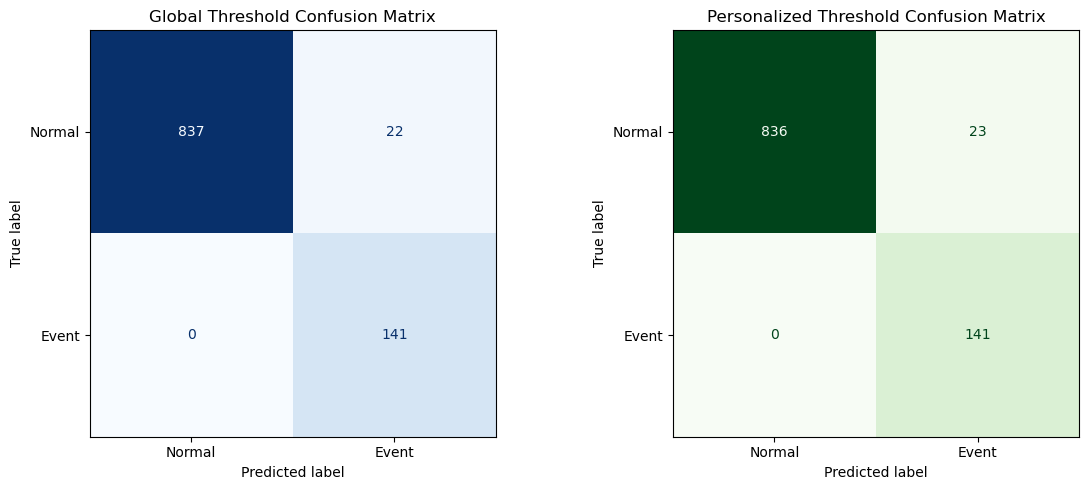

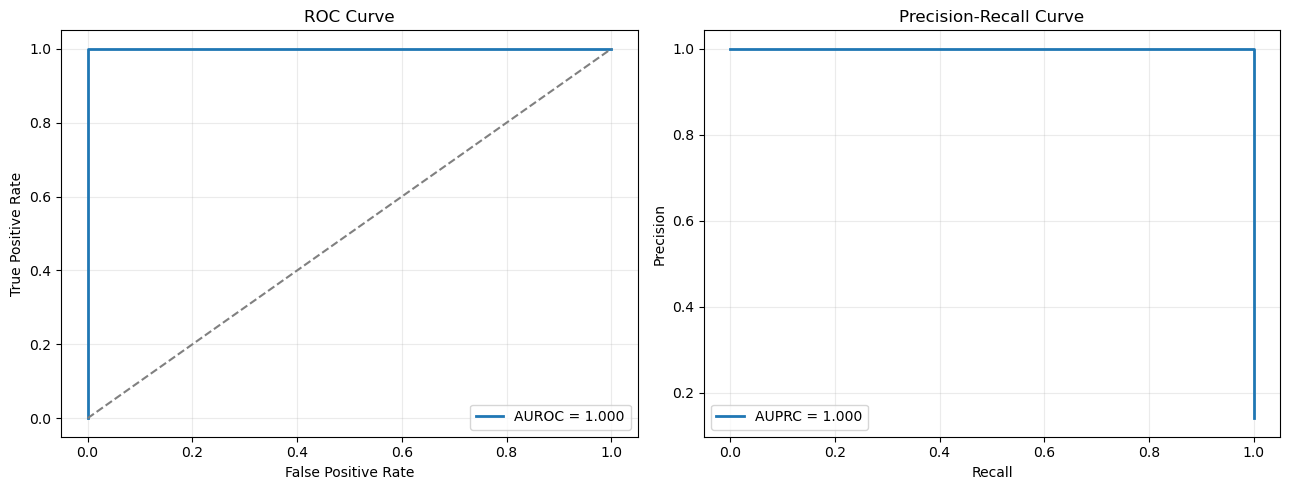

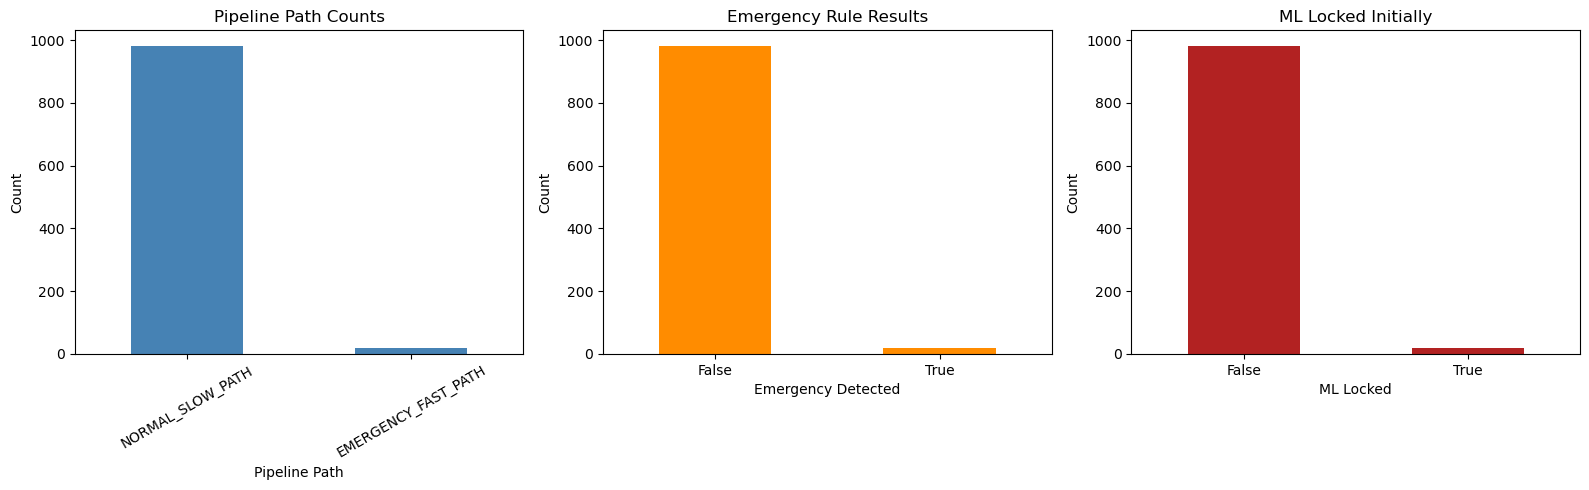

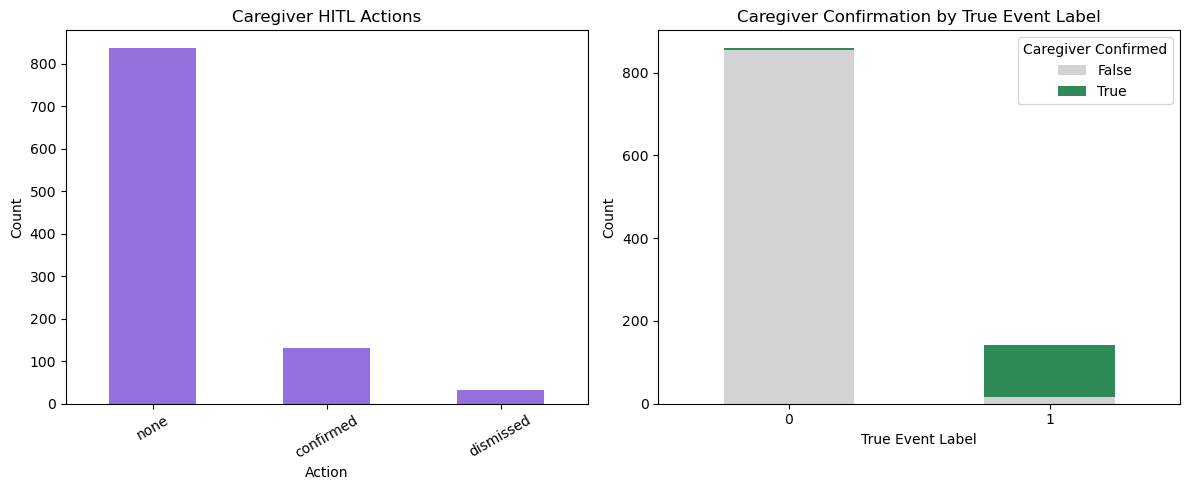

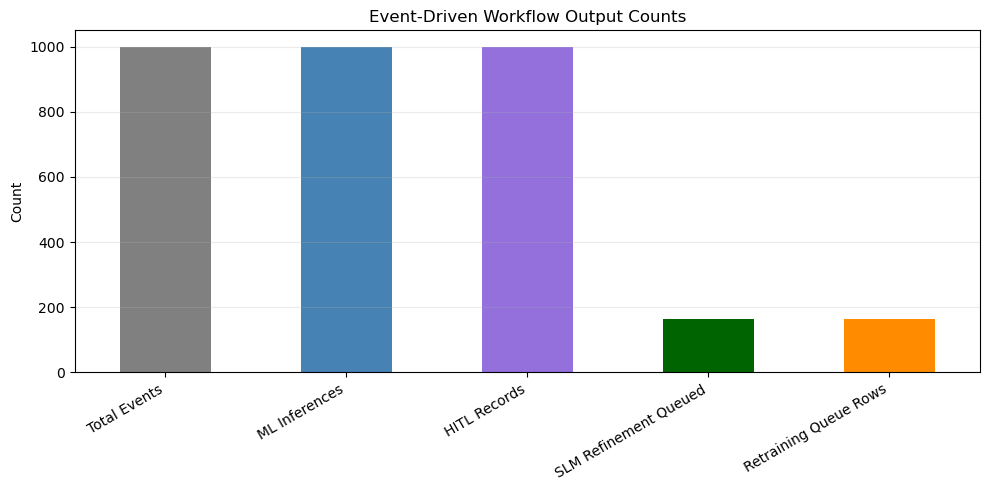


=== Workflow Output Counts ===


,count
Total Events,1000
ML Inferences,1000
HITL Records,1000
SLM Refinement Queued,163
Retraining Queue Rows,163


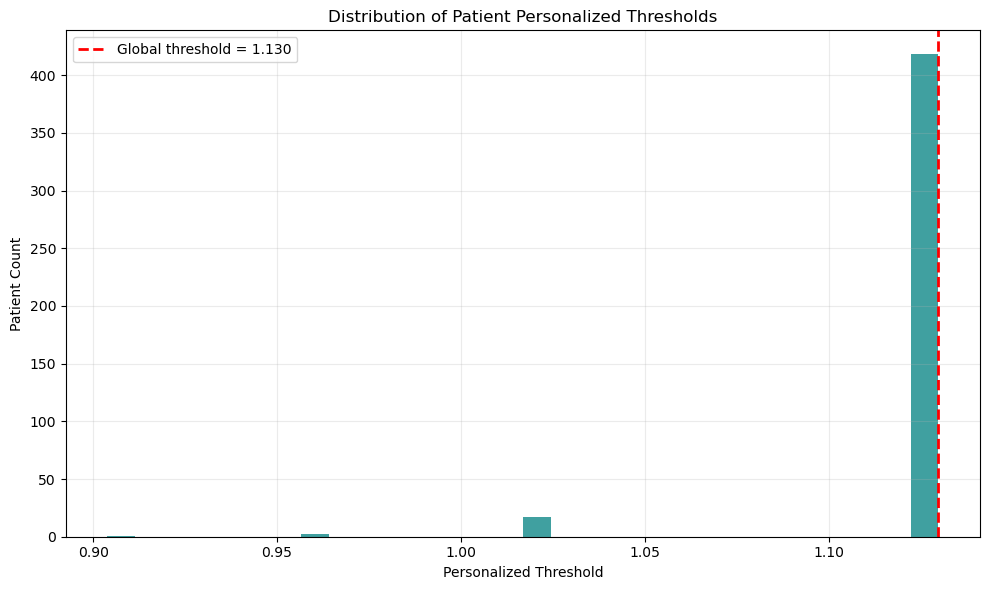


=== Top Updated Patient Profiles ===


,patient_id,personalized_threshold,confirmed_events,dismissed_alerts,true_positive_like_events,false_positive_like_events
94,PATIENT_0220,0.903878,4,0,4,0
65,PATIENT_0414,0.960371,3,0,3,0
169,PATIENT_0263,0.960371,3,0,3,0
16,PATIENT_0109,1.016863,2,0,2,0
59,PATIENT_0057,1.016863,2,0,2,0
62,PATIENT_0105,1.016863,2,0,2,0
75,PATIENT_0218,1.016863,2,0,2,0
84,PATIENT_0054,1.016863,2,0,2,0
99,PATIENT_0342,1.016863,2,0,2,0
100,PATIENT_0351,1.016863,2,0,2,0


C:\Users\jaymo\AppData\Local\Temp\ipykernel_67308\3668198313.py:379: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_to_plot, labels=[str(h) for h in health_events_sorted], showfliers=True)


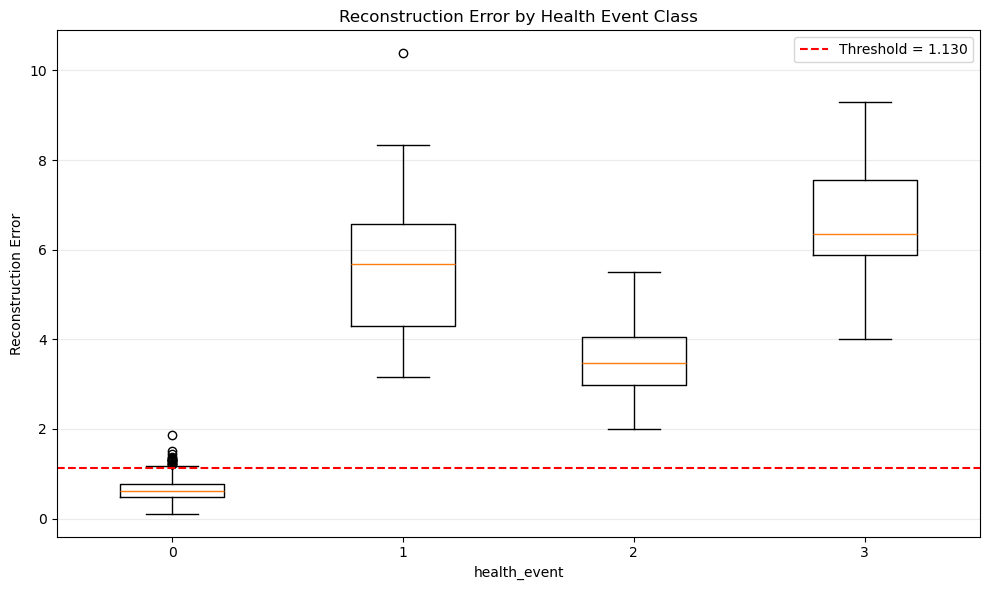


=== Health Event Summary ===


,health_event,count,mean_error,median_error,anomaly_rate_global,anomaly_rate_personalized,caregiver_confirm_rate,slm_queue_rate
0,0,859,0.638573,0.610659,0.025611,0.026775,0.004657,0.025611
1,1,51,5.622076,5.673047,1.000000,1.000000,0.843137,1.000000
2,2,51,3.564775,3.476982,1.000000,1.000000,0.960784,1.000000
3,3,39,6.590365,6.359695,1.000000,1.000000,0.871795,1.000000



=== Top Feature Contributors ===


,feature,mean_top_error,count_in_top5
6,stress_level,10.899598,506
8,heart_rate,5.030702,429
15,blood_pressure_diastolic,4.187869,2
1,sleep_quality,4.187179,524
10,respiratory_rate,3.651943,399
0,blood_oxygen,3.464823,400
3,glucose_level,3.313760,377
2,hrv_sdnn,3.066411,325
5,body_temperature,2.394247,354
12,steps_count,2.053696,429


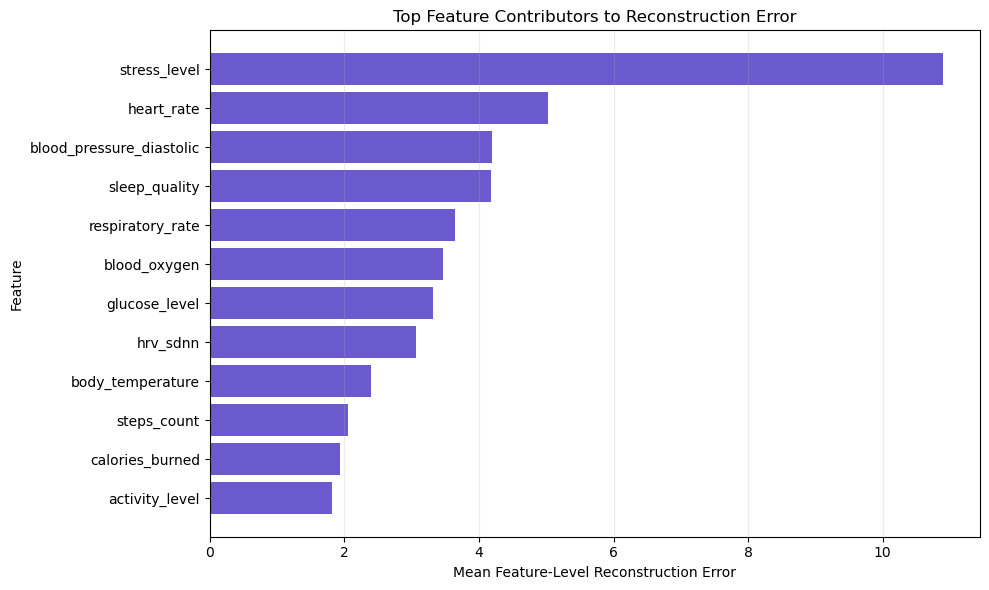

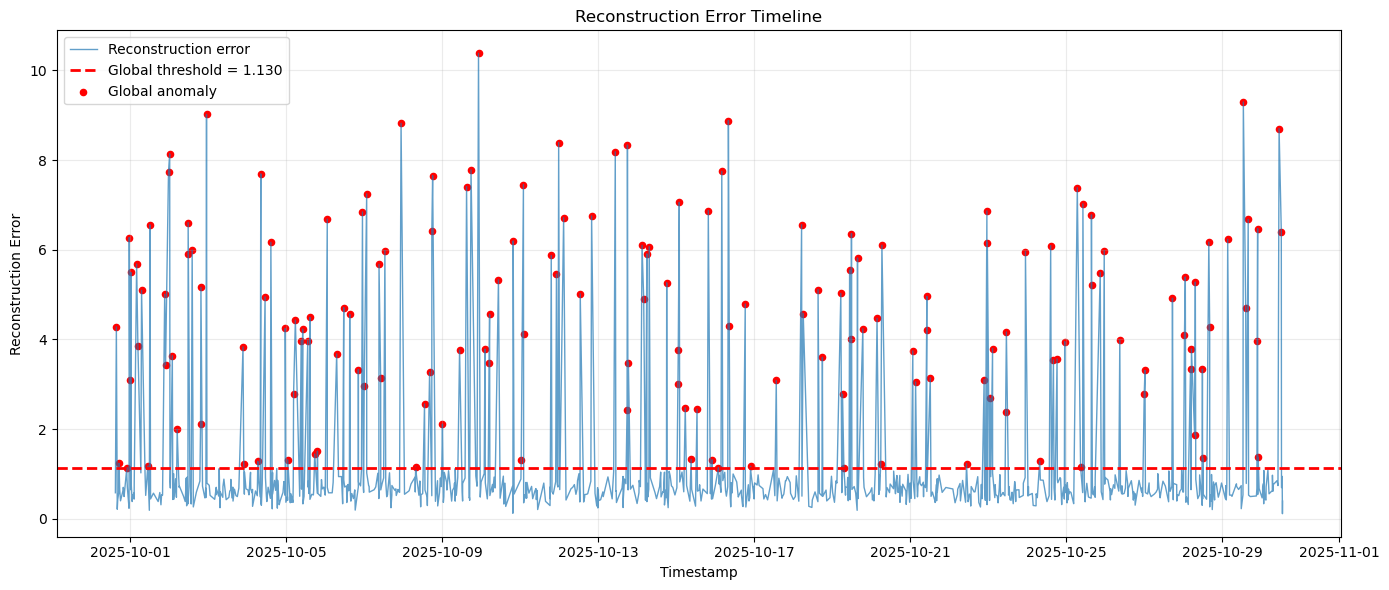


Final continuous personalization visualizations complete.
Saved to: continuous_personalization_sim\visualizations
Summary saved to: continuous_personalization_sim\final_visualization_summary.json
{
  "num_total_events": 1000,
  "num_ml_events": 1000,
  "num_emergency_events": 18,
  "num_ml_locked_initially": 18,
  "num_slm_refinement_queued": 163,
  "global_threshold": 1.1298478841781616,
  "model_version": "tiny_ae_uc2_v0.1.0",
  "metrics": [
    {
      "mode": "global_threshold",
      "n": 1000,
      "precision": 0.8650306748466258,
      "recall": 1.0,
      "f1": 0.9276315789473685,
      "tn": 837,
      "fp": 22,
      "fn": 0,
      "tp": 141,
      "false_positive_rate": 0.025611175785797437,
      "false_negative_rate": 0.0,
      "auroc": 1.0,
      "auprc": 1.0
    },
    {
      "mode": "personalized_threshold_sim",
      "n": 1000,
      "precision": 0.8597560975609756,
      "recall": 1.0,
      "f1": 0.9245901639344263,
      "tn": 836,
      "fp": 23,
      "fn": 0,

In [18]:
# FINAL CELL — Continuous Personalization Graphs & Metrics

import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    roc_curve,
    precision_recall_curve
)

# Setup

VIZ_DIR = os.path.join(OUTPUT_DIR, "visualizations")
os.makedirs(VIZ_DIR, exist_ok=True)

print("Saving visualizations to:", VIZ_DIR)

# Ensure timestamp format where possible
if "timestamp" in events_df.columns:
    events_df["timestamp"] = pd.to_datetime(events_df["timestamp"], errors="coerce")

# Keep only rows where ML actually ran
ml_events = events_df[events_df["ml_ran"] == True].copy()

if len(ml_events) == 0:
    raise ValueError("No ML events found. Check that events_df['ml_ran'] contains True rows.")

# Required columns check
required_cols = [
    "event_label",
    "reconstruction_error",
    "anomaly_detected_global",
    "anomaly_detected_personalized",
    "pipeline_path",
    "emergency",
    "caregiver_action",
    "caregiver_confirmed",
    "slm_refinement_queued"
]

missing_cols = [c for c in required_cols if c not in events_df.columns]
if missing_cols:
    print("Warning: missing columns:", missing_cols)

# Metric helpers

def safe_confusion_counts(y_true, y_pred):
    labels = [0, 1]
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    tn, fp, fn, tp = cm.ravel()
    return cm, tn, fp, fn, tp

def compute_metrics(y_true, y_pred, scores=None, name="model"):
    cm, tn, fp, fn, tp = safe_confusion_counts(y_true, y_pred)

    out = {
        "mode": name,
        "n": int(len(y_true)),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp),
        "false_positive_rate": float(fp / (fp + tn)) if (fp + tn) > 0 else np.nan,
        "false_negative_rate": float(fn / (fn + tp)) if (fn + tp) > 0 else np.nan,
    }

    if scores is not None and len(np.unique(y_true)) > 1:
        out["auroc"] = roc_auc_score(y_true, scores)
        out["auprc"] = average_precision_score(y_true, scores)
    else:
        out["auroc"] = np.nan
        out["auprc"] = np.nan

    return out

# Compute metrics

y_true = ml_events["event_label"].astype(int).values
scores = ml_events["reconstruction_error"].astype(float).values

y_pred_global = ml_events["anomaly_detected_global"].astype(int).values
y_pred_personalized = ml_events["anomaly_detected_personalized"].astype(int).values

summary_metrics = pd.DataFrame([
    compute_metrics(y_true, y_pred_global, scores=scores, name="global_threshold"),
    compute_metrics(y_true, y_pred_personalized, scores=scores, name="personalized_threshold_sim")
])

print("\n=== Global vs Personalized Threshold Metrics ===")
display(summary_metrics)

summary_metrics.to_csv(
    os.path.join(OUTPUT_DIR, "final_visualization_metrics_summary.csv"),
    index=False
)

# 1. Confusion matrices

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_global, *_ = safe_confusion_counts(y_true, y_pred_global)
cm_personalized, *_ = safe_confusion_counts(y_true, y_pred_personalized)

ConfusionMatrixDisplay(
    confusion_matrix=cm_global,
    display_labels=["Normal", "Event"]
).plot(ax=axes[0], cmap="Blues", colorbar=False)

axes[0].set_title("Global Threshold Confusion Matrix")

ConfusionMatrixDisplay(
    confusion_matrix=cm_personalized,
    display_labels=["Normal", "Event"]
).plot(ax=axes[1], cmap="Greens", colorbar=False)

axes[1].set_title("Personalized Threshold Confusion Matrix")

plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, "confusion_matrices_global_vs_personalized.png"), dpi=200)
plt.show()

# 2. Reconstruction error distribution

plt.figure(figsize=(10, 6))

normal_errors = ml_events.loc[ml_events["event_label"] == 0, "reconstruction_error"]
event_errors = ml_events.loc[ml_events["event_label"] == 1, "reconstruction_error"]

plt.hist(normal_errors, bins=40, alpha=0.65, label="Normal label", density=True)
plt.hist(event_errors, bins=40, alpha=0.65, label="Event label", density=True)

plt.axvline(THRESHOLD, linestyle="--", linewidth=2, label=f"Global threshold = {THRESHOLD:.3f}")

if "personalized_threshold" in ml_events.columns:
    median_personal_threshold = ml_events["personalized_threshold"].median()
    plt.axvline(
        median_personal_threshold,
        linestyle=":",
        linewidth=2,
        label=f"Median personalized threshold = {median_personal_threshold:.3f}"
    )

plt.title("Reconstruction Error Distribution")
plt.xlabel("Reconstruction Error")
plt.ylabel("Density")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, "reconstruction_error_distribution.png"), dpi=200)
plt.show()

# 3. ROC curve and Precision-Recall curve

if len(np.unique(y_true)) > 1:
    fpr, tpr, _ = roc_curve(y_true, scores)
    precision_curve, recall_curve, _ = precision_recall_curve(y_true, scores)

    auroc = roc_auc_score(y_true, scores)
    auprc = average_precision_score(y_true, scores)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    axes[0].plot(fpr, tpr, linewidth=2, label=f"AUROC = {auroc:.3f}")
    axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray")
    axes[0].set_title("ROC Curve")
    axes[0].set_xlabel("False Positive Rate")
    axes[0].set_ylabel("True Positive Rate")
    axes[0].legend()
    axes[0].grid(alpha=0.25)

    axes[1].plot(recall_curve, precision_curve, linewidth=2, label=f"AUPRC = {auprc:.3f}")
    axes[1].set_title("Precision-Recall Curve")
    axes[1].set_xlabel("Recall")
    axes[1].set_ylabel("Precision")
    axes[1].legend()
    axes[1].grid(alpha=0.25)

    plt.tight_layout()
    plt.savefig(os.path.join(VIZ_DIR, "roc_and_pr_curves.png"), dpi=200)
    plt.show()
else:
    print("Skipping ROC/PR curves because only one class is present in y_true.")

# 4. Pipeline path and emergency counts

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

events_df["pipeline_path"].value_counts().plot(
    kind="bar",
    ax=axes[0],
    color="steelblue"
)
axes[0].set_title("Pipeline Path Counts")
axes[0].set_xlabel("Pipeline Path")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=30)

events_df["emergency"].value_counts().sort_index().plot(
    kind="bar",
    ax=axes[1],
    color="darkorange"
)
axes[1].set_title("Emergency Rule Results")
axes[1].set_xlabel("Emergency Detected")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=0)

events_df["ml_locked_initially"].value_counts().sort_index().plot(
    kind="bar",
    ax=axes[2],
    color="firebrick"
)
axes[2].set_title("ML Locked Initially")
axes[2].set_xlabel("ML Locked")
axes[2].set_ylabel("Count")
axes[2].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, "pipeline_emergency_ml_lock_counts.png"), dpi=200)
plt.show()

# 5. HITL caregiver action summary

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

events_df["caregiver_action"].value_counts().plot(
    kind="bar",
    ax=axes[0],
    color="mediumpurple"
)
axes[0].set_title("Caregiver HITL Actions")
axes[0].set_xlabel("Action")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=30)

pd.crosstab(
    events_df["event_label"],
    events_df["caregiver_confirmed"]
).plot(
    kind="bar",
    stacked=True,
    ax=axes[1],
    color=["lightgray", "seagreen"]
)
axes[1].set_title("Caregiver Confirmation by True Event Label")
axes[1].set_xlabel("True Event Label")
axes[1].set_ylabel("Count")
axes[1].legend(title="Caregiver Confirmed")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, "hitl_caregiver_actions.png"), dpi=200)
plt.show()

# 6. SLM refinement and retraining queue counts

queue_counts = pd.Series({
    "Total Events": len(events_df),
    "ML Inferences": len(ml_log_df) if "ml_log_df" in globals() else int(events_df["ml_ran"].sum()),
    "HITL Records": len(hitl_df) if "hitl_df" in globals() else len(events_df),
    "SLM Refinement Queued": int(events_df["slm_refinement_queued"].sum()),
    "Retraining Queue Rows": len(retraining_df) if "retraining_df" in globals() else int(events_df["slm_refinement_queued"].sum())
})

plt.figure(figsize=(10, 5))
queue_counts.plot(kind="bar", color=["gray", "steelblue", "mediumpurple", "darkgreen", "darkorange"])
plt.title("Event-Driven Workflow Output Counts")
plt.ylabel("Count")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.savefig(os.path.join(VIZ_DIR, "workflow_output_counts.png"), dpi=200)
plt.show()

print("\n=== Workflow Output Counts ===")
display(queue_counts.to_frame("count"))

# 7. Patient personalization threshold distribution

if "profiles_df" in globals() and len(profiles_df) > 0:
    plt.figure(figsize=(10, 6))

    plt.hist(
        profiles_df["personalized_threshold"].dropna(),
        bins=30,
        alpha=0.75,
        color="teal"
    )

    plt.axvline(
        THRESHOLD,
        linestyle="--",
        linewidth=2,
        color="red",
        label=f"Global threshold = {THRESHOLD:.3f}"
    )

    plt.title("Distribution of Patient Personalized Thresholds")
    plt.xlabel("Personalized Threshold")
    plt.ylabel("Patient Count")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.savefig(os.path.join(VIZ_DIR, "personalized_threshold_distribution.png"), dpi=200)
    plt.show()

    top_profiles = profiles_df.sort_values(
        by=["confirmed_events", "dismissed_alerts"],
        ascending=False
    ).head(15)

    display_cols = [
        "patient_id",
        "personalized_threshold",
        "confirmed_events",
        "dismissed_alerts",
        "true_positive_like_events",
        "false_positive_like_events"
    ]

    display_cols = [c for c in display_cols if c in top_profiles.columns]

    print("\n=== Top Updated Patient Profiles ===")
    display(top_profiles[display_cols])
else:
    print("Skipping patient profile visualization because profiles_df is missing or empty.")

# 8. Reconstruction error by health_event

if "health_event" in ml_events.columns:
    plt.figure(figsize=(10, 6))

    health_events_sorted = sorted(ml_events["health_event"].dropna().unique())

    data_to_plot = [
        ml_events.loc[ml_events["health_event"] == h, "reconstruction_error"].values
        for h in health_events_sorted
    ]

    plt.boxplot(data_to_plot, labels=[str(h) for h in health_events_sorted], showfliers=True)
    plt.axhline(THRESHOLD, linestyle="--", color="red", label=f"Threshold = {THRESHOLD:.3f}")

    plt.title("Reconstruction Error by Health Event Class")
    plt.xlabel("health_event")
    plt.ylabel("Reconstruction Error")
    plt.legend()
    plt.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.savefig(os.path.join(VIZ_DIR, "reconstruction_error_by_health_event.png"), dpi=200)
    plt.show()

    health_event_summary = ml_events.groupby("health_event").agg(
        count=("reconstruction_error", "size"),
        mean_error=("reconstruction_error", "mean"),
        median_error=("reconstruction_error", "median"),
        anomaly_rate_global=("anomaly_detected_global", "mean"),
        anomaly_rate_personalized=("anomaly_detected_personalized", "mean"),
        caregiver_confirm_rate=("caregiver_confirmed", "mean"),
        slm_queue_rate=("slm_refinement_queued", "mean")
    ).reset_index()

    print("\n=== Health Event Summary ===")
    display(health_event_summary)

    health_event_summary.to_csv(
        os.path.join(OUTPUT_DIR, "final_health_event_summary.csv"),
        index=False
    )

# 9. Top reconstructed-error feature contributors

if "top_features" in ml_events.columns:
    feature_contrib = {}

    for item in ml_events["top_features"].dropna():
        try:
            parsed = json.loads(item) if isinstance(item, str) else item

            for feature, value in parsed:
                feature_contrib.setdefault(feature, []).append(float(value))

        except Exception:
            pass

    if len(feature_contrib) > 0:
        feature_contrib_df = pd.DataFrame([
            {
                "feature": feature,
                "mean_top_error": np.mean(values),
                "count_in_top5": len(values)
            }
            for feature, values in feature_contrib.items()
        ]).sort_values("mean_top_error", ascending=False)

        print("\n=== Top Feature Contributors ===")
        display(feature_contrib_df.head(15))

        feature_contrib_df.to_csv(
            os.path.join(OUTPUT_DIR, "final_top_feature_contributors.csv"),
            index=False
        )

        plt.figure(figsize=(10, 6))
        plot_df = feature_contrib_df.head(12).sort_values("mean_top_error", ascending=True)

        plt.barh(plot_df["feature"], plot_df["mean_top_error"], color="slateblue")
        plt.title("Top Feature Contributors to Reconstruction Error")
        plt.xlabel("Mean Feature-Level Reconstruction Error")
        plt.ylabel("Feature")
        plt.grid(axis="x", alpha=0.25)
        plt.tight_layout()
        plt.savefig(os.path.join(VIZ_DIR, "top_feature_contributors.png"), dpi=200)
        plt.show()
    else:
        print("No parsable top feature data found.")

# 10. Timeline plot if timestamps are available

if "timestamp" in ml_events.columns and ml_events["timestamp"].notna().sum() > 0:
    timeline_df = ml_events.sort_values("timestamp").copy()

    plt.figure(figsize=(14, 6))

    plt.plot(
        timeline_df["timestamp"],
        timeline_df["reconstruction_error"],
        linewidth=1,
        alpha=0.7,
        label="Reconstruction error"
    )

    plt.axhline(
        THRESHOLD,
        linestyle="--",
        color="red",
        linewidth=2,
        label=f"Global threshold = {THRESHOLD:.3f}"
    )

    anomaly_points = timeline_df[timeline_df["anomaly_detected_global"] == True]

    plt.scatter(
        anomaly_points["timestamp"],
        anomaly_points["reconstruction_error"],
        color="red",
        s=20,
        label="Global anomaly"
    )

    plt.title("Reconstruction Error Timeline")
    plt.xlabel("Timestamp")
    plt.ylabel("Reconstruction Error")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.savefig(os.path.join(VIZ_DIR, "reconstruction_error_timeline.png"), dpi=200)
    plt.show()
else:
    print("Skipping timeline plot because timestamps are unavailable.")

# 11. Save final summary JSON

final_summary = {
    "num_total_events": int(len(events_df)),
    "num_ml_events": int(len(ml_events)),
    "num_emergency_events": int(events_df["emergency"].sum()) if "emergency" in events_df.columns else None,
    "num_ml_locked_initially": int(events_df["ml_locked_initially"].sum()) if "ml_locked_initially" in events_df.columns else None,
    "num_slm_refinement_queued": int(events_df["slm_refinement_queued"].sum()) if "slm_refinement_queued" in events_df.columns else None,
    "global_threshold": float(THRESHOLD),
    "model_version": MODEL_VERSION,
    "metrics": summary_metrics.to_dict(orient="records"),
    "visualization_dir": VIZ_DIR
}

with open(os.path.join(OUTPUT_DIR, "final_visualization_summary.json"), "w") as f:
    json.dump(final_summary, f, indent=2)

print("\n============================================================")
print("Final continuous personalization visualizations complete.")
print("Saved to:", VIZ_DIR)
print("Summary saved to:", os.path.join(OUTPUT_DIR, "final_visualization_summary.json"))
print("============================================================")
print(json.dumps(final_summary, indent=2))

## UC2 Presentation Validation — Display Only

,object,exists,detail
0,events_df,True,"DataFrame shape=(1000, 23)"
1,ml_log_df,True,"DataFrame shape=(1000, 7)"
2,hitl_df,True,"DataFrame shape=(1000, 7)"
3,profiles_df,True,"DataFrame shape=(438, 8)"
4,slm_queue,True,list length=163
5,retraining_df,True,"DataFrame shape=(163, 12)"
6,THRESHOLD,True,float: 1.1298478841781616
7,MODEL_VERSION,True,str: tiny_ae_uc2_v0.1.0


## 1. Executive Workflow Validation Table

,validation_item,result,presentation_meaning
0,Total rows/events processed,1000,Dataset rows were routed through the UC2 workflow simulation.
1,Emergency fast-path events,0,Rule Engine detected high-severity cases before ML.
2,ML lockout events,0,"Emergency rows bypassed ML initially, matching safety architecture."
3,ML log rows,1000,Autoencoder inference outputs were logged for auditability.
4,Autoencoder anomaly flags,N/A,Slow-path anomaly detections generated by the tiny AE.
5,Caregiver HITL records,1000,Structured caregiver feedback was captured.
6,Patient personalization profiles,438,Patient-specific profile state was updated.
7,SLM refinement payloads,163,Grounded ML + HITL context was packaged for SLM interpretation.
8,Future retraining/refinement queue rows,163,Feedback-linked examples were queued for future model improvement.
9,Model version,tiny_ae_uc2_v0.1.0,Model artifact version is available for traceability.


## 2. UC2 Workflow Diagram

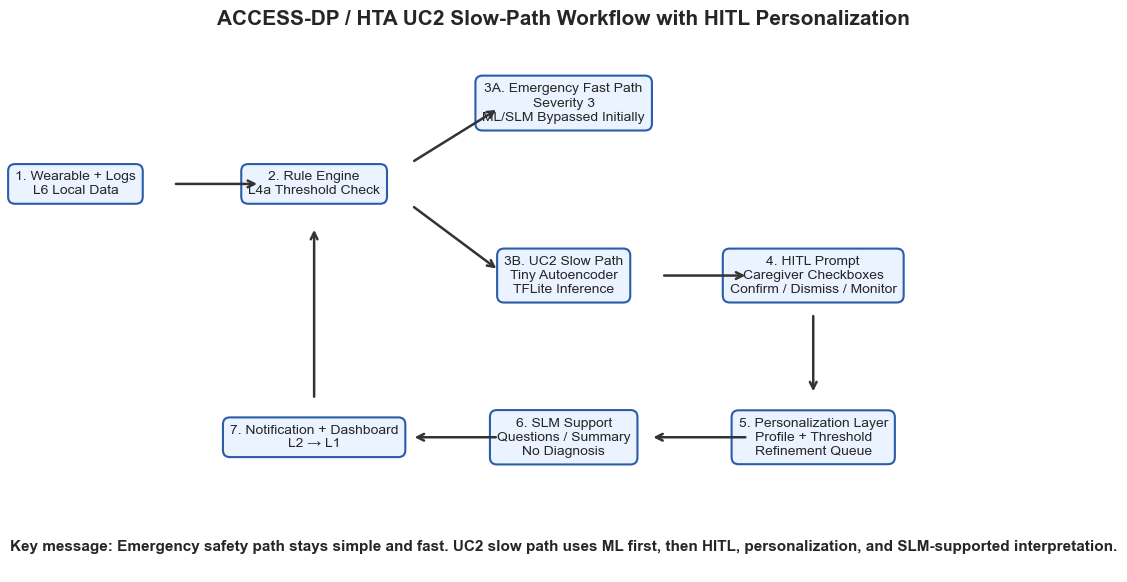

## 3. Workflow Routing Counts

No routing/path column found in events_df.
No emergency or ML lockout columns found.


## 4. Global vs Personalized Metrics

Could not compute metrics because health_event and/or anomaly flag columns were not found.
Detected health_event_col: health_event
Detected ae_flag_col: None


## 5. Reconstruction Error Distribution

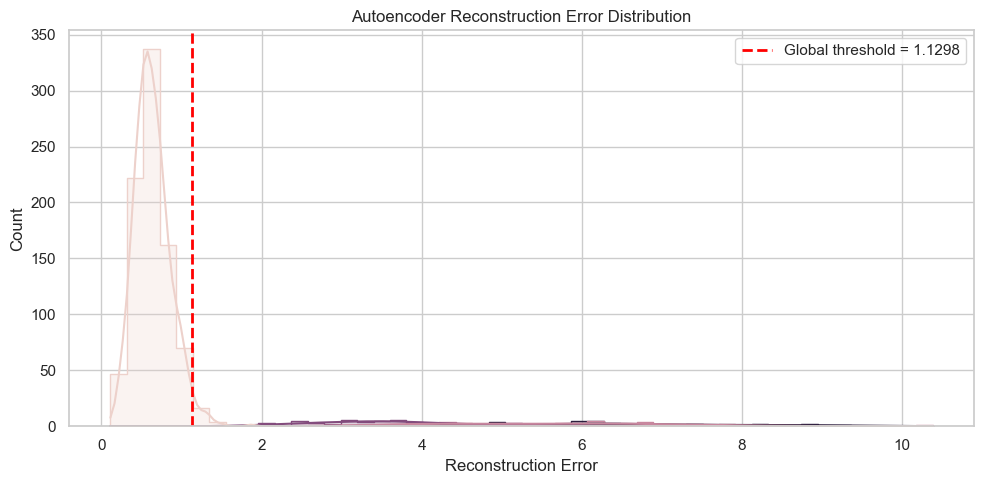

,reconstruction_error_summary
count,1000.000000
mean,1.274088
std,1.717371
min,0.111353
25%,0.506846
50%,0.659417
75%,0.904405
max,10.381976


## 6. Caregiver HITL Action Summary

,patient_id,timestamp,caregiver_action,caregiver_confirmed,caregiver_observations,health_event,event_label
0,PATIENT_0289,2025-10-06 10:44:45.056387,none,False,[],0,0
1,PATIENT_0075,2025-10-21 07:59:45.056387,none,False,[],0,0
2,PATIENT_0246,2025-10-05 15:44:45.056387,none,False,[],0,0
3,PATIENT_0196,2025-10-20 21:14:45.056387,none,False,[],0,0
4,PATIENT_0069,2025-10-01 00:20:45.056387,none,False,[],0,0
5,PATIENT_0237,2025-10-15 15:13:45.056387,none,False,[],0,0
6,PATIENT_0249,2025-10-11 04:10:45.056387,none,False,[],0,0
7,PATIENT_0280,2025-10-28 11:43:45.056387,confirmed,True,"[reduced activity, poor sleep]",2,1
8,PATIENT_0129,2025-10-18 17:54:45.056387,confirmed,True,"[reduced activity, poor sleep]",2,1
9,PATIENT_0115,2025-10-13 01:28:45.056387,none,False,[],0,0


,caregiver_action,count,percent
0,none,837,83.7
1,confirmed,130,13.0
2,dismissed,33,3.3


C:\Users\jaymo\AppData\Local\Temp\ipykernel_67308\1689467879.py:470: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=action_counts, x="caregiver_action", y="count", palette="Purples")


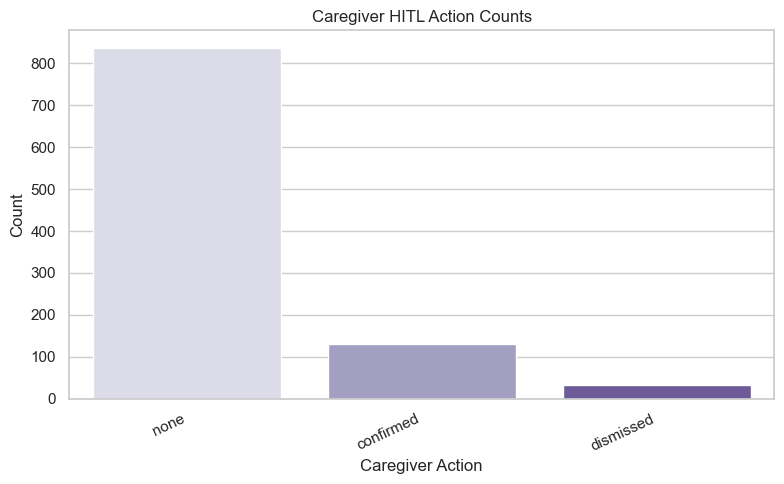

## 7. Patient Personalization Profiles

,patient_id,base_threshold,personalized_threshold,confirmed_events,dismissed_alerts,false_positive_like_events,true_positive_like_events,last_updated
94,PATIENT_0220,1.129848,0.903878,4,0,0,4,2026-06-18T12:52:50.651136
65,PATIENT_0414,1.129848,0.960371,3,0,0,3,2026-06-18T12:52:50.778334
169,PATIENT_0263,1.129848,0.960371,3,0,0,3,2026-06-18T12:52:50.775261
16,PATIENT_0109,1.129848,1.016863,2,0,0,2,2026-06-18T12:52:50.781337
59,PATIENT_0057,1.129848,1.016863,2,0,0,2,2026-06-18T12:52:50.695073
62,PATIENT_0105,1.129848,1.016863,2,0,0,2,2026-06-18T12:52:50.850232
75,PATIENT_0218,1.129848,1.016863,2,0,0,2,2026-06-18T12:52:50.827547
84,PATIENT_0054,1.129848,1.016863,2,0,0,2,2026-06-18T12:52:50.746697
99,PATIENT_0342,1.129848,1.016863,2,0,0,2,2026-06-18T12:52:50.750699
100,PATIENT_0351,1.129848,1.016863,2,0,0,2,2026-06-18T12:52:50.586045


,profile_metric,value
0,Number of patient profiles,438.000000
1,Mean personalized threshold,1.124173
2,Min personalized threshold,0.903878
3,Max personalized threshold,1.129848
4,Total confirmed events,130.000000


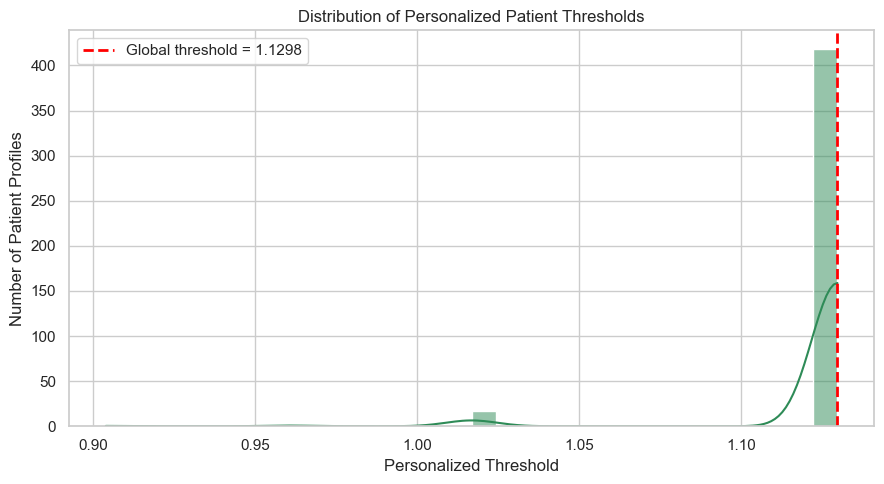

,patient_id,personalized_threshold,threshold_delta_from_global,confirmed_events
94,PATIENT_0220,0.903878,-0.225970,4
169,PATIENT_0263,0.960371,-0.169477,3
65,PATIENT_0414,0.960371,-0.169477,3
163,PATIENT_0093,1.016863,-0.112985,2
314,PATIENT_0256,1.016863,-0.112985,2
239,PATIENT_0216,1.016863,-0.112985,2
227,PATIENT_0006,1.016863,-0.112985,2
197,PATIENT_0487,1.016863,-0.112985,2
195,PATIENT_0363,1.016863,-0.112985,2
176,PATIENT_0344,1.016863,-0.112985,2


## 8. Logs and Queues Validation

,artifact,count,role
0,events_df,1000,Main workflow event table
1,ml_log_df,1000,AE inference and audit log
2,hitl_df,1000,Structured caregiver feedback records
3,profiles_df,438,Patient personalization profile state
4,slm_queue,163,Grounded SLM interpretation/refinement payloads
5,retraining_df,163,Future retraining/refinement candidate examples


### ML Log Sample

,patient_id,timestamp,model_version,reconstruction_error,threshold,anomaly_detected,input_hash
0,PATIENT_0289,2025-10-06 10:44:45.056387,tiny_ae_uc2_v0.1.0,0.333599,1.129848,False,754b62d3dbfe2e491ed1366752c1aa25ee88d2f9b12c45d008c8f2e52a4d7947
1,PATIENT_0075,2025-10-21 07:59:45.056387,tiny_ae_uc2_v0.1.0,0.814120,1.129848,False,43144340c53b06723da304dfb334a3e31284775a9f97fae0dc7f4c60a0eda67b
2,PATIENT_0246,2025-10-05 15:44:45.056387,tiny_ae_uc2_v0.1.0,0.543931,1.129848,False,f1387edcaf917170228b4453117e9726671cbcab6c7142ba949a59c17059dbb0
3,PATIENT_0196,2025-10-20 21:14:45.056387,tiny_ae_uc2_v0.1.0,0.621658,1.129848,False,74b6b98aca0c5a4ecb2bb2ac91b66e02efa62ec8740c98b954908b5a29a498ca
4,PATIENT_0069,2025-10-01 00:20:45.056387,tiny_ae_uc2_v0.1.0,0.646603,1.129848,False,100a159fa12e2e243577805dc9ed66f46bac36d6d1e235cd63cffc7594716033
5,PATIENT_0237,2025-10-15 15:13:45.056387,tiny_ae_uc2_v0.1.0,0.395043,1.129848,False,0e7820078bc226742a254aa259e33e900a13a1b7b2e1c306b50b6bdb9e2709ab
6,PATIENT_0249,2025-10-11 04:10:45.056387,tiny_ae_uc2_v0.1.0,0.809297,1.129848,False,ec9626893a9236fafa257f1dd00b1278c807db4ac7384492808ff534e588feff
7,PATIENT_0280,2025-10-28 11:43:45.056387,tiny_ae_uc2_v0.1.0,3.334940,1.129848,True,0c55ece1d7c5263db48a6964e155656b1334c5f3620279b3afa82743a778a6f2
8,PATIENT_0129,2025-10-18 17:54:45.056387,tiny_ae_uc2_v0.1.0,3.600692,1.129848,True,9b8a11e8a61a257ac66e7384f9d48413f9d0b8f00f87635e439d25165311d9f3
9,PATIENT_0115,2025-10-13 01:28:45.056387,tiny_ae_uc2_v0.1.0,0.422918,1.129848,False,75b596c2c961a5b62e9dfc381ac8599c372465d717805b304a93e7ab774fee9f


### Retraining / Refinement Queue Sample

,patient_id,timestamp,health_event,event_label,caregiver_confirmed,caregiver_action,caregiver_observations,reconstruction_error,anomaly_detected,feature_vector_raw,feature_vector_scaled,input_hash
0,PATIENT_0280,2025-10-28 11:43:45.056387,2,1,True,confirmed,"[reduced activity, poor sleep]",3.334940,True,"[88.69999694824219, 94.0999984741211, 126.0, 71.0, 49.099998474121094, 98.12000274658203, 17.200000762939453, 0.2639999985694885, 0.5979999899864197, 0.7080...","[1.388352632522583, -1.9602901935577393, 0.7508610486984253, -1.4965627193450928, -3.3646085262298584, -0.9569522738456726, 0.6049491763114929, -1.978605151...",0c55ece1d7c5263db48a6964e155656b1334c5f3620279b3afa82743a778a6f2
1,PATIENT_0129,2025-10-18 17:54:45.056387,2,1,True,confirmed,"[reduced activity, poor sleep]",3.600692,True,"[98.19999694824219, 97.0999984741211, 99.0, 59.0, 53.5, 98.0199966430664, 15.800000190734863, 0.23899999260902405, 0.5659999847412109, 0.6570000052452087, 1...","[2.3594207763671875, 0.08299451321363449, -2.6009647846221924, -3.488630771636963, -3.073406934738159, -1.1572707891464233, -0.11179026961326599, -2.1524801...",9b8a11e8a61a257ac66e7384f9d48413f9d0b8f00f87635e439d25165311d9f3
2,PATIENT_0185,2025-10-06 11:23:45.056387,1,1,False,dismissed,[],4.708022,True,"[49.29999923706055, 93.9000015258789, 146.0, 94.0, 108.5999984741211, 99.33999633789062, 18.899999618530273, 0.3779999911785126, 0.5450000166893005, 0.88200...","[-2.6390249729156494, -2.0965070724487305, 3.2336950302124023, 2.3215672969818115, 0.5732299089431763, 1.486772060394287, 1.4752745628356934, -1.18573570251...",88ef0119d1389b17064c2f39e89e2d757187cc7384dfc6b3567b4ae6be72334e
3,PATIENT_0212,2025-10-22 21:24:45.056387,2,1,True,confirmed,"[reduced activity, poor sleep]",3.103618,True,"[80.69999694824219, 96.19999694824219, 102.0, 75.0, 52.29999923706055, 97.73999786376953, 18.799999237060547, 0.22599999606609344, 0.42800000309944153, 0.52...","[0.5706109404563904, -0.5299919247627258, -2.2285397052764893, -0.8325401544570923, -3.1528255939483643, -1.7181260585784912, 1.4240787029266357, -2.2428948...",fafc082d0426d921bfac0ec73034e1b41545c5c0ff2cd8fdbe885cc9647b766a
4,PATIENT_0382,2025-10-02 04:55:45.056387,2,1,True,confirmed,"[reduced activity, poor sleep]",1.994072,True,"[91.5, 96.80000305175781, 127.0, 64.0, 44.70000076293945, 98.30999755859375, 16.0, 0.1860000044107437, 0.5709999799728394, 0.5019999742507935, 55.5, 3289.0,...","[1.6745624542236328, -0.12133082747459412, 0.8750027418136597, -2.658602476119995, -3.6558098793029785, -0.5763806104660034, -0.009399066679179668, -2.52109...",4dce23cbdcaf31402bbf6c0fe11c701265d019dba4ef37d8a898021bdec48bd8
5,PATIENT_0266,2025-10-12 19:54:45.056387,3,1,False,dismissed,[],6.753829,True,"[125.0, 94.69999694824219, 168.0, 98.0, 143.39999389648438, 99.43000030517578, 17.700000762939453, 0.3059999942779541, 0.25099998712539673, 0.76200002431869...","[5.098855495452881, -1.5516341924667358, 5.964812278747559, 2.9855899810791016, 2.876368761062622, 1.6670557260513306, 0.860927402973175, -1.686495304107666...",95ea407e7a3f20989dea34125bf21e821c3e09be8a2c362f5d38e58f1a6c7d30
6,PATIENT_0051,2025-10-28 06:56:45.056387,0,0,False,dismissed,[],1.868801,True,"[87.80000305175781, 93.4000015258789, 101.0, 77.0, 116.5, 97.81999969482422, 10.0, 0.4390000104904175, 0.9359999895095825, 0.14300000667572021, 58.599998474...","[1.2963573932647705, -2.437054395675659, -2.3526813983917236, -0.500528872013092, 1.096069097518921, -1.5578773021697998, -3.0811381340026855, -0.7614808082...",cd993457e329882132d722bb1af776da41ab7b82713c86f5094f1cca63b129ef
7,PATIENT_0105,2025-10-07 01:31:45.056387,1,1,True,confirmed,"[reduced activity, poor sleep, breathing concern, elevated heart rate]",7.243576,True,"[127.5999984741211, 92.0999984741211, 138.0, 85.0, 136.39999389648438, 99.70999908447266, 21.399999618530273, 0.5550000071525574, 0.42899999022483826, 0.838...","[5.364621639251709, -3.322479724884033, 2.2405614852905273, 0.827516496181488, 2.4130935668945312, 2

## 9. Dataset Label / health_event Behavior

,health_event,count,percent
0,0,859,85.9
1,1,51,5.1
2,2,51,5.1
3,3,39,3.9


C:\Users\jaymo\AppData\Local\Temp\ipykernel_67308\1689467879.py:644: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=event_counts, x="health_event", y="count", palette="coolwarm")


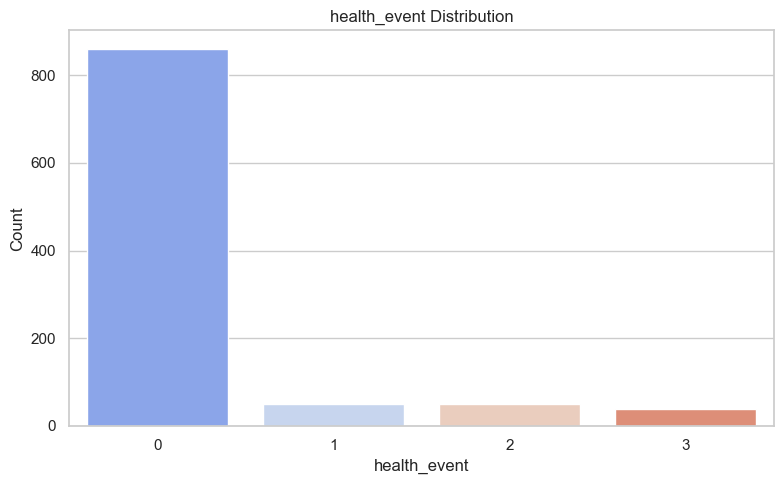

C:\Users\jaymo\AppData\Local\Temp\ipykernel_67308\1689467879.py:653: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=events_df, x=health_event_col, y=score_col_events, palette="coolwarm")


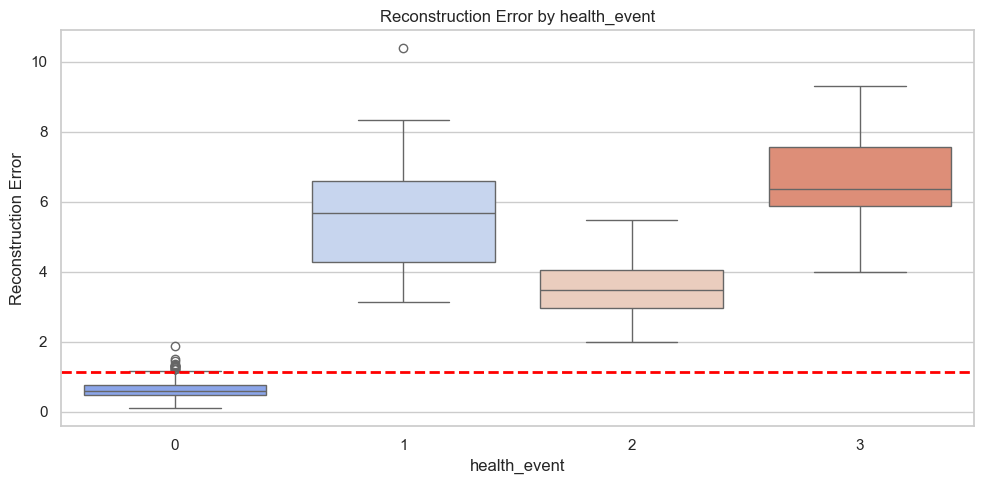

,health_event,count,mean,median,std,min,max
0,0,859,0.638573,0.610659,0.224006,0.111353,1.868801
1,1,51,5.622076,5.673047,1.486696,3.149410,10.381976
2,2,51,3.564775,3.476982,0.894696,1.994072,5.493216
3,3,39,6.590365,6.359695,1.375315,4.009038,9.297909


## 10. Anomaly-Type-Aware HITL Interpretation

,anomaly_type,typical_ml_pattern,caregiver_response,decision_engine_interpretation,personalization_update
0,EXERTION_LIKE,High heart rate + high activity/steps + normal oxygen,Exercising or active,Likely explainable context; continue monitoring unless symptoms are concerning.,Reduce future alert sensitivity for this pattern if repeatedly confirmed as benign.
1,LOW_ACTIVITY_HIGH_HR,High heart rate + low movement/activity,Nothing unusual / tired / weak / not acting normal,Caregiver response supports concern; ask follow-up questions or escalate.,Increase confidence for this pattern for this patient.
2,RESPIRATORY_CONCERN,Low blood oxygen + elevated respiratory rate,Breathing different / confused / weak,Potentially serious; rule engine may escalate if threshold is severe.,Do not suppress solely based on dismissals; safety rule remains dominant.
3,GI_AUTONOMIC_RISK,Elevated HR/stress + low activity + vomiting/bowel/bladder issue,"Vomiting/diarrhea, bathroom changes, missed medication",Relevant to UC2 style slow-path anomaly; SLM can ask structured follow-up.,Store as confirmed contextual risk pattern.
4,POSSIBLE_SENSOR_ARTIFACT,Abrupt impossible jump/drop or inconsistent vitals,Sensor/watch issue,Likely data quality issue; avoid over-escalation and request device check.,Track device reliability separately from patient physiology.
5,SLEEP_STRESS_RECOVERY,Poor sleep + high stress + HRV drop,Poor sleep / stress / pain,May justify monitoring or follow-up questions rather than urgent escalation.,Profile patient-specific baseline for sleep/stress recovery.


## 11. Example Grounded SLM Payload

Example SLM payload from queue:
{
  "queue_type": "SLM_HEURISTIC_REFINEMENT",
  "event_type": "TRIGGER_WORKFLOW_ANOMALY_TYPE_04",
  "patient_id": "PATIENT_0280",
  "device_id": "DEVICE_0154",
  "timestamp": "2025-10-28 11:43:45.056387",
  "model": {
    "model_version": "tiny_ae_uc2_v0.1.0",
    "threshold": 1.1298478841781616,
    "personalized_threshold": 1.1298478841781616,
    "reconstruction_error": 3.334939956665039,
    "anomaly_detected": true,
    "input_hash": "0c55ece1d7c5263db48a6964e155656b1334c5f3620279b3afa82743a778a6f2",
    "top_features": [
      [
        "stress_level",
        23.191972804096622
      ],
      [
        "glucose_level",
        11.458927076984992
      ],
      [
        "calories_burned",
        5.851854704597827
      ],
      [
        "steps_count",
        5.793924774758352
      ],
      [
        "blood_oxygen",
        4.266546416376116
      ]
    ]
  },
  "rule_engine": {
    "is_emergency": false,
    "severity": 1,
    "reasons": []
  


**Presentation wording:**  
The SLM does not decide whether the data is anomalous. The tiny autoencoder and rule engine produce structured evidence first.  
The SLM receives grounded context — model score, threshold, top feature deviations, caregiver responses, and patient profile — then helps generate safe follow-up questions or a clinician-facing summary.


## 12. Final Presentation Summary

{
  "use_case": "UC2 slow-path anomaly detection",
  "event_name": "TRIGGER_WORKFLOW_ANOMALY_TYPE_04",
  "model_version": "tiny_ae_uc2_v0.1.0",
  "global_threshold": 1.1298478841781616,
  "rows_processed": 1000,
  "emergency_fast_path_events": 0,
  "ml_initially_locked_events": 0,
  "ml_log_rows": 1000,
  "hitl_records": 1000,
  "patient_profiles": 438,
  "slm_queue_payloads": 163,
  "retraining_queue_rows": 163,
  "important_caveat": "This validates the workflow around a static tiny autoencoder. Personalization is simulated through profile updates, threshold heuristics, HITL feedback, SLM refinement payloads, and a future retraining queue. It is not live on-device retraining."
}


In [19]:
# PRESENTATION VALIDATION CELL — DISPLAY ONLY, NO FILE SAVING
# Purpose:
#   Validate the UC2 continuous personalization + HITL simulation for presentation.
#
# This cell intentionally does NOT:
#   - create directories
#   - call to_csv()
#   - call json.dump()
#   - call plt.savefig()
#   - write any local files
#
# It only:
#   - prints summaries
#   - displays pandas tables
#   - shows matplotlib/seaborn plots inline

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, Markdown
from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score
)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_colwidth", 160)

def safe_len(obj):
    try:
        return len(obj)
    except Exception:
        return 0

def show_section(title):
    display(Markdown(f"## {title}"))

def show_subsection(title):
    display(Markdown(f"### {title}"))

def get_col(df, possible_cols, default=None):
    """
    Return first matching column name from possible_cols, else default.
    """
    if df is None:
        return default
    for c in possible_cols:
        if c in df.columns:
            return c
    return default

def safe_value_counts(df, col_name, normalize=False):
    if df is None or col_name not in df.columns:
        return pd.Series(dtype=float)
    return df[col_name].value_counts(normalize=normalize, dropna=False)

def pretty_json(obj, max_chars=5000):
    text = json.dumps(obj, indent=2, default=str)
    if len(text) > max_chars:
        text = text[:max_chars] + "\n... [TRUNCATED]"
    print(text)

# 0. Validate required objects exist

show_section("UC2 Presentation Validation — Display Only")

required_objects = [
    "events_df",
    "ml_log_df",
    "hitl_df",
    "profiles_df",
    "slm_queue",
    "retraining_df",
    "THRESHOLD",
    "MODEL_VERSION"
]

object_status = []

for obj_name in required_objects:
    exists = obj_name in globals()
    obj = globals().get(obj_name, None)

    if isinstance(obj, pd.DataFrame):
        detail = f"DataFrame shape={obj.shape}"
    elif isinstance(obj, list):
        detail = f"list length={len(obj)}"
    elif exists:
        detail = f"{type(obj).__name__}: {obj}"
    else:
        detail = "MISSING"

    object_status.append({
        "object": obj_name,
        "exists": exists,
        "detail": detail
    })

object_status_df = pd.DataFrame(object_status)
display(object_status_df)

missing = object_status_df.loc[~object_status_df["exists"], "object"].tolist()

if missing:
    raise NameError(
        f"Missing required notebook objects: {missing}. "
        "Run the continuous personalization/HITL simulation cell first."
    )

# 1. Executive workflow table

show_section("1. Executive Workflow Validation Table")

num_events = len(events_df)
num_ml_logs = len(ml_log_df)
num_hitl = len(hitl_df)
num_profiles = len(profiles_df)
num_slm_payloads = safe_len(slm_queue)
num_retraining_rows = len(retraining_df) if isinstance(retraining_df, pd.DataFrame) else safe_len(retraining_df)

emergency_col = get_col(events_df, ["is_emergency", "emergency_flag", "rule_engine_emergency"])
ml_locked_col = get_col(events_df, ["ml_locked", "ml_initially_locked", "ml_lockout"])
route_col = get_col(events_df, ["routing_path", "path", "workflow_path", "route"])
ae_flag_col = get_col(events_df, ["ae_anomaly_flag", "anomaly_flag", "ml_anomaly_flag", "is_anomaly"])
health_event_col = get_col(events_df, ["health_event", "event_label", "label"])
personalized_flag_col = get_col(events_df, ["personalized_anomaly_flag", "personalized_flag"])

num_emergency = int(events_df[emergency_col].sum()) if emergency_col else 0
num_ml_locked = int(events_df[ml_locked_col].sum()) if ml_locked_col else 0
num_ae_anomalies = int(events_df[ae_flag_col].sum()) if ae_flag_col else "N/A"

workflow_summary = pd.DataFrame([
    {
        "validation_item": "Total rows/events processed",
        "result": num_events,
        "presentation_meaning": "Dataset rows were routed through the UC2 workflow simulation."
    },
    {
        "validation_item": "Emergency fast-path events",
        "result": num_emergency,
        "presentation_meaning": "Rule Engine detected high-severity cases before ML."
    },
    {
        "validation_item": "ML lockout events",
        "result": num_ml_locked,
        "presentation_meaning": "Emergency rows bypassed ML initially, matching safety architecture."
    },
    {
        "validation_item": "ML log rows",
        "result": num_ml_logs,
        "presentation_meaning": "Autoencoder inference outputs were logged for auditability."
    },
    {
        "validation_item": "Autoencoder anomaly flags",
        "result": num_ae_anomalies,
        "presentation_meaning": "Slow-path anomaly detections generated by the tiny AE."
    },
    {
        "validation_item": "Caregiver HITL records",
        "result": num_hitl,
        "presentation_meaning": "Structured caregiver feedback was captured."
    },
    {
        "validation_item": "Patient personalization profiles",
        "result": num_profiles,
        "presentation_meaning": "Patient-specific profile state was updated."
    },
    {
        "validation_item": "SLM refinement payloads",
        "result": num_slm_payloads,
        "presentation_meaning": "Grounded ML + HITL context was packaged for SLM interpretation."
    },
    {
        "validation_item": "Future retraining/refinement queue rows",
        "result": num_retraining_rows,
        "presentation_meaning": "Feedback-linked examples were queued for future model improvement."
    },
    {
        "validation_item": "Model version",
        "result": MODEL_VERSION,
        "presentation_meaning": "Model artifact version is available for traceability."
    },
    {
        "validation_item": "Global AE threshold",
        "result": THRESHOLD,
        "presentation_meaning": "Static model threshold used before personalization adjustment."
    }
])

display(workflow_summary)

# 2. UC2 workflow diagram

show_section("2. UC2 Workflow Diagram")

fig, ax = plt.subplots(figsize=(14, 7))
ax.axis("off")

boxes = [
    ("1. Wearable + Logs\nL6 Local Data", 0.05, 0.72),
    ("2. Rule Engine\nL4a Threshold Check", 0.27, 0.72),
    ("3A. Emergency Fast Path\nSeverity 3\nML/SLM Bypassed Initially", 0.50, 0.87),
    ("3B. UC2 Slow Path\nTiny Autoencoder\nTFLite Inference", 0.50, 0.55),
    ("4. HITL Prompt\nCaregiver Checkboxes\nConfirm / Dismiss / Monitor", 0.73, 0.55),
    ("5. Personalization Layer\nProfile + Threshold\nRefinement Queue", 0.73, 0.25),
    ("6. SLM Support\nQuestions / Summary\nNo Diagnosis", 0.50, 0.25),
    ("7. Notification + Dashboard\nL2 → L1", 0.27, 0.25),
]

for text, x, y in boxes:
    ax.text(
        x, y, text,
        ha="center",
        va="center",
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.5", fc="#EAF3FF", ec="#2A5CAA", lw=1.5)
    )

arrows = [
    ((0.14, 0.72), (0.22, 0.72)),
    ((0.36, 0.76), (0.44, 0.86)),
    ((0.36, 0.68), (0.44, 0.56)),
    ((0.59, 0.55), (0.67, 0.55)),
    ((0.73, 0.48), (0.73, 0.33)),
    ((0.67, 0.25), (0.58, 0.25)),
    ((0.44, 0.25), (0.36, 0.25)),
    ((0.27, 0.32), (0.27, 0.64)),
]

for start, end in arrows:
    ax.annotate(
        "",
        xy=end,
        xytext=start,
        arrowprops=dict(arrowstyle="->", lw=1.8, color="#333333")
    )

ax.text(
    0.50,
    0.04,
    "Key message: Emergency safety path stays simple and fast. UC2 slow path uses ML first, then HITL, personalization, and SLM-supported interpretation.",
    ha="center",
    fontsize=11,
    fontweight="bold"
)

plt.title("ACCESS-DP / HTA UC2 Slow-Path Workflow with HITL Personalization", fontsize=15, fontweight="bold")
plt.show()

# 3. Routing counts and emergency behavior

show_section("3. Workflow Routing Counts")

if route_col:
    routing_counts = events_df[route_col].value_counts(dropna=False).reset_index()
    routing_counts.columns = ["routing_path", "count"]
    routing_counts["percent"] = 100 * routing_counts["count"] / routing_counts["count"].sum()
    display(routing_counts)

    plt.figure(figsize=(10, 5))
    sns.barplot(data=routing_counts, x="routing_path", y="count", palette="Blues_r")
    plt.title("Workflow Routing Counts")
    plt.xlabel("Routing Path")
    plt.ylabel("Count")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("No routing/path column found in events_df.")

if emergency_col or ml_locked_col:
    emergency_summary = pd.DataFrame([
        {
            "metric": "Emergency events",
            "count": num_emergency
        },
        {
            "metric": "ML initially locked/bypassed events",
            "count": num_ml_locked
        },
        {
            "metric": "Non-emergency events",
            "count": num_events - num_emergency
        }
    ])
    display(emergency_summary)

    plt.figure(figsize=(7, 4))
    sns.barplot(data=emergency_summary, x="metric", y="count", palette="Reds")
    plt.title("Emergency Fast-Path and ML Lockout Validation")
    plt.xlabel("")
    plt.ylabel("Count")
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()
    plt.show()
else:
    print("No emergency or ML lockout columns found.")

# 4. Global vs personalized metrics

show_section("4. Global vs Personalized Metrics")

if health_event_col and ae_flag_col:
    y_true = (events_df[health_event_col] != 0).astype(int)
    y_pred_global = events_df[ae_flag_col].astype(int)

    global_metrics = {
        "model": "Global AE threshold",
        "accuracy": accuracy_score(y_true, y_pred_global),
        "precision": precision_score(y_true, y_pred_global, zero_division=0),
        "recall": recall_score(y_true, y_pred_global, zero_division=0),
        "f1": f1_score(y_true, y_pred_global, zero_division=0),
    }

    metrics_rows = [global_metrics]

    if personalized_flag_col:
        y_pred_personalized = events_df[personalized_flag_col].astype(int)

        personalized_metrics = {
            "model": "Personalized threshold/profile logic",
            "accuracy": accuracy_score(y_true, y_pred_personalized),
            "precision": precision_score(y_true, y_pred_personalized, zero_division=0),
            "recall": recall_score(y_true, y_pred_personalized, zero_division=0),
            "f1": f1_score(y_true, y_pred_personalized, zero_division=0),
        }

        metrics_rows.append(personalized_metrics)

    metrics_df = pd.DataFrame(metrics_rows)
    display(metrics_df)

    # Confusion matrices
    cm_global = confusion_matrix(y_true, y_pred_global)

    fig, axes = plt.subplots(1, 2 if personalized_flag_col else 1, figsize=(12 if personalized_flag_col else 6, 5))

    if not personalized_flag_col:
        axes = [axes]

    sns.heatmap(
        cm_global,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        ax=axes[0]
    )
    axes[0].set_title("Confusion Matrix — Global AE Threshold")
    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("Actual")
    axes[0].set_xticklabels(["Normal", "Anomaly"])
    axes[0].set_yticklabels(["Normal", "Anomaly"], rotation=0)

    if personalized_flag_col:
        cm_personalized = confusion_matrix(y_true, y_pred_personalized)
        sns.heatmap(
            cm_personalized,
            annot=True,
            fmt="d",
            cmap="Greens",
            cbar=False,
            ax=axes[1]
        )
        axes[1].set_title("Confusion Matrix — Personalized Logic")
        axes[1].set_xlabel("Predicted")
        axes[1].set_ylabel("Actual")
        axes[1].set_xticklabels(["Normal", "Anomaly"])
        axes[1].set_yticklabels(["Normal", "Anomaly"], rotation=0)

    plt.tight_layout()
    plt.show()

else:
    print("Could not compute metrics because health_event and/or anomaly flag columns were not found.")
    print("Detected health_event_col:", health_event_col)
    print("Detected ae_flag_col:", ae_flag_col)

# 5. Reconstruction error distribution

show_section("5. Reconstruction Error Distribution")

score_col_events = get_col(events_df, ["reconstruction_error", "ae_score", "score", "ml_score"])
score_col_ml = get_col(ml_log_df, ["reconstruction_error", "ae_score", "score", "ml_score"])

plot_df = None
score_col = None

if score_col_events:
    plot_df = events_df.copy()
    score_col = score_col_events
elif score_col_ml:
    plot_df = ml_log_df.copy()
    score_col = score_col_ml

if plot_df is not None and score_col:
    plt.figure(figsize=(10, 5))

    if health_event_col in plot_df.columns:
        sns.histplot(
            data=plot_df,
            x=score_col,
            hue=health_event_col,
            bins=50,
            kde=True,
            element="step"
        )
    else:
        sns.histplot(plot_df[score_col], bins=50, kde=True)

    plt.axvline(THRESHOLD, color="red", linestyle="--", linewidth=2, label=f"Global threshold = {THRESHOLD:.4f}")
    plt.title("Autoencoder Reconstruction Error Distribution")
    plt.xlabel("Reconstruction Error")
    plt.ylabel("Count")
    plt.legend()
    plt.tight_layout()
    plt.show()

    error_summary = plot_df[score_col].describe().to_frame("reconstruction_error_summary")
    display(error_summary)
else:
    print("No reconstruction error / AE score column found in events_df or ml_log_df.")

# 6. HITL caregiver action summary

show_section("6. Caregiver HITL Action Summary")

hitl_action_col = get_col(hitl_df, ["final_action", "caregiver_action", "action", "hitl_action"])
hitl_options_col = get_col(hitl_df, ["selected_options", "checkboxes", "caregiver_options", "responses"])
hitl_patient_col = get_col(hitl_df, ["patient_id", "patient", "subject_id"])

if len(hitl_df) > 0:
    display(hitl_df.head(10))

    if hitl_action_col:
        action_counts = hitl_df[hitl_action_col].value_counts(dropna=False).reset_index()
        action_counts.columns = ["caregiver_action", "count"]
        action_counts["percent"] = 100 * action_counts["count"] / action_counts["count"].sum()
        display(action_counts)

        plt.figure(figsize=(8, 5))
        sns.barplot(data=action_counts, x="caregiver_action", y="count", palette="Purples")
        plt.title("Caregiver HITL Action Counts")
        plt.xlabel("Caregiver Action")
        plt.ylabel("Count")
        plt.xticks(rotation=25, ha="right")
        plt.tight_layout()
        plt.show()
    else:
        print("No caregiver action column found in hitl_df.")

    if hitl_options_col:
        option_counter = {}

        for value in hitl_df[hitl_options_col].dropna():
            if isinstance(value, list):
                options = value
            elif isinstance(value, str):
                # Handles comma-separated strings or list-looking strings
                cleaned = value.replace("[", "").replace("]", "").replace("'", "").replace('"', "")
                options = [x.strip() for x in cleaned.split(",") if x.strip()]
            else:
                options = [str(value)]

            for opt in options:
                option_counter[opt] = option_counter.get(opt, 0) + 1

        if option_counter:
            options_df = pd.DataFrame(
                sorted(option_counter.items(), key=lambda x: x[1], reverse=True),
                columns=["caregiver_checkbox_option", "count"]
            )
            display(options_df.head(20))

            plt.figure(figsize=(10, 6))
            sns.barplot(data=options_df.head(15), y="caregiver_checkbox_option", x="count", palette="viridis")
            plt.title("Most Common Structured Caregiver Checkbox Responses")
            plt.xlabel("Count")
            plt.ylabel("Checkbox Option")
            plt.tight_layout()
            plt.show()
else:
    print("No HITL records available.")

# 7. Personalization profiles and threshold distribution

show_section("7. Patient Personalization Profiles")

if len(profiles_df) > 0:
    display(profiles_df.head(15))

    threshold_col = get_col(profiles_df, ["personalized_threshold", "current_threshold", "threshold"])
    confirmed_col = get_col(profiles_df, ["confirmed_events", "confirmed_count", "true_positive_like"])
    dismissed_col = get_col(profiles_df, ["dismissed_events", "dismissed_count", "false_positive_like"])

    profile_summary_rows = [
        {"profile_metric": "Number of patient profiles", "value": len(profiles_df)}
    ]

    if threshold_col:
        profile_summary_rows.extend([
            {"profile_metric": "Mean personalized threshold", "value": profiles_df[threshold_col].mean()},
            {"profile_metric": "Min personalized threshold", "value": profiles_df[threshold_col].min()},
            {"profile_metric": "Max personalized threshold", "value": profiles_df[threshold_col].max()},
        ])

    if confirmed_col:
        profile_summary_rows.append({
            "profile_metric": "Total confirmed events",
            "value": profiles_df[confirmed_col].sum()
        })

    if dismissed_col:
        profile_summary_rows.append({
            "profile_metric": "Total dismissed events",
            "value": profiles_df[dismissed_col].sum()
        })

    profile_summary_df = pd.DataFrame(profile_summary_rows)
    display(profile_summary_df)

    if threshold_col:
        plt.figure(figsize=(9, 5))
        sns.histplot(profiles_df[threshold_col], bins=30, kde=True, color="#2E8B57")
        plt.axvline(THRESHOLD, color="red", linestyle="--", linewidth=2, label=f"Global threshold = {THRESHOLD:.4f}")
        plt.title("Distribution of Personalized Patient Thresholds")
        plt.xlabel("Personalized Threshold")
        plt.ylabel("Number of Patient Profiles")
        plt.legend()
        plt.tight_layout()
        plt.show()

        # Show top changed thresholds if patient id exists
        patient_col_profiles = get_col(profiles_df, ["patient_id", "patient", "subject_id"])

        if patient_col_profiles:
            temp_profiles = profiles_df.copy()
            temp_profiles["threshold_delta_from_global"] = temp_profiles[threshold_col] - THRESHOLD
            display(
                temp_profiles[
                    [patient_col_profiles, threshold_col, "threshold_delta_from_global"]
                    + ([confirmed_col] if confirmed_col else [])
                    + ([dismissed_col] if dismissed_col else [])
                ]
                .sort_values("threshold_delta_from_global", key=lambda s: s.abs(), ascending=False)
                .head(15)
            )
else:
    print("No personalization profiles available.")

# 8. Logs and queues validation

show_section("8. Logs and Queues Validation")

logs_queues_summary = pd.DataFrame([
    {
        "artifact": "events_df",
        "count": len(events_df),
        "role": "Main workflow event table"
    },
    {
        "artifact": "ml_log_df",
        "count": len(ml_log_df),
        "role": "AE inference and audit log"
    },
    {
        "artifact": "hitl_df",
        "count": len(hitl_df),
        "role": "Structured caregiver feedback records"
    },
    {
        "artifact": "profiles_df",
        "count": len(profiles_df),
        "role": "Patient personalization profile state"
    },
    {
        "artifact": "slm_queue",
        "count": safe_len(slm_queue),
        "role": "Grounded SLM interpretation/refinement payloads"
    },
    {
        "artifact": "retraining_df",
        "count": len(retraining_df) if isinstance(retraining_df, pd.DataFrame) else safe_len(retraining_df),
        "role": "Future retraining/refinement candidate examples"
    }
])

display(logs_queues_summary)

show_subsection("ML Log Sample")
display(ml_log_df.head(10))

show_subsection("Retraining / Refinement Queue Sample")
if isinstance(retraining_df, pd.DataFrame):
    display(retraining_df.head(10))
else:
    display(pd.DataFrame(retraining_df).head(10))

# 9. health_event behavior

show_section("9. Dataset Label / health_event Behavior")

if health_event_col:
    event_counts = events_df[health_event_col].value_counts(dropna=False).sort_index().reset_index()
    event_counts.columns = ["health_event", "count"]
    event_counts["percent"] = 100 * event_counts["count"] / event_counts["count"].sum()
    display(event_counts)

    plt.figure(figsize=(8, 5))
    sns.barplot(data=event_counts, x="health_event", y="count", palette="coolwarm")
    plt.title("health_event Distribution")
    plt.xlabel("health_event")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()

    if score_col_events:
        plt.figure(figsize=(10, 5))
        sns.boxplot(data=events_df, x=health_event_col, y=score_col_events, palette="coolwarm")
        plt.axhline(THRESHOLD, color="red", linestyle="--", linewidth=2)
        plt.title("Reconstruction Error by health_event")
        plt.xlabel("health_event")
        plt.ylabel("Reconstruction Error")
        plt.tight_layout()
        plt.show()

        health_event_score_summary = (
            events_df
            .groupby(health_event_col)[score_col_events]
            .agg(["count", "mean", "median", "std", "min", "max"])
            .reset_index()
        )
        display(health_event_score_summary)
else:
    print("No health_event/event_label column found.")

# 10. Anomaly-type HITL interpretation table

show_section("10. Anomaly-Type-Aware HITL Interpretation")

anomaly_type_examples = pd.DataFrame([
    {
        "anomaly_type": "EXERTION_LIKE",
        "typical_ml_pattern": "High heart rate + high activity/steps + normal oxygen",
        "caregiver_response": "Exercising or active",
        "decision_engine_interpretation": "Likely explainable context; continue monitoring unless symptoms are concerning.",
        "personalization_update": "Reduce future alert sensitivity for this pattern if repeatedly confirmed as benign."
    },
    {
        "anomaly_type": "LOW_ACTIVITY_HIGH_HR",
        "typical_ml_pattern": "High heart rate + low movement/activity",
        "caregiver_response": "Nothing unusual / tired / weak / not acting normal",
        "decision_engine_interpretation": "Caregiver response supports concern; ask follow-up questions or escalate.",
        "personalization_update": "Increase confidence for this pattern for this patient."
    },
    {
        "anomaly_type": "RESPIRATORY_CONCERN",
        "typical_ml_pattern": "Low blood oxygen + elevated respiratory rate",
        "caregiver_response": "Breathing different / confused / weak",
        "decision_engine_interpretation": "Potentially serious; rule engine may escalate if threshold is severe.",
        "personalization_update": "Do not suppress solely based on dismissals; safety rule remains dominant."
    },
    {
        "anomaly_type": "GI_AUTONOMIC_RISK",
        "typical_ml_pattern": "Elevated HR/stress + low activity + vomiting/bowel/bladder issue",
        "caregiver_response": "Vomiting/diarrhea, bathroom changes, missed medication",
        "decision_engine_interpretation": "Relevant to UC2 style slow-path anomaly; SLM can ask structured follow-up.",
        "personalization_update": "Store as confirmed contextual risk pattern."
    },
    {
        "anomaly_type": "POSSIBLE_SENSOR_ARTIFACT",
        "typical_ml_pattern": "Abrupt impossible jump/drop or inconsistent vitals",
        "caregiver_response": "Sensor/watch issue",
        "decision_engine_interpretation": "Likely data quality issue; avoid over-escalation and request device check.",
        "personalization_update": "Track device reliability separately from patient physiology."
    },
    {
        "anomaly_type": "SLEEP_STRESS_RECOVERY",
        "typical_ml_pattern": "Poor sleep + high stress + HRV drop",
        "caregiver_response": "Poor sleep / stress / pain",
        "decision_engine_interpretation": "May justify monitoring or follow-up questions rather than urgent escalation.",
        "personalization_update": "Profile patient-specific baseline for sleep/stress recovery."
    }
])

display(anomaly_type_examples)

# 11. Example SLM payload printout

show_section("11. Example Grounded SLM Payload")

if safe_len(slm_queue) > 0:
    example_payload = slm_queue[0]

    print("Example SLM payload from queue:")
    pretty_json(example_payload, max_chars=7000)

    display(Markdown("""
**Presentation wording:**  
The SLM does not decide whether the data is anomalous. The tiny autoencoder and rule engine produce structured evidence first.  
The SLM receives grounded context — model score, threshold, top feature deviations, caregiver responses, and patient profile — then helps generate safe follow-up questions or a clinician-facing summary.
"""))
else:
    print("No SLM payloads found in slm_queue.")

# 12. Final summary dictionary

show_section("12. Final Presentation Summary")

final_summary = {
    "use_case": "UC2 slow-path anomaly detection",
    "event_name": "TRIGGER_WORKFLOW_ANOMALY_TYPE_04",
    "model_version": MODEL_VERSION,
    "global_threshold": float(THRESHOLD),
    "rows_processed": int(num_events),
    "emergency_fast_path_events": int(num_emergency),
    "ml_initially_locked_events": int(num_ml_locked),
    "ml_log_rows": int(num_ml_logs),
    "hitl_records": int(num_hitl),
    "patient_profiles": int(num_profiles),
    "slm_queue_payloads": int(num_slm_payloads),
    "retraining_queue_rows": int(num_retraining_rows),
    "important_caveat": (
        "This validates the workflow around a static tiny autoencoder. "
        "Personalization is simulated through profile updates, threshold heuristics, "
        "HITL feedback, SLM refinement payloads, and a future retraining queue. "
        "It is not live on-device retraining."
    )
}

pretty_json(final_summary, max_chars=5000)

In [20]:
# CELL 1 — TWO-PASS UC2 HITL CONFIGURATION
# Adds:
#   - Caregiver observation options
#   - Notification severity levels
#   - Anomaly type definitions
#   - Rule weights for second-stage contextual confidence scoring
#
# This does NOT retrain the tiny AE.
# It adds a lightweight decision layer around the existing AE output.

import numpy as np
import pandas as pd
import json
import math
from datetime import datetime
from IPython.display import display, Markdown

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 200)

# Caregiver checkbox options

CAREGIVER_OPTIONS = [
    "exercising_increased_activity",
    "poor_sleep",
    "stress_or_emotional_upset",
    "eating_drinking_less",
    "missed_or_changed_medication",
    "bathroom_changes",
    "vomiting_or_diarrhea",
    "more_tired_weak_confused_not_normal",
    "pain_or_discomfort",
    "breathing_seemed_different",
    "sensor_watch_issue",
    "nothing_unusual_noticed",
    "not_sure"
]

CAREGIVER_OPTION_LABELS = {
    "exercising_increased_activity": "Exercising / increased activity",
    "poor_sleep": "Poor sleep",
    "stress_or_emotional_upset": "Stress or emotional upset",
    "eating_drinking_less": "Eating/drinking less than usual",
    "missed_or_changed_medication": "Missed or changed medication",
    "bathroom_changes": "Bathroom changes",
    "vomiting_or_diarrhea": "Vomiting or diarrhea",
    "more_tired_weak_confused_not_normal": "More tired, weak, confused, or not acting normal",
    "pain_or_discomfort": "Pain or discomfort",
    "breathing_seemed_different": "Breathing seemed different",
    "sensor_watch_issue": "Sensor/watch issue",
    "nothing_unusual_noticed": "Nothing unusual noticed",
    "not_sure": "Not sure"
}

# Notification types

NOTIFICATION_CONFIG = {
    "NORMAL_STATUS": {
        "severity": 0,
        "delivery": "dashboard_only",
        "sound": False,
        "vibration": False,
        "requires_caregiver_action": False,
        "slm_enabled": False
    },
    "LOW_CONFIDENCE_ANOMALY": {
        "severity": 1,
        "delivery": "quiet_push_or_in_app_card",
        "sound": False,
        "vibration": False,
        "requires_caregiver_action": False,
        "slm_enabled": False
    },
    "SENSOR_CHECK": {
        "severity": 1,
        "delivery": "standard_push",
        "sound": False,
        "vibration": False,
        "requires_caregiver_action": True,
        "slm_enabled": False
    },
    "CONTEXTUAL_MONITORING": {
        "severity": 1,
        "delivery": "in_app_card",
        "sound": False,
        "vibration": False,
        "requires_caregiver_action": False,
        "slm_enabled": True
    },
    "CAREGIVER_CHECK_IN": {
        "severity": 2,
        "delivery": "standard_push",
        "sound": True,
        "vibration": True,
        "requires_caregiver_action": True,
        "slm_enabled": True
    },
    "CAREGIVER_CHECK_IN_HIGH_PRIORITY": {
        "severity": 2,
        "delivery": "high_priority_push",
        "sound": True,
        "vibration": True,
        "requires_caregiver_action": True,
        "slm_enabled": True
    },
    "ESCALATION_RECOMMENDED": {
        "severity": 2,
        "delivery": "high_priority_push",
        "sound": True,
        "vibration": True,
        "requires_caregiver_action": True,
        "slm_enabled": True
    },
    "CRITICAL_EMERGENCY_ALERT": {
        "severity": 3,
        "delivery": "critical_push_full_screen",
        "sound": True,
        "vibration": True,
        "bypass_dnd": True,
        "requires_caregiver_action": True,
        "slm_enabled": False,
        "ml_required": False
    }
}

# Anomaly type names

ANOMALY_TYPES = [
    "NORMAL_PATTERN",
    "EXERTION_LIKE",
    "LOW_ACTIVITY_HIGH_HR",
    "RESPIRATORY_CONCERN",
    "SLEEP_STRESS_RECOVERY",
    "GI_AUTONOMIC_RISK",
    "POSSIBLE_SENSOR_ARTIFACT",
    "METABOLIC_OR_TEMP_CONCERN",
    "GENERAL_MULTIVARIATE_ANOMALY"
]

# Feature groups for explanation

FEATURE_GROUPS = {
    "cardiac": ["heart_rate", "hrv_sdnn"],
    "respiratory": ["blood_oxygen", "respiratory_rate"],
    "activity": ["activity_level", "steps_count", "calories_burned"],
    "sleep_stress": ["sleep_quality", "stress_level"],
    "blood_pressure": ["blood_pressure_systolic", "blood_pressure_diastolic", "pulse_pressure", "mean_arterial_pressure"],
    "metabolic_temp": ["glucose_level", "body_temperature"],
    "time": ["hour_sin", "hour_cos", "is_sleep_window"]
}

# Emergency thresholds for rule engine
# You can adjust these for your prototype.

RULE_ENGINE_THRESHOLDS = {
    "spo2_critical": 88,
    "respiratory_rate_critical_high": 32,
    "heart_rate_critical_high": 130,
    "body_temp_critical_high": 39.5,
    "body_temp_critical_low": 35.0,
    "systolic_bp_critical_high": 180,
    "systolic_bp_critical_low": 80,
    "glucose_critical_high": 300,
    "glucose_critical_low": 55
}

print("Two-pass HITL configuration loaded.")
print("Caregiver options:", len(CAREGIVER_OPTIONS))
print("Notification types:", list(NOTIFICATION_CONFIG.keys()))

Two-pass HITL configuration loaded.
Caregiver options: 13
Notification types: ['NORMAL_STATUS', 'LOW_CONFIDENCE_ANOMALY', 'SENSOR_CHECK', 'CONTEXTUAL_MONITORING', 'CAREGIVER_CHECK_IN', 'CAREGIVER_CHECK_IN_HIGH_PRIORITY', 'ESCALATION_RECOMMENDED', 'CRITICAL_EMERGENCY_ALERT']


In [21]:
# CELL 2 — UTILITY FUNCTIONS
# Adds helper functions to:
#   - find columns flexibly
#   - calculate score ratio
#   - detect emergency rule breaches
#   - identify abnormal features
#   - classify anomaly types

def find_col(df, candidates, required=False):
    """
    Finds the first matching column in a dataframe.
    """
    for c in candidates:
        if c in df.columns:
            return c
    if required:
        raise KeyError(f"None of these columns found: {candidates}")
    return None

def safe_float(x, default=np.nan):
    try:
        return float(x)
    except Exception:
        return default

def get_row_value(row, col, default=np.nan):
    if col is None:
        return default
    try:
        return row[col]
    except Exception:
        return default

def compute_score_ratio(ae_score, threshold):
    """
    AE score ratio = reconstruction error / threshold.
    """
    ae_score = safe_float(ae_score, 0.0)
    threshold = safe_float(threshold, 1.0)

    if threshold <= 0:
        return 0.0

    return ae_score / threshold

def rule_engine_check(row):
    """
    Emergency rule engine.
    This runs before ML/SLM in the actual app architecture.

    Returns:
      {
        is_emergency: bool,
        emergency_reasons: list,
        emergency_severity: 3 if emergency else 0
      }
    """

    reasons = []

    hr = safe_float(row.get("heart_rate", np.nan))
    spo2 = safe_float(row.get("blood_oxygen", np.nan))
    rr = safe_float(row.get("respiratory_rate", np.nan))
    temp = safe_float(row.get("body_temperature", np.nan))
    sbp = safe_float(row.get("blood_pressure_systolic", np.nan))
    glucose = safe_float(row.get("glucose_level", np.nan))

    if not np.isnan(spo2) and spo2 < RULE_ENGINE_THRESHOLDS["spo2_critical"]:
        reasons.append(f"SpO2 critically low: {spo2}")

    if not np.isnan(rr) and rr >= RULE_ENGINE_THRESHOLDS["respiratory_rate_critical_high"]:
        reasons.append(f"Respiratory rate critically high: {rr}")

    if not np.isnan(hr) and hr >= RULE_ENGINE_THRESHOLDS["heart_rate_critical_high"]:
        reasons.append(f"Heart rate critically high: {hr}")

    if not np.isnan(temp) and temp >= RULE_ENGINE_THRESHOLDS["body_temp_critical_high"]:
        reasons.append(f"Body temperature critically high: {temp}")

    if not np.isnan(temp) and temp <= RULE_ENGINE_THRESHOLDS["body_temp_critical_low"]:
        reasons.append(f"Body temperature critically low: {temp}")

    if not np.isnan(sbp) and sbp >= RULE_ENGINE_THRESHOLDS["systolic_bp_critical_high"]:
        reasons.append(f"Systolic BP critically high: {sbp}")

    if not np.isnan(sbp) and sbp <= RULE_ENGINE_THRESHOLDS["systolic_bp_critical_low"]:
        reasons.append(f"Systolic BP critically low: {sbp}")

    if not np.isnan(glucose) and glucose >= RULE_ENGINE_THRESHOLDS["glucose_critical_high"]:
        reasons.append(f"Glucose critically high: {glucose}")

    if not np.isnan(glucose) and glucose <= RULE_ENGINE_THRESHOLDS["glucose_critical_low"]:
        reasons.append(f"Glucose critically low: {glucose}")

    return {
        "is_emergency": len(reasons) > 0,
        "emergency_reasons": reasons,
        "emergency_severity": 3 if len(reasons) > 0 else 0
    }

def compute_feature_zscores(df, feature_order):
    """
    Computes simple z-scores from the available dataframe columns.
    Used only for identifying which vitals/features look abnormal.

    This is separate from the scaler used by the AE.
    """
    z_df = pd.DataFrame(index=df.index)

    for f in feature_order:
        if f in df.columns:
            mean = df[f].mean()
            std = df[f].std()

            if std == 0 or pd.isna(std):
                z_df[f + "_z"] = 0.0
            else:
                z_df[f + "_z"] = (df[f] - mean) / std

    return z_df

def get_top_abnormal_features(row, z_row, feature_order, top_k=5, z_abs_threshold=1.0):
    """
    Finds top abnormal features by absolute z-score.
    """
    abnormal = []

    for f in feature_order:
        z_col = f + "_z"
        if z_col in z_row.index:
            z_val = safe_float(z_row[z_col], 0.0)
            if abs(z_val) >= z_abs_threshold:
                abnormal.append({
                    "feature": f,
                    "z_score": z_val,
                    "direction": "high" if z_val > 0 else "low",
                    "raw_value": safe_float(row.get(f, np.nan))
                })

    abnormal = sorted(abnormal, key=lambda x: abs(x["z_score"]), reverse=True)

    return abnormal[:top_k]

def abnormal_feature_names(top_abnormal_features):
    return [x["feature"] for x in top_abnormal_features]

def has_feature(features, names):
    return any(f in features for f in names)

def classify_anomaly_type(row, top_abnormal_features, score_ratio, emergency_result):
    """
    Rule-based anomaly type classifier.
    This is lightweight and explainable.

    It uses:
      - raw vitals
      - top abnormal features
      - score ratio
      - emergency rule result

    Returns:
      anomaly_type string
    """

    if emergency_result["is_emergency"]:
        # Emergency type is still described by physiology if possible,
        # but routing will be critical regardless.
        pass

    features = abnormal_feature_names(top_abnormal_features)

    hr = safe_float(row.get("heart_rate", np.nan))
    spo2 = safe_float(row.get("blood_oxygen", np.nan))
    rr = safe_float(row.get("respiratory_rate", np.nan))
    activity = safe_float(row.get("activity_level", np.nan))
    steps = safe_float(row.get("steps_count", np.nan))
    sleep = safe_float(row.get("sleep_quality", np.nan))
    stress = safe_float(row.get("stress_level", np.nan))
    hrv = safe_float(row.get("hrv_sdnn", np.nan))
    temp = safe_float(row.get("body_temperature", np.nan))
    glucose = safe_float(row.get("glucose_level", np.nan))

    # Convenience signals based on z-score feature directions
    feature_dir = {x["feature"]: x["direction"] for x in top_abnormal_features}

    high_hr = feature_dir.get("heart_rate") == "high" or (not np.isnan(hr) and hr >= 105)
    low_activity = (
        feature_dir.get("activity_level") == "low"
        or feature_dir.get("steps_count") == "low"
        or (not np.isnan(activity) and activity <= 20)
    )
    high_activity = (
        feature_dir.get("activity_level") == "high"
        or feature_dir.get("steps_count") == "high"
        or (not np.isnan(activity) and activity >= 70)
    )

    low_spo2 = feature_dir.get("blood_oxygen") == "low" or (not np.isnan(spo2) and spo2 <= 92)
    high_rr = feature_dir.get("respiratory_rate") == "high" or (not np.isnan(rr) and rr >= 24)

    poor_sleep = feature_dir.get("sleep_quality") == "low" or (not np.isnan(sleep) and sleep <= 40)
    high_stress = feature_dir.get("stress_level") == "high" or (not np.isnan(stress) and stress >= 70)
    low_hrv = feature_dir.get("hrv_sdnn") == "low"

    temp_concern = (
        feature_dir.get("body_temperature") in ["high", "low"]
        or (not np.isnan(temp) and (temp >= 38.0 or temp <= 35.5))
    )
    glucose_concern = (
        feature_dir.get("glucose_level") in ["high", "low"]
        or (not np.isnan(glucose) and (glucose >= 180 or glucose <= 70))
    )

    # Sensor artifact proxy:
    # If score is high but few known physiological features are abnormal,
    # or if oxygen/HR are abnormal without matching context, mark possible artifact.
    very_few_abnormal_features = len(features) <= 1 and score_ratio >= 1.25

    # Classification priority
    if low_spo2 or high_rr:
        return "RESPIRATORY_CONCERN"

    if high_hr and low_activity:
        return "LOW_ACTIVITY_HIGH_HR"

    if high_hr and high_activity:
        return "EXERTION_LIKE"

    if poor_sleep or high_stress or low_hrv:
        return "SLEEP_STRESS_RECOVERY"

    if temp_concern or glucose_concern:
        return "METABOLIC_OR_TEMP_CONCERN"

    if very_few_abnormal_features:
        return "POSSIBLE_SENSOR_ARTIFACT"

    if score_ratio < 1.0:
        return "NORMAL_PATTERN"

    return "GENERAL_MULTIVARIATE_ANOMALY"

print("Utility functions loaded.")

Utility functions loaded.


In [22]:
# CELL 3 — INITIAL NOTIFICATION ROUTING
# Converts:
#   AE score + threshold + anomaly type + emergency rule result
# into:
#   notification_type + severity
#
# This is the first notification decision before caregiver feedback.

def initial_notification_from_score(score_ratio, anomaly_type, emergency_result):
    """
    First-stage notification routing before caregiver HITL input.
    """

    if emergency_result["is_emergency"]:
        return {
            "notification_type": "CRITICAL_EMERGENCY_ALERT",
            "severity": 3,
            "reason": "Emergency rule threshold breached."
        }

    # Normal
    if score_ratio < 1.0:
        return {
            "notification_type": "NORMAL_STATUS",
            "severity": 0,
            "reason": "AE score below threshold."
        }

    # Sensor pattern
    if anomaly_type == "POSSIBLE_SENSOR_ARTIFACT":
        return {
            "notification_type": "SENSOR_CHECK",
            "severity": 1,
            "reason": "Pattern may indicate sensor/watch artifact."
        }

    # Respiratory concern should be taken seriously even if not emergency
    if anomaly_type == "RESPIRATORY_CONCERN":
        if score_ratio >= 1.75:
            return {
                "notification_type": "CAREGIVER_CHECK_IN_HIGH_PRIORITY",
                "severity": 2,
                "reason": "Strong respiratory-related anomaly."
            }
        else:
            return {
                "notification_type": "CAREGIVER_CHECK_IN",
                "severity": 2,
                "reason": "Respiratory-related anomaly requires caregiver check-in."
            }

    # Low concern
    if 1.0 <= score_ratio < 1.15:
        return {
            "notification_type": "LOW_CONFIDENCE_ANOMALY",
            "severity": 1,
            "reason": "AE score slightly above threshold."
        }

    # Moderate anomaly
    if 1.15 <= score_ratio < 1.75:
        # Exertion-like is often less concerning initially
        if anomaly_type == "EXERTION_LIKE":
            return {
                "notification_type": "LOW_CONFIDENCE_ANOMALY",
                "severity": 1,
                "reason": "Exertion-like pattern with moderate AE score."
            }

        return {
            "notification_type": "CAREGIVER_CHECK_IN",
            "severity": 2,
            "reason": "AE score clearly above threshold."
        }

    # Strong anomaly
    if 1.75 <= score_ratio < 2.5:
        return {
            "notification_type": "CAREGIVER_CHECK_IN_HIGH_PRIORITY",
            "severity": 2,
            "reason": "Strong AE anomaly score."
        }

    # Very strong anomaly but no hard emergency breach
    return {
        "notification_type": "ESCALATION_RECOMMENDED",
        "severity": 2,
        "reason": "Very strong anomaly score without emergency rule breach."
    }

def notification_config(notification_type):
    return NOTIFICATION_CONFIG.get(notification_type, {})

print("Initial notification routing function loaded.")

Initial notification routing function loaded.


In [23]:
# CELL 4 — SIMULATED CAREGIVER FEEDBACK
# Since the Kaggle IoT dataset does not contain real caregiver observations,
# this simulates realistic checkbox selections based on:
#   - anomaly type
#   - score ratio
#   - health_event label if available
#   - a little randomness
#
# This is for workflow testing only, not clinical validation.

rng = np.random.default_rng(42)

def weighted_choice(options_with_probs):
    """
    options_with_probs:
      list of tuples: (option, probability)
    Returns a list of selected options.
    """
    selected = []

    for option, prob in options_with_probs:
        if rng.random() < prob:
            selected.append(option)

    if len(selected) == 0:
        # fallback
        fallback_options = ["nothing_unusual_noticed", "not_sure"]
        selected.append(rng.choice(fallback_options))

    # avoid contradictory pair sometimes
    if "nothing_unusual_noticed" in selected and len(selected) > 1:
        if rng.random() < 0.8:
            selected.remove("nothing_unusual_noticed")

    return selected

def simulate_caregiver_feedback(anomaly_type, score_ratio, health_event=None, emergency=False):
    """
    Simulates caregiver checkbox input.

    Returns:
      {
        selected_options: list,
        final_action: confirm_concern / dismiss / continue_monitoring / emergency_confirmed
      }
    """

    health_event_positive = False
    try:
        health_event_positive = int(health_event) != 0
    except Exception:
        health_event_positive = False

    if emergency:
        selected = weighted_choice([
            ("breathing_seemed_different", 0.45),
            ("more_tired_weak_confused_not_normal", 0.45),
            ("pain_or_discomfort", 0.20),
            ("not_sure", 0.20)
        ])

        return {
            "selected_options": selected,
            "final_action": "emergency_confirmed"
        }

    if anomaly_type == "EXERTION_LIKE":
        selected = weighted_choice([
            ("exercising_increased_activity", 0.70),
            ("stress_or_emotional_upset", 0.15),
            ("nothing_unusual_noticed", 0.15),
            ("not_sure", 0.10),
            ("sensor_watch_issue", 0.08)
        ])

    elif anomaly_type == "LOW_ACTIVITY_HIGH_HR":
        selected = weighted_choice([
            ("more_tired_weak_confused_not_normal", 0.35 if health_event_positive else 0.18),
            ("eating_drinking_less", 0.30 if health_event_positive else 0.12),
            ("pain_or_discomfort", 0.25 if health_event_positive else 0.12),
            ("stress_or_emotional_upset", 0.20),
            ("nothing_unusual_noticed", 0.20 if not health_event_positive else 0.08),
            ("not_sure", 0.15)
        ])

    elif anomaly_type == "RESPIRATORY_CONCERN":
        selected = weighted_choice([
            ("breathing_seemed_different", 0.50 if health_event_positive else 0.25),
            ("more_tired_weak_confused_not_normal", 0.35 if health_event_positive else 0.18),
            ("pain_or_discomfort", 0.15),
            ("sensor_watch_issue", 0.15),
            ("not_sure", 0.15),
            ("nothing_unusual_noticed", 0.08)
        ])

    elif anomaly_type == "SLEEP_STRESS_RECOVERY":
        selected = weighted_choice([
            ("poor_sleep", 0.55),
            ("stress_or_emotional_upset", 0.45),
            ("pain_or_discomfort", 0.18),
            ("nothing_unusual_noticed", 0.15),
            ("not_sure", 0.12)
        ])

    elif anomaly_type == "GI_AUTONOMIC_RISK":
        selected = weighted_choice([
            ("bathroom_changes", 0.40 if health_event_positive else 0.20),
            ("vomiting_or_diarrhea", 0.35 if health_event_positive else 0.15),
            ("eating_drinking_less", 0.35),
            ("missed_or_changed_medication", 0.25),
            ("more_tired_weak_confused_not_normal", 0.25),
            ("not_sure", 0.10)
        ])

    elif anomaly_type == "METABOLIC_OR_TEMP_CONCERN":
        selected = weighted_choice([
            ("eating_drinking_less", 0.25),
            ("missed_or_changed_medication", 0.30),
            ("more_tired_weak_confused_not_normal", 0.30 if health_event_positive else 0.15),
            ("pain_or_discomfort", 0.15),
            ("nothing_unusual_noticed", 0.15),
            ("not_sure", 0.15)
        ])

    elif anomaly_type == "POSSIBLE_SENSOR_ARTIFACT":
        selected = weighted_choice([
            ("sensor_watch_issue", 0.65),
            ("nothing_unusual_noticed", 0.35),
            ("not_sure", 0.15)
        ])

    else:
        selected = weighted_choice([
            ("nothing_unusual_noticed", 0.25),
            ("not_sure", 0.20),
            ("poor_sleep", 0.15),
            ("stress_or_emotional_upset", 0.15),
            ("eating_drinking_less", 0.12),
            ("more_tired_weak_confused_not_normal", 0.12)
        ])

    # Final caregiver action
    concerning_options = {
        "eating_drinking_less",
        "missed_or_changed_medication",
        "bathroom_changes",
        "vomiting_or_diarrhea",
        "more_tired_weak_confused_not_normal",
        "pain_or_discomfort",
        "breathing_seemed_different"
    }

    benign_options = {
        "exercising_increased_activity",
        "sensor_watch_issue",
        "nothing_unusual_noticed"
    }

    has_concerning = any(x in selected for x in concerning_options)
    mostly_benign = any(x in selected for x in benign_options) and not has_concerning

    if score_ratio >= 2.5 or has_concerning:
        final_action = "confirm_concern"
    elif mostly_benign:
        final_action = "dismiss_or_explain"
    else:
        final_action = "continue_monitoring"

    return {
        "selected_options": selected,
        "final_action": final_action
    }

print("Caregiver feedback simulation loaded.")

Caregiver feedback simulation loaded.


In [24]:
# CELL 5 — SECOND-STAGE CONTEXTUAL CONFIDENCE SCORING
# This is the second-pass lightweight decision layer.
#
# Inputs:
#   - AE reconstruction score / score ratio
#   - anomaly type
#   - abnormal features
#   - caregiver observations
#   - caregiver history/profile
#   - emergency rule result
#
# Output:
#   - contextual confidence score, 0.0 to 1.0
#   - post-HITL severity
#   - final notification type
#   - threshold adjustment recommendation

def base_confidence_from_score_ratio(score_ratio):
    """
    Converts score ratio into a starting confidence.

    This is not a calibrated clinical probability.
    It is a prototype confidence score for routing.
    """
    if score_ratio < 1.0:
        return 0.15
    elif score_ratio < 1.15:
        return 0.35
    elif score_ratio < 1.75:
        return 0.60
    elif score_ratio < 2.5:
        return 0.75
    else:
        return 0.85

ANOMALY_TYPE_RISK_ADJUSTMENT = {
    "NORMAL_PATTERN": -0.20,
    "EXERTION_LIKE": -0.12,
    "LOW_ACTIVITY_HIGH_HR": 0.10,
    "RESPIRATORY_CONCERN": 0.18,
    "SLEEP_STRESS_RECOVERY": 0.00,
    "GI_AUTONOMIC_RISK": 0.12,
    "POSSIBLE_SENSOR_ARTIFACT": -0.18,
    "METABOLIC_OR_TEMP_CONCERN": 0.10,
    "GENERAL_MULTIVARIATE_ANOMALY": 0.05
}

# Observation effects depend on anomaly type.
# Positive = more concern.
# Negative = less concern.
OBSERVATION_WEIGHTS_BY_ANOMALY_TYPE = {
    "EXERTION_LIKE": {
        "exercising_increased_activity": -0.30,
        "poor_sleep": 0.00,
        "stress_or_emotional_upset": -0.05,
        "eating_drinking_less": 0.08,
        "missed_or_changed_medication": 0.10,
        "bathroom_changes": 0.08,
        "vomiting_or_diarrhea": 0.12,
        "more_tired_weak_confused_not_normal": 0.22,
        "pain_or_discomfort": 0.15,
        "breathing_seemed_different": 0.25,
        "sensor_watch_issue": -0.18,
        "nothing_unusual_noticed": 0.05,
        "not_sure": 0.03
    },
    "LOW_ACTIVITY_HIGH_HR": {
        "exercising_increased_activity": -0.03,
        "poor_sleep": 0.04,
        "stress_or_emotional_upset": 0.06,
        "eating_drinking_less": 0.14,
        "missed_or_changed_medication": 0.16,
        "bathroom_changes": 0.12,
        "vomiting_or_diarrhea": 0.18,
        "more_tired_weak_confused_not_normal": 0.25,
        "pain_or_discomfort": 0.16,
        "breathing_seemed_different": 0.20,
        "sensor_watch_issue": -0.10,
        "nothing_unusual_noticed": 0.08,
        "not_sure": 0.04
    },
    "RESPIRATORY_CONCERN": {
        "exercising_increased_activity": -0.05,
        "poor_sleep": 0.02,
        "stress_or_emotional_upset": 0.03,
        "eating_drinking_less": 0.08,
        "missed_or_changed_medication": 0.10,
        "bathroom_changes": 0.06,
        "vomiting_or_diarrhea": 0.08,
        "more_tired_weak_confused_not_normal": 0.22,
        "pain_or_discomfort": 0.14,
        "breathing_seemed_different": 0.30,
        "sensor_watch_issue": -0.05,
        "nothing_unusual_noticed": 0.06,
        "not_sure": 0.05
    },
    "SLEEP_STRESS_RECOVERY": {
        "exercising_increased_activity": -0.04,
        "poor_sleep": -0.10,
        "stress_or_emotional_upset": -0.08,
        "eating_drinking_less": 0.08,
        "missed_or_changed_medication": 0.10,
        "bathroom_changes": 0.06,
        "vomiting_or_diarrhea": 0.10,
        "more_tired_weak_confused_not_normal": 0.16,
        "pain_or_discomfort": 0.12,
        "breathing_seemed_different": 0.18,
        "sensor_watch_issue": -0.10,
        "nothing_unusual_noticed": 0.03,
        "not_sure": 0.03
    },
    "GI_AUTONOMIC_RISK": {
        "exercising_increased_activity": -0.02,
        "poor_sleep": 0.02,
        "stress_or_emotional_upset": 0.03,
        "eating_drinking_less": 0.16,
        "missed_or_changed_medication": 0.18,
        "bathroom_changes": 0.22,
        "vomiting_or_diarrhea": 0.24,
        "more_tired_weak_confused_not_normal": 0.20,
        "pain_or_discomfort": 0.14,
        "breathing_seemed_different": 0.12,
        "sensor_watch_issue": -0.08,
        "nothing_unusual_noticed": 0.05,
        "not_sure": 0.04
    },
    "POSSIBLE_SENSOR_ARTIFACT": {
        "exercising_increased_activity": -0.04,
        "poor_sleep": 0.00,
        "stress_or_emotional_upset": 0.00,
        "eating_drinking_less": 0.06,
        "missed_or_changed_medication": 0.08,
        "bathroom_changes": 0.05,
        "vomiting_or_diarrhea": 0.08,
        "more_tired_weak_confused_not_normal": 0.16,
        "pain_or_discomfort": 0.10,
        "breathing_seemed_different": 0.18,
        "sensor_watch_issue": -0.28,
        "nothing_unusual_noticed": -0.12,
        "not_sure": 0.00
    },
    "METABOLIC_OR_TEMP_CONCERN": {
        "exercising_increased_activity": -0.03,
        "poor_sleep": 0.02,
        "stress_or_emotional_upset": 0.02,
        "eating_drinking_less": 0.12,
        "missed_or_changed_medication": 0.20,
        "bathroom_changes": 0.08,
        "vomiting_or_diarrhea": 0.14,
        "more_tired_weak_confused_not_normal": 0.20,
        "pain_or_discomfort": 0.12,
        "breathing_seemed_different": 0.12,
        "sensor_watch_issue": -0.08,
        "nothing_unusual_noticed": 0.05,
        "not_sure": 0.04
    },
    "GENERAL_MULTIVARIATE_ANOMALY": {
        "exercising_increased_activity": -0.08,
        "poor_sleep": -0.03,
        "stress_or_emotional_upset": -0.02,
        "eating_drinking_less": 0.10,
        "missed_or_changed_medication": 0.12,
        "bathroom_changes": 0.10,
        "vomiting_or_diarrhea": 0.14,
        "more_tired_weak_confused_not_normal": 0.18,
        "pain_or_discomfort": 0.12,
        "breathing_seemed_different": 0.16,
        "sensor_watch_issue": -0.14,
        "nothing_unusual_noticed": 0.03,
        "not_sure": 0.03
    }
}

def caregiver_history_adjustment(profile):
    """
    Uses caregiver history/profile to slightly modify confidence.

    Example:
      - If caregiver often confirms true concerns, increase trust in confirmation.
      - If caregiver often dismisses alerts, be careful not to over-suppress.
    """

    if profile is None:
        return 0.0

    confirmed = profile.get("confirmed_events", 0)
    dismissed = profile.get("dismissed_events", 0)
    total = confirmed + dismissed

    if total == 0:
        return 0.0

    confirm_rate = confirmed / total
    dismiss_rate = dismissed / total

    # Keep this small so it does not dominate medical safety logic.
    if confirm_rate >= 0.70:
        return 0.04
    elif dismiss_rate >= 0.70:
        return -0.03
    else:
        return 0.0

def compute_contextual_confidence(
    score_ratio,
    anomaly_type,
    top_abnormal_features,
    caregiver_observations,
    caregiver_profile,
    emergency_result
):
    """
    Main second-stage decision layer.
    """

    if emergency_result["is_emergency"]:
        return {
            "contextual_confidence": 1.0,
            "risk_level": "critical",
            "severity": 3,
            "notification_type": "CRITICAL_EMERGENCY_ALERT",
            "confidence_factors": [
                "Emergency rule threshold breached",
                *emergency_result["emergency_reasons"]
            ],
            "threshold_adjustment_direction": "none_emergency_rules_dominate",
            "threshold_adjustment_amount": 0.0
        }

    confidence = base_confidence_from_score_ratio(score_ratio)

    factors = [
        f"Base confidence from AE score ratio {score_ratio:.2f}: {confidence:.2f}"
    ]

    # Anomaly type adjustment
    type_adj = ANOMALY_TYPE_RISK_ADJUSTMENT.get(anomaly_type, 0.0)
    confidence += type_adj
    factors.append(f"Anomaly type adjustment for {anomaly_type}: {type_adj:+.2f}")

    # Caregiver observations
    obs_weights = OBSERVATION_WEIGHTS_BY_ANOMALY_TYPE.get(
        anomaly_type,
        OBSERVATION_WEIGHTS_BY_ANOMALY_TYPE["GENERAL_MULTIVARIATE_ANOMALY"]
    )

    obs_total_adj = 0.0

    for obs in caregiver_observations:
        obs_adj = obs_weights.get(obs, 0.0)
        obs_total_adj += obs_adj

        readable = CAREGIVER_OPTION_LABELS.get(obs, obs)
        factors.append(f"Caregiver observation '{readable}' adjustment: {obs_adj:+.2f}")

    confidence += obs_total_adj

    # Abnormal feature bonus if multiple important body systems are abnormal
    feature_names = abnormal_feature_names(top_abnormal_features)

    involved_groups = []
    for group, features in FEATURE_GROUPS.items():
        if any(f in feature_names for f in features):
            involved_groups.append(group)

    if len(involved_groups) >= 3:
        confidence += 0.08
        factors.append(f"Multiple feature groups involved {involved_groups}: +0.08")
    elif len(involved_groups) == 2:
        confidence += 0.04
        factors.append(f"Two feature groups involved {involved_groups}: +0.04")

    # Caregiver profile/history adjustment
    hist_adj = caregiver_history_adjustment(caregiver_profile)
    confidence += hist_adj
    factors.append(f"Caregiver history/profile adjustment: {hist_adj:+.2f}")

    # Keep in [0, 1]
    confidence = float(np.clip(confidence, 0.0, 1.0))

    if confidence < 0.30:
        risk_level = "low"
        severity = 0
        notification_type = "NORMAL_STATUS"
    elif confidence < 0.55:
        risk_level = "mild"
        severity = 1
        notification_type = "CONTEXTUAL_MONITORING"
    elif confidence < 0.80:
        risk_level = "moderate"
        severity = 2
        notification_type = "CAREGIVER_CHECK_IN"
    else:
        risk_level = "high"
        severity = 2
        notification_type = "ESCALATION_RECOMMENDED"

    # Threshold personalization recommendation
    threshold_adjustment_direction = "none"
    threshold_adjustment_amount = 0.0

    if anomaly_type == "EXERTION_LIKE" and "exercising_increased_activity" in caregiver_observations and confidence < 0.55:
        threshold_adjustment_direction = "increase_threshold_for_patient_anomaly_type"
        threshold_adjustment_amount = 0.03

    elif anomaly_type == "POSSIBLE_SENSOR_ARTIFACT" and "sensor_watch_issue" in caregiver_observations:
        threshold_adjustment_direction = "increase_threshold_for_sensor_artifact_pattern"
        threshold_adjustment_amount = 0.04

    elif confidence >= 0.80:
        threshold_adjustment_direction = "decrease_threshold_for_patient_anomaly_type"
        threshold_adjustment_amount = -0.03

    elif "nothing_unusual_noticed" in caregiver_observations and score_ratio >= 1.75:
        threshold_adjustment_direction = "decrease_threshold_for_unexplained_high_score"
        threshold_adjustment_amount = -0.02

    return {
        "contextual_confidence": confidence,
        "risk_level": risk_level,
        "severity": severity,
        "notification_type": notification_type,
        "confidence_factors": factors,
        "threshold_adjustment_direction": threshold_adjustment_direction,
        "threshold_adjustment_amount": threshold_adjustment_amount
    }

print("Second-stage contextual confidence scoring loaded.")

Second-stage contextual confidence scoring loaded.


In [25]:
# CELL 6 — PATIENT / CAREGIVER HISTORY PROFILE SETUP
# Builds a profile dictionary from an existing profiles_df if available.
# If profiles_df does not contain the expected columns, it creates defaults.
#
# The second-stage confidence layer uses this history lightly.

def build_profile_lookup(profiles_df=None):
    lookup = {}

    if profiles_df is None or not isinstance(profiles_df, pd.DataFrame) or len(profiles_df) == 0:
        return lookup

    patient_col = find_col(profiles_df, ["patient_id", "patient", "subject_id"], required=False)

    if patient_col is None:
        return lookup

    for _, row in profiles_df.iterrows():
        patient_id = row[patient_col]

        confirmed = 0
        dismissed = 0
        personalized_threshold = None

        for c in ["confirmed_events", "confirmed_count", "true_positive_like", "confirm_count"]:
            if c in profiles_df.columns:
                confirmed = safe_float(row[c], 0)
                break

        for c in ["dismissed_events", "dismissed_count", "false_positive_like", "dismiss_count"]:
            if c in profiles_df.columns:
                dismissed = safe_float(row[c], 0)
                break

        for c in ["personalized_threshold", "current_threshold", "threshold"]:
            if c in profiles_df.columns:
                personalized_threshold = safe_float(row[c], None)
                break

        lookup[patient_id] = {
            "patient_id": patient_id,
            "confirmed_events": int(confirmed),
            "dismissed_events": int(dismissed),
            "personalized_threshold": personalized_threshold
        }

    return lookup

profile_lookup = build_profile_lookup(globals().get("profiles_df", None))

print("Profile lookup created.")
print("Number of profile records:", len(profile_lookup))

# Show a few sample profiles
display(pd.DataFrame(list(profile_lookup.values())).head(10) if len(profile_lookup) > 0 else pd.DataFrame())

Profile lookup created.
Number of profile records: 438


,patient_id,confirmed_events,dismissed_events,personalized_threshold
0,PATIENT_0220,4,0,0.903878
1,PATIENT_0414,3,0,0.960371
2,PATIENT_0263,3,0,0.960371
3,PATIENT_0109,2,0,1.016863
4,PATIENT_0057,2,0,1.016863
5,PATIENT_0105,2,0,1.016863
6,PATIENT_0218,2,0,1.016863
7,PATIENT_0054,2,0,1.016863
8,PATIENT_0342,2,0,1.016863
9,PATIENT_0351,2,0,1.016863


In [26]:
# CELL 7 — RUN TWO-PASS ML + HITL WORKFLOW ON EXISTING events_df
# Input expected:
#   events_df from your existing notebook
#
# Adds:
#   - emergency result
#   - score ratio
#   - top abnormal features
#   - anomaly type
#   - initial notification severity/type
#   - simulated caregiver observations
#   - contextual confidence
#   - final severity/type
#   - initial MCP JSON payload
#   - final SLM JSON payload
#
# Output:
#   two_pass_events_df
#   initial_mcp_payloads
#   final_slm_payloads

if "events_df" not in globals():
    raise NameError("events_df not found. Run your existing HITL simulation notebook cells first.")

two_pass_df = events_df.copy()

# Find important columns

patient_col = find_col(two_pass_df, ["patient_id", "patient", "subject_id"], required=False)
timestamp_col = find_col(two_pass_df, ["timestamp", "time", "created_at", "datetime"], required=False)
health_event_col = find_col(two_pass_df, ["health_event", "event_label", "label"], required=False)
ae_score_col = find_col(two_pass_df, ["reconstruction_error", "ae_score", "score", "ml_score"], required=False)
ae_flag_col = find_col(two_pass_df, ["ae_anomaly_flag", "anomaly_flag", "ml_anomaly_flag", "is_anomaly"], required=False)

if ae_score_col is None:
    raise KeyError(
        "Could not find AE score column in events_df. Expected one of: "
        "reconstruction_error, ae_score, score, ml_score"
    )

# Feature order fallback
if "FEATURE_ORDER" not in globals():
    FEATURE_ORDER = [
        "heart_rate",
        "blood_oxygen",
        "blood_pressure_systolic",
        "blood_pressure_diastolic",
        "glucose_level",
        "body_temperature",
        "respiratory_rate",
        "activity_level",
        "sleep_quality",
        "stress_level",
        "hrv_sdnn",
        "steps_count",
        "calories_burned",
        "pulse_pressure",
        "mean_arterial_pressure",
        "hour_sin",
        "hour_cos",
        "is_sleep_window"
    ]

if "THRESHOLD" not in globals():
    raise NameError("THRESHOLD not found. Please define the AE threshold first.")

if "MODEL_VERSION" not in globals():
    MODEL_VERSION = "tiny_ae_uc2_v0.1.0"

# Compute z-scores for abnormal feature detection

z_df = compute_feature_zscores(two_pass_df, FEATURE_ORDER)

initial_mcp_payloads = []
final_slm_payloads = []
two_pass_rows = []

for idx, row in two_pass_df.iterrows():

    z_row = z_df.loc[idx]

    patient_id = row[patient_col] if patient_col else f"patient_unknown_{idx}"
    timestamp = row[timestamp_col] if timestamp_col else None
    health_event = row[health_event_col] if health_event_col else None

    ae_score = safe_float(row[ae_score_col], 0.0)
    score_ratio = compute_score_ratio(ae_score, THRESHOLD)

    # Emergency rule engine
    emergency_result = rule_engine_check(row)

    # Top abnormal features
    top_features = get_top_abnormal_features(
        row=row,
        z_row=z_row,
        feature_order=FEATURE_ORDER,
        top_k=5,
        z_abs_threshold=1.0
    )

    # Anomaly type
    anomaly_type = classify_anomaly_type(
        row=row,
        top_abnormal_features=top_features,
        score_ratio=score_ratio,
        emergency_result=emergency_result
    )

    # Initial notification
    initial_notif = initial_notification_from_score(
        score_ratio=score_ratio,
        anomaly_type=anomaly_type,
        emergency_result=emergency_result
    )

    initial_config = notification_config(initial_notif["notification_type"])

    # Initial MCP payload
    raw_vitals = {
        f: safe_float(row.get(f, np.nan))
        for f in FEATURE_ORDER
        if f in two_pass_df.columns
    }

    initial_payload = {
        "event_type": "TRIGGER_WORKFLOW_ANOMALY_TYPE_04",
        "stage": "initial_ml_detection",
        "event_id": f"uc2_event_{idx}",
        "patient_id": str(patient_id),
        "timestamp": str(timestamp),
        "model_version": MODEL_VERSION,
        "ae_score": ae_score,
        "threshold": float(THRESHOLD),
        "score_ratio": float(score_ratio),
        "anomaly_detected": bool(score_ratio >= 1.0),
        "anomaly_type": anomaly_type,
        "top_abnormal_features": top_features,
        "raw_vitals": raw_vitals,
        "rule_engine": emergency_result,
        "initial_notification": {
            "notification_type": initial_notif["notification_type"],
            "severity": initial_notif["severity"],
            "reason": initial_notif["reason"],
            "config": initial_config
        },
        "recommended_next_step": (
            "critical_alert_now"
            if emergency_result["is_emergency"]
            else "caregiver_check_in"
            if initial_notif["severity"] >= 2
            else "continue_monitoring"
        )
    }

    initial_mcp_payloads.append(initial_payload)

    # Simulate caregiver feedback
    caregiver_feedback = simulate_caregiver_feedback(
        anomaly_type=anomaly_type,
        score_ratio=score_ratio,
        health_event=health_event,
        emergency=emergency_result["is_emergency"]
    )

    caregiver_profile = profile_lookup.get(patient_id, {
        "patient_id": patient_id,
        "confirmed_events": 0,
        "dismissed_events": 0,
        "personalized_threshold": None
    })

    # Second-stage contextual confidence layer
    contextual_result = compute_contextual_confidence(
        score_ratio=score_ratio,
        anomaly_type=anomaly_type,
        top_abnormal_features=top_features,
        caregiver_observations=caregiver_feedback["selected_options"],
        caregiver_profile=caregiver_profile,
        emergency_result=emergency_result
    )

    final_config = notification_config(contextual_result["notification_type"])

    # Final SLM payload
    final_payload = {
        "event_type": "TRIGGER_WORKFLOW_ANOMALY_TYPE_04",
        "stage": "post_hitl_contextual_scoring",
        "event_id": f"uc2_event_{idx}",
        "patient_id": str(patient_id),
        "timestamp": str(timestamp),
        "model_version": MODEL_VERSION,

        "initial_ml_report": {
            "ae_score": ae_score,
            "threshold": float(THRESHOLD),
            "score_ratio": float(score_ratio),
            "anomaly_detected": bool(score_ratio >= 1.0),
            "anomaly_type": anomaly_type,
            "top_abnormal_features": top_features,
            "raw_vitals": raw_vitals,
            "rule_engine": emergency_result,
            "initial_notification_type": initial_notif["notification_type"],
            "initial_severity": initial_notif["severity"]
        },

        "caregiver_hitl": {
            "selected_options": caregiver_feedback["selected_options"],
            "selected_option_labels": [
                CAREGIVER_OPTION_LABELS.get(x, x)
                for x in caregiver_feedback["selected_options"]
            ],
            "final_action": caregiver_feedback["final_action"],
            "caregiver_profile": caregiver_profile
        },

        "contextual_decision_layer": {
            "contextual_confidence": contextual_result["contextual_confidence"],
            "risk_level": contextual_result["risk_level"],
            "final_severity": contextual_result["severity"],
            "final_notification_type": contextual_result["notification_type"],
            "confidence_factors": contextual_result["confidence_factors"],
            "threshold_adjustment_direction": contextual_result["threshold_adjustment_direction"],
            "threshold_adjustment_amount": contextual_result["threshold_adjustment_amount"]
        },

        "final_notification": {
            "notification_type": contextual_result["notification_type"],
            "severity": contextual_result["severity"],
            "config": final_config,
            "requires_caregiver_action": final_config.get("requires_caregiver_action", False),
            "slm_enabled": final_config.get("slm_enabled", True)
        },

        "slm_instruction": (
            "Use this structured event context to generate a caregiver-safe, non-diagnostic response. "
            "Do not make a diagnosis. Explain what was observed, why the caregiver input matters, "
            "and what next step is recommended."
        )
    }

    final_slm_payloads.append(final_payload)

    # Flattened row for analysis
    two_pass_rows.append({
        "event_id": f"uc2_event_{idx}",
        "patient_id": patient_id,
        "timestamp": timestamp,
        "health_event": health_event,
        "ae_score": ae_score,
        "threshold": float(THRESHOLD),
        "score_ratio": score_ratio,
        "ae_anomaly_flag": bool(score_ratio >= 1.0),
        "is_emergency": emergency_result["is_emergency"],
        "emergency_reasons": emergency_result["emergency_reasons"],
        "anomaly_type": anomaly_type,
        "top_abnormal_features": [x["feature"] for x in top_features],
        "initial_notification_type": initial_notif["notification_type"],
        "initial_severity": initial_notif["severity"],
        "initial_notification_reason": initial_notif["reason"],
        "caregiver_observations": caregiver_feedback["selected_options"],
        "caregiver_observation_labels": [
            CAREGIVER_OPTION_LABELS.get(x, x)
            for x in caregiver_feedback["selected_options"]
        ],
        "caregiver_final_action": caregiver_feedback["final_action"],
        "contextual_confidence": contextual_result["contextual_confidence"],
        "risk_level": contextual_result["risk_level"],
        "final_notification_type": contextual_result["notification_type"],
        "final_severity": contextual_result["severity"],
        "threshold_adjustment_direction": contextual_result["threshold_adjustment_direction"],
        "threshold_adjustment_amount": contextual_result["threshold_adjustment_amount"]
    })

two_pass_events_df = pd.DataFrame(two_pass_rows)

print("Two-pass workflow complete.")
print("Rows processed:", len(two_pass_events_df))
print("Initial MCP payloads:", len(initial_mcp_payloads))
print("Final SLM payloads:", len(final_slm_payloads))

display(two_pass_events_df.head(10))

Two-pass workflow complete.
Rows processed: 1000
Initial MCP payloads: 1000
Final SLM payloads: 1000


,event_id,patient_id,timestamp,health_event,ae_score,threshold,score_ratio,ae_anomaly_flag,is_emergency,emergency_reasons,anomaly_type,top_abnormal_features,initial_notification_type,initial_severity,initial_notification_reason,caregiver_observations,caregiver_observation_labels,caregiver_final_action,contextual_confidence,risk_level,final_notification_type,final_severity,threshold_adjustment_direction,threshold_adjustment_amount
0,uc2_event_0,PATIENT_0289,2025-10-06 10:44:45.056387,0,0.333599,1.129848,0.295260,False,False,[],NORMAL_PATTERN,[],NORMAL_STATUS,0,AE score below threshold.,[eating_drinking_less],[Eating/drinking less than usual],confirm_concern,0.05,low,NORMAL_STATUS,0,none,0.00
1,uc2_event_1,PATIENT_0075,2025-10-21 07:59:45.056387,0,0.814120,1.129848,0.720557,False,False,[],NORMAL_PATTERN,[],NORMAL_STATUS,0,AE score below threshold.,[poor_sleep],[Poor sleep],continue_monitoring,0.00,low,NORMAL_STATUS,0,none,0.00
2,uc2_event_2,PATIENT_0246,2025-10-05 15:44:45.056387,0,0.543931,1.129848,0.481419,False,False,[],NORMAL_PATTERN,[],NORMAL_STATUS,0,AE score below threshold.,[more_tired_weak_confused_not_normal],"[More tired, weak, confused, or not acting normal]",confirm_concern,0.13,low,NORMAL_STATUS,0,none,0.00
3,uc2_event_3,PATIENT_0196,2025-10-20 21:14:45.056387,0,0.621658,1.129848,0.550214,False,False,[],NORMAL_PATTERN,[],NORMAL_STATUS,0,AE score below threshold.,[not_sure],[Not sure],continue_monitoring,0.00,low,NORMAL_STATUS,0,none,0.00
4,uc2_event_4,PATIENT_0069,2025-10-01 00:20:45.056387,0,0.646603,1.129848,0.572292,False,False,[],NORMAL_PATTERN,[],NORMAL_STATUS,0,AE score below threshold.,"[nothing_unusual_noticed, poor_sleep]","[Nothing unusual noticed, Poor sleep]",dismiss_or_explain,0.00,low,NORMAL_STATUS,0,none,0.00
5,uc2_event_5,PATIENT_0237,2025-10-15 15:13:45.056387,0,0.395043,1.129848,0.349643,False,False,[],NORMAL_PATTERN,[],NORMAL_STATUS,0,AE score below threshold.,[not_sure],[Not sure],continue_monitoring,0.02,low,NORMAL_STATUS,0,none,0.00
6,uc2_event_6,PATIENT_0249,2025-10-11 04:10:45.056387,0,0.809297,1.129848,0.716288,False,False,[],NORMAL_PATTERN,[],NORMAL_STATUS,0,AE score below threshold.,[nothing_unusual_noticed],[Nothing unusual noticed],dismiss_or_explain,0.00,low,NORMAL_STATUS,0,none,0.00
7,uc2_event_7,PATIENT_0280,2025-10-28 11:43:45.056387,2,3.334940,1.129848,2.951672,True,False,[],POSSIBLE_SENSOR_ARTIFACT,[],SENSOR_CHECK,1,Pattern may indicate sensor/watch artifact.,[not_sure],[Not sure],confirm_concern,0.71,moderate,CAREGIVER_CHECK_IN,2,none,0.00
8,uc2_event_8,PATIENT_0129,2025-10-18 17:54:45.056387,2,3.600692,1.129848,3.186882,True,False,[],POSSIBLE_SENSOR_ARTIFACT,[],SENSOR_CHECK,1,Pattern may indicate sensor/watch artifact.,[nothing_unusual_noticed],[Nothing unusual noticed],confirm_concern,0.59,moderate,CAREGIVER_CHECK_IN,2,decrease_threshold_for_unexplained_high_score,-0.02
9,uc2_event_9,PATIENT_0115,2025-10-13 01:28:45.056387,0,0.422918,1.129848,0.374314,False,False,[],NORMAL_PATTERN,[],NORMAL_STATUS,0,AE score below threshold.,[nothing_unusual_noticed],[Nothing unusual noticed],dismiss_or_explain,0.00,low,NORMAL_STATUS,0,none,0.00


In [27]:
# CELL 8 — TWO-PASS WORKFLOW SUMMARY TABLES

display(Markdown("## Two-Pass ML + HITL Workflow Summary"))

summary_table = pd.DataFrame([
    {
        "item": "Rows processed",
        "value": len(two_pass_events_df),
        "meaning": "All events routed through two-pass workflow."
    },
    {
        "item": "AE anomaly flags",
        "value": int(two_pass_events_df["ae_anomaly_flag"].sum()),
        "meaning": "Events where AE score exceeded threshold."
    },
    {
        "item": "Emergency rule events",
        "value": int(two_pass_events_df["is_emergency"].sum()),
        "meaning": "Events that bypass ML/SLM initially for safety."
    },
    {
        "item": "Initial MCP payloads",
        "value": len(initial_mcp_payloads),
        "meaning": "First JSON reports after AE/anomaly-type detection."
    },
    {
        "item": "Final SLM payloads",
        "value": len(final_slm_payloads),
        "meaning": "Second JSON reports after caregiver HITL and confidence scoring."
    },
    {
        "item": "Mean contextual confidence",
        "value": round(two_pass_events_df["contextual_confidence"].mean(), 4),
        "meaning": "Average second-stage concern score."
    }
])

display(summary_table)

display(Markdown("### Anomaly Type Counts"))
anomaly_counts = (
    two_pass_events_df["anomaly_type"]
    .value_counts()
    .reset_index()
)
anomaly_counts.columns = ["anomaly_type", "count"]
anomaly_counts["percent"] = 100 * anomaly_counts["count"] / anomaly_counts["count"].sum()
display(anomaly_counts)

display(Markdown("### Initial Notification Type Counts"))
initial_notif_counts = (
    two_pass_events_df["initial_notification_type"]
    .value_counts()
    .reset_index()
)
initial_notif_counts.columns = ["initial_notification_type", "count"]
initial_notif_counts["percent"] = 100 * initial_notif_counts["count"] / initial_notif_counts["count"].sum()
display(initial_notif_counts)

display(Markdown("### Final Notification Type Counts After HITL"))
final_notif_counts = (
    two_pass_events_df["final_notification_type"]
    .value_counts()
    .reset_index()
)
final_notif_counts.columns = ["final_notification_type", "count"]
final_notif_counts["percent"] = 100 * final_notif_counts["count"] / final_notif_counts["count"].sum()
display(final_notif_counts)

display(Markdown("### Initial vs Final Severity Crosstab"))
severity_crosstab = pd.crosstab(
    two_pass_events_df["initial_severity"],
    two_pass_events_df["final_severity"],
    rownames=["initial_severity"],
    colnames=["final_severity"]
)
display(severity_crosstab)

display(Markdown("### Caregiver Final Action Counts"))
action_counts = (
    two_pass_events_df["caregiver_final_action"]
    .value_counts()
    .reset_index()
)
action_counts.columns = ["caregiver_final_action", "count"]
action_counts["percent"] = 100 * action_counts["count"] / action_counts["count"].sum()
display(action_counts)

## Two-Pass ML + HITL Workflow Summary

,item,value,meaning
0,Rows processed,1000.0000,All events routed through two-pass workflow.
1,AE anomaly flags,163.0000,Events where AE score exceeded threshold.
2,Emergency rule events,0.0000,Events that bypass ML/SLM initially for safety.
3,Initial MCP payloads,1000.0000,First JSON reports after AE/anomaly-type detection.
4,Final SLM payloads,1000.0000,Second JSON reports after caregiver HITL and confidence scoring.
5,Mean contextual confidence,0.1028,Average second-stage concern score.


### Anomaly Type Counts

,anomaly_type,count,percent
0,NORMAL_PATTERN,837,83.7
1,POSSIBLE_SENSOR_ARTIFACT,144,14.4
2,GENERAL_MULTIVARIATE_ANOMALY,19,1.9


### Initial Notification Type Counts

,initial_notification_type,count,percent
0,NORMAL_STATUS,837,83.7
1,SENSOR_CHECK,144,14.4
2,LOW_CONFIDENCE_ANOMALY,13,1.3
3,CAREGIVER_CHECK_IN,6,0.6


### Final Notification Type Counts After HITL

,final_notification_type,count,percent
0,NORMAL_STATUS,841,84.1
1,CONTEXTUAL_MONITORING,109,10.9
2,CAREGIVER_CHECK_IN,47,4.7
3,ESCALATION_RECOMMENDED,3,0.3


### Initial vs Final Severity Crosstab

final_severity,0,1,2
initial_severity,,,
0,837,0,0
1,4,109,44
2,0,0,6


### Caregiver Final Action Counts

,caregiver_final_action,count,percent
0,continue_monitoring,390,39.0
1,confirm_concern,338,33.8
2,dismiss_or_explain,272,27.2


## Two-Pass Workflow Visualizations

C:\Users\jaymo\AppData\Local\Temp\ipykernel_67308\3647099608.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=anomaly_counts, x="anomaly_type", y="count", palette="Blues_r")


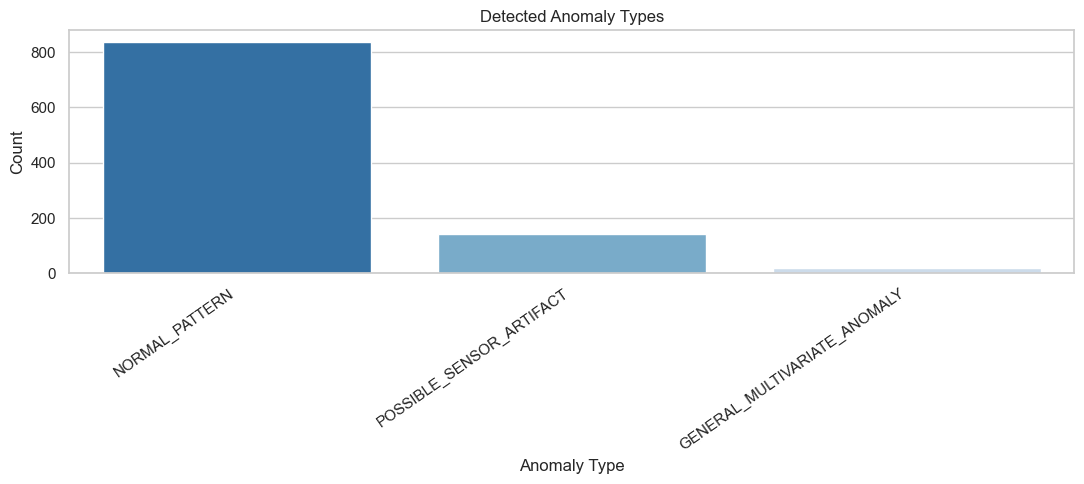

C:\Users\jaymo\AppData\Local\Temp\ipykernel_67308\3647099608.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\jaymo\AppData\Local\Temp\ipykernel_67308\3647099608.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


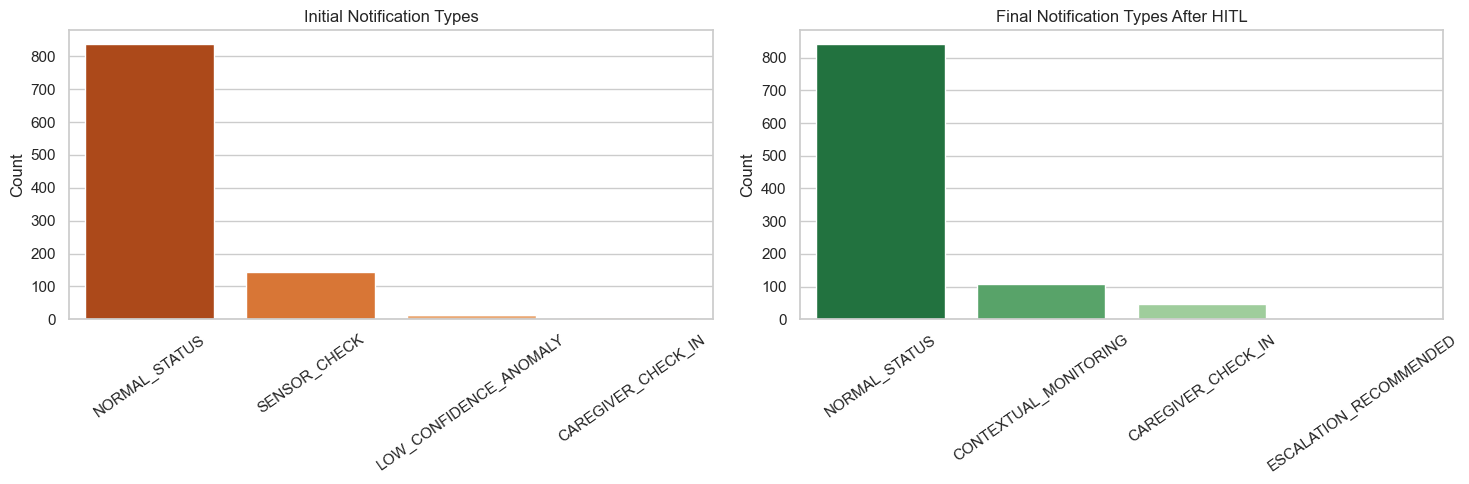

C:\Users\jaymo\AppData\Local\Temp\ipykernel_67308\3647099608.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


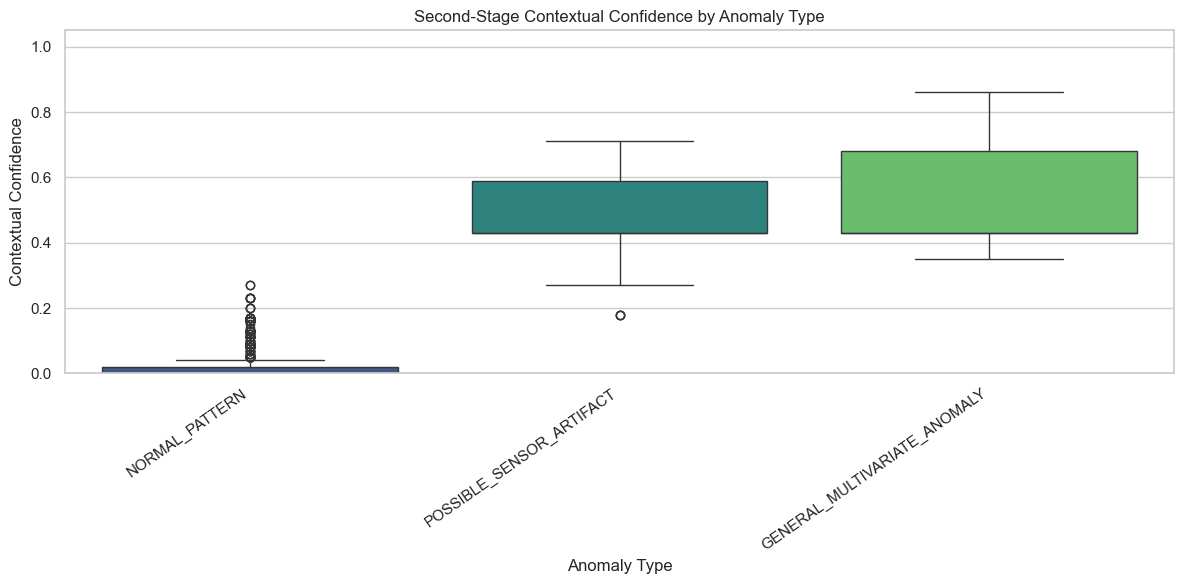

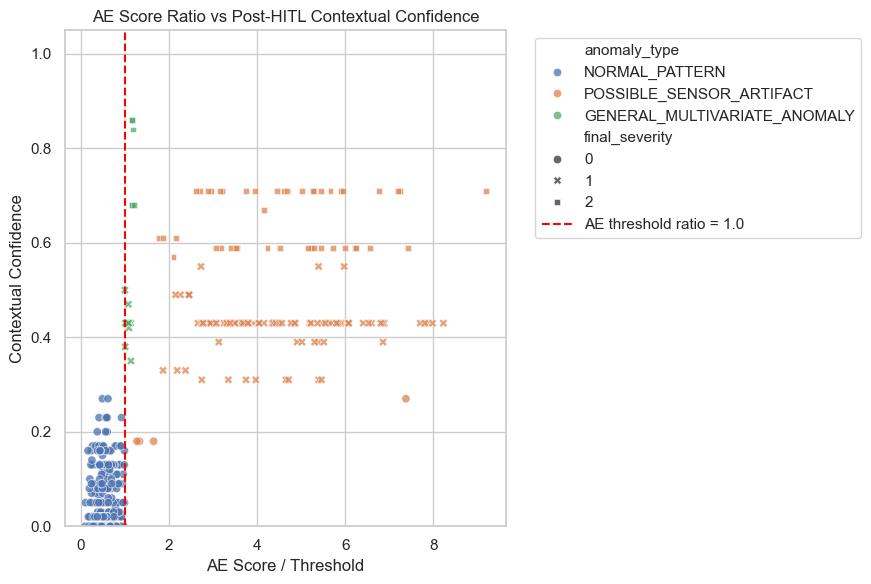

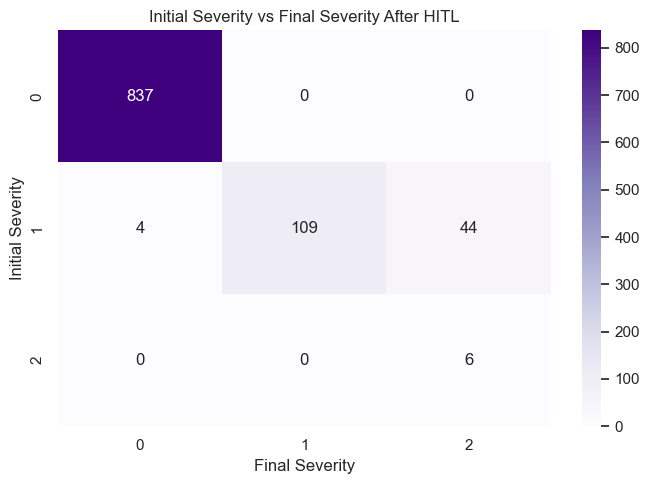

C:\Users\jaymo\AppData\Local\Temp\ipykernel_67308\3647099608.py:116: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=action_counts, x="caregiver_final_action", y="count", palette="Set2")


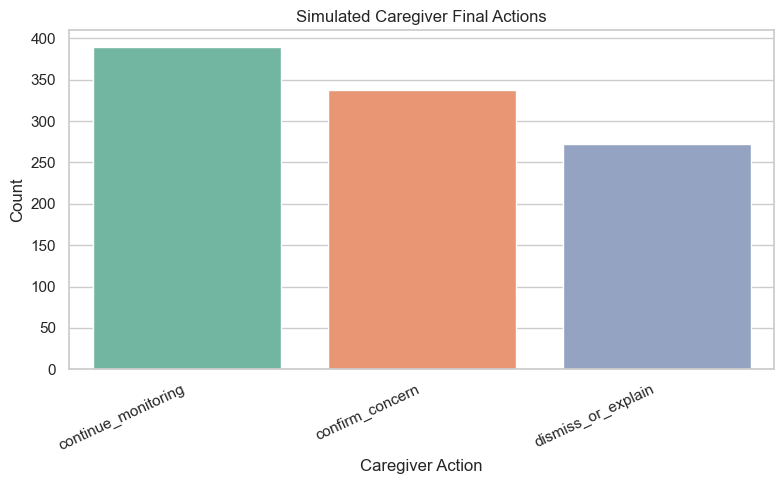

In [28]:
# CELL 9 — PRESENTATION VISUALIZATIONS

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

display(Markdown("## Two-Pass Workflow Visualizations"))

# 1. Anomaly type distribution

plt.figure(figsize=(11, 5))
sns.barplot(data=anomaly_counts, x="anomaly_type", y="count", palette="Blues_r")
plt.title("Detected Anomaly Types")
plt.xlabel("Anomaly Type")
plt.ylabel("Count")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

# 2. Initial vs final notification type

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(
    data=initial_notif_counts,
    x="initial_notification_type",
    y="count",
    palette="Oranges_r",
    ax=axes[0]
)
axes[0].set_title("Initial Notification Types")
axes[0].set_xlabel("")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=35)

sns.barplot(
    data=final_notif_counts,
    x="final_notification_type",
    y="count",
    palette="Greens_r",
    ax=axes[1]
)
axes[1].set_title("Final Notification Types After HITL")
axes[1].set_xlabel("")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=35)

plt.tight_layout()
plt.show()

# 3. Contextual confidence by anomaly type

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=two_pass_events_df,
    x="anomaly_type",
    y="contextual_confidence",
    palette="viridis"
)
plt.title("Second-Stage Contextual Confidence by Anomaly Type")
plt.xlabel("Anomaly Type")
plt.ylabel("Contextual Confidence")
plt.xticks(rotation=35, ha="right")
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

# 4. Score ratio vs contextual confidence

plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=two_pass_events_df,
    x="score_ratio",
    y="contextual_confidence",
    hue="anomaly_type",
    style="final_severity",
    alpha=0.75
)
plt.axvline(1.0, color="red", linestyle="--", label="AE threshold ratio = 1.0")
plt.title("AE Score Ratio vs Post-HITL Contextual Confidence")
plt.xlabel("AE Score / Threshold")
plt.ylabel("Contextual Confidence")
plt.ylim(0, 1.05)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

# 5. Initial vs final severity heatmap

plt.figure(figsize=(7, 5))
sns.heatmap(severity_crosstab, annot=True, fmt="d", cmap="Purples")
plt.title("Initial Severity vs Final Severity After HITL")
plt.xlabel("Final Severity")
plt.ylabel("Initial Severity")
plt.tight_layout()
plt.show()

# 6. Caregiver action counts

plt.figure(figsize=(8, 5))
sns.barplot(data=action_counts, x="caregiver_final_action", y="count", palette="Set2")
plt.title("Simulated Caregiver Final Actions")
plt.xlabel("Caregiver Action")
plt.ylabel("Count")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

## Caregiver Checkbox Observation Analysis

,event_id,anomaly_type,observation_code,observation_label,contextual_confidence,final_severity,final_notification_type
0,uc2_event_0,NORMAL_PATTERN,eating_drinking_less,Eating/drinking less than usual,0.05,0,NORMAL_STATUS
1,uc2_event_1,NORMAL_PATTERN,poor_sleep,Poor sleep,0.00,0,NORMAL_STATUS
2,uc2_event_2,NORMAL_PATTERN,more_tired_weak_confused_not_normal,"More tired, weak, confused, or not acting normal",0.13,0,NORMAL_STATUS
3,uc2_event_3,NORMAL_PATTERN,not_sure,Not sure,0.00,0,NORMAL_STATUS
4,uc2_event_4,NORMAL_PATTERN,nothing_unusual_noticed,Nothing unusual noticed,0.00,0,NORMAL_STATUS
5,uc2_event_4,NORMAL_PATTERN,poor_sleep,Poor sleep,0.00,0,NORMAL_STATUS
6,uc2_event_5,NORMAL_PATTERN,not_sure,Not sure,0.02,0,NORMAL_STATUS
7,uc2_event_6,NORMAL_PATTERN,nothing_unusual_noticed,Nothing unusual noticed,0.00,0,NORMAL_STATUS
8,uc2_event_7,POSSIBLE_SENSOR_ARTIFACT,not_sure,Not sure,0.71,2,CAREGIVER_CHECK_IN
9,uc2_event_8,POSSIBLE_SENSOR_ARTIFACT,nothing_unusual_noticed,Nothing unusual noticed,0.59,2,CAREGIVER_CHECK_IN


### Most Common Simulated Caregiver Observations

,caregiver_observation,count,percent
0,Not sure,346,28.383921
1,Nothing unusual noticed,308,25.266612
2,Stress or emotional upset,131,10.746514
3,Poor sleep,125,10.254307
4,Eating/drinking less than usual,117,9.598031
5,"More tired, weak, confused, or not acting normal",100,8.203445
6,Sensor/watch issue,92,7.547170


C:\Users\jaymo\AppData\Local\Temp\ipykernel_67308\1098498089.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


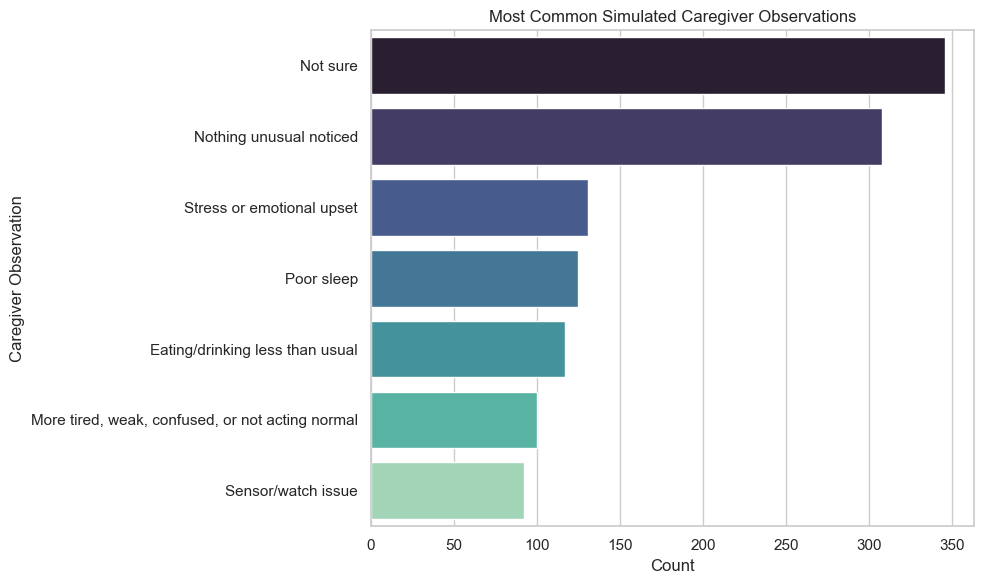

### Caregiver Observations by Anomaly Type

observation_label,Eating/drinking less than usual,"More tired, weak, confused, or not acting normal",Not sure,Nothing unusual noticed,Poor sleep,Sensor/watch issue,Stress or emotional upset
anomaly_type,,,,,,,
GENERAL_MULTIVARIATE_ANOMALY,1,3,6,9,3,0,3
NORMAL_PATTERN,116,97,293,265,122,0,128
POSSIBLE_SENSOR_ARTIFACT,0,0,47,34,0,92,0


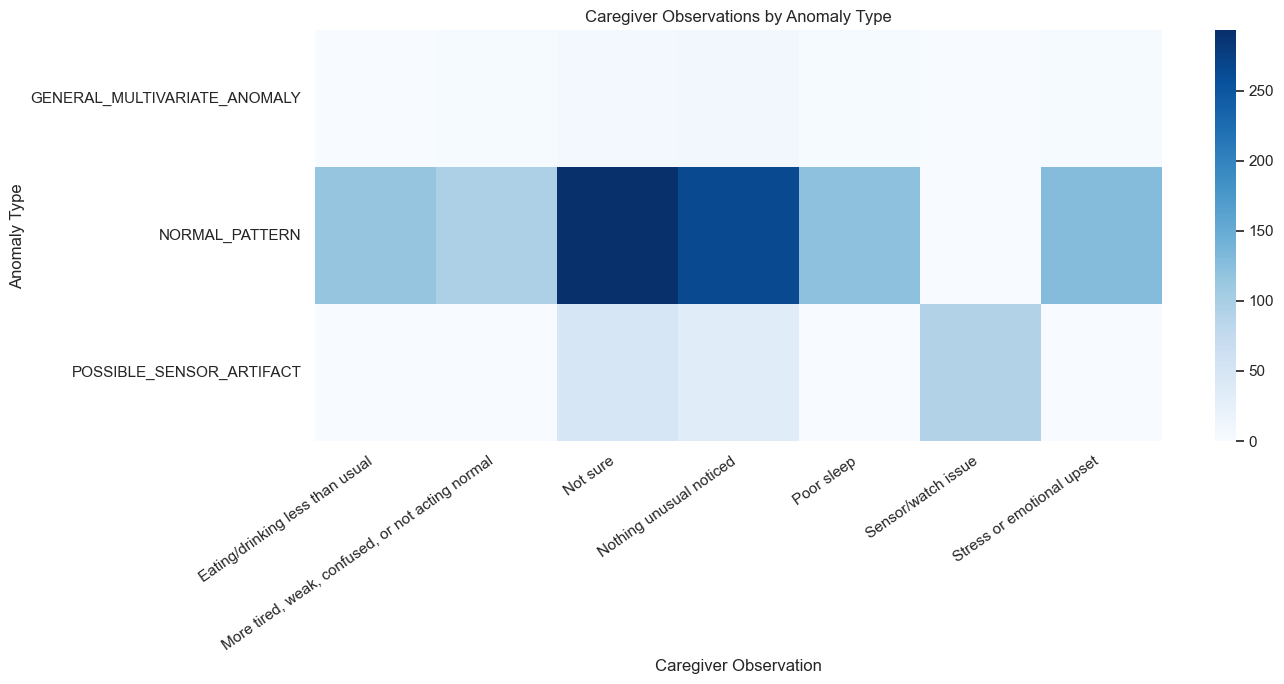

In [29]:
# CELL 10 — CAREGIVER CHECKBOX OPTION ANALYSIS

display(Markdown("## Caregiver Checkbox Observation Analysis"))

# Flatten caregiver observations
obs_rows = []

for _, row in two_pass_events_df.iterrows():
    observations = row["caregiver_observations"]

    if isinstance(observations, list):
        for obs in observations:
            obs_rows.append({
                "event_id": row["event_id"],
                "anomaly_type": row["anomaly_type"],
                "observation_code": obs,
                "observation_label": CAREGIVER_OPTION_LABELS.get(obs, obs),
                "contextual_confidence": row["contextual_confidence"],
                "final_severity": row["final_severity"],
                "final_notification_type": row["final_notification_type"]
            })

caregiver_obs_df = pd.DataFrame(obs_rows)

display(caregiver_obs_df.head(20))

obs_counts = (
    caregiver_obs_df["observation_label"]
    .value_counts()
    .reset_index()
)
obs_counts.columns = ["caregiver_observation", "count"]
obs_counts["percent"] = 100 * obs_counts["count"] / obs_counts["count"].sum()

display(Markdown("### Most Common Simulated Caregiver Observations"))
display(obs_counts)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=obs_counts,
    y="caregiver_observation",
    x="count",
    palette="mako"
)
plt.title("Most Common Simulated Caregiver Observations")
plt.xlabel("Count")
plt.ylabel("Caregiver Observation")
plt.tight_layout()
plt.show()

display(Markdown("### Caregiver Observations by Anomaly Type"))

obs_by_type = pd.crosstab(
    caregiver_obs_df["anomaly_type"],
    caregiver_obs_df["observation_label"]
)

display(obs_by_type)

plt.figure(figsize=(14, 7))
sns.heatmap(obs_by_type, cmap="Blues", annot=False)
plt.title("Caregiver Observations by Anomaly Type")
plt.xlabel("Caregiver Observation")
plt.ylabel("Anomaly Type")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

## Threshold Personalization Recommendations

,anomaly_type,threshold_adjustment_direction,count,mean_adjustment,mean_confidence,mean_score_ratio
1,GENERAL_MULTIVARIATE_ANOMALY,none,16,0.00,0.475000,1.081154
0,GENERAL_MULTIVARIATE_ANOMALY,decrease_threshold_for_patient_anomaly_type,3,-0.03,0.853333,1.172244
2,NORMAL_PATTERN,none,837,0.00,0.027168,0.550077
4,POSSIBLE_SENSOR_ARTIFACT,increase_threshold_for_sensor_artifact_pattern,92,0.04,0.403370,4.518717
5,POSSIBLE_SENSOR_ARTIFACT,none,27,0.00,0.692222,4.445252
3,POSSIBLE_SENSOR_ARTIFACT,decrease_threshold_for_unexplained_high_score,25,-0.02,0.565200,4.427592


### Per-Patient, Per-Anomaly-Type Threshold Recommendations

,patient_id,anomaly_type,event_count,mean_score_ratio,mean_contextual_confidence,total_threshold_adjustment,avg_threshold_adjustment,recommended_personalized_threshold
0,PATIENT_0001,NORMAL_PATTERN,3,0.619128,0.156667,0.00,0.00,1.129848
1,PATIENT_0001,POSSIBLE_SENSOR_ARTIFACT,1,4.909564,0.390000,0.04,0.04,1.175042
2,PATIENT_0002,NORMAL_PATTERN,1,0.836419,0.000000,0.00,0.00,1.129848
3,PATIENT_0003,GENERAL_MULTIVARIATE_ANOMALY,1,1.138905,0.350000,0.00,0.00,1.129848
4,PATIENT_0003,NORMAL_PATTERN,1,0.584019,0.050000,0.00,0.00,1.129848
5,PATIENT_0004,NORMAL_PATTERN,3,0.330304,0.000000,0.00,0.00,1.129848
6,PATIENT_0005,NORMAL_PATTERN,1,0.657321,0.050000,0.00,0.00,1.129848
7,PATIENT_0006,NORMAL_PATTERN,1,0.528834,0.020000,0.00,0.00,1.129848
8,PATIENT_0006,POSSIBLE_SENSOR_ARTIFACT,2,4.071628,0.430000,0.08,0.04,1.220236
9,PATIENT_0007,NORMAL_PATTERN,3,0.562463,0.043333,0.00,0.00,1.129848


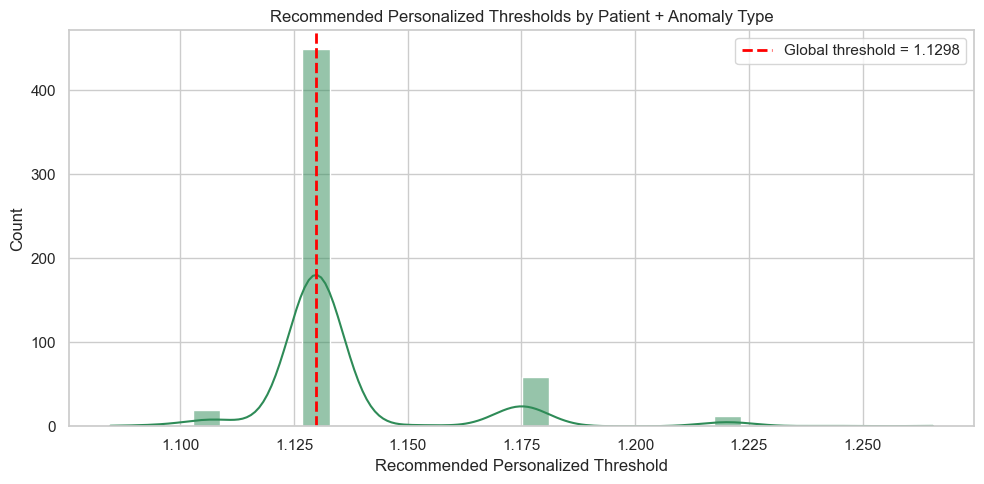


### Interpretation

This table shows how personalization can be done safely around the static AE:

- The AE threshold itself is not retrained live.
- The app stores small adjustment recommendations by `patient_id + anomaly_type`.
- Benign repeated patterns, like `EXERTION_LIKE + exercising`, can slightly increase threshold.
- Concerning repeated patterns, like `LOW_ACTIVITY_HIGH_HR + weak/confused`, can slightly decrease threshold.
- Emergency rule thresholds are never suppressed by personalization.


In [30]:
# CELL 11 — THRESHOLD PERSONALIZATION RECOMMENDATIONS
# This shows how much the threshold would be adjusted based on:
#   - anomaly type
#   - caregiver observations
#   - contextual confidence
#
# This does NOT retrain the AE.
# It produces a per-patient, per-anomaly-type threshold adjustment recommendation.

display(Markdown("## Threshold Personalization Recommendations"))

threshold_adj_summary = (
    two_pass_events_df
    .groupby(["anomaly_type", "threshold_adjustment_direction"])
    .agg(
        count=("event_id", "count"),
        mean_adjustment=("threshold_adjustment_amount", "mean"),
        mean_confidence=("contextual_confidence", "mean"),
        mean_score_ratio=("score_ratio", "mean")
    )
    .reset_index()
    .sort_values(["anomaly_type", "count"], ascending=[True, False])
)

display(threshold_adj_summary)

# Patient + anomaly type personalization table
patient_anomaly_thresholds = (
    two_pass_events_df
    .groupby(["patient_id", "anomaly_type"])
    .agg(
        event_count=("event_id", "count"),
        mean_score_ratio=("score_ratio", "mean"),
        mean_contextual_confidence=("contextual_confidence", "mean"),
        total_threshold_adjustment=("threshold_adjustment_amount", "sum"),
        avg_threshold_adjustment=("threshold_adjustment_amount", "mean")
    )
    .reset_index()
)

patient_anomaly_thresholds["recommended_personalized_threshold"] = (
    float(THRESHOLD) * (1.0 + patient_anomaly_thresholds["total_threshold_adjustment"])
)

# Limit extreme values for prototype safety
patient_anomaly_thresholds["recommended_personalized_threshold"] = patient_anomaly_thresholds[
    "recommended_personalized_threshold"
].clip(
    lower=float(THRESHOLD) * 0.75,
    upper=float(THRESHOLD) * 1.25
)

display(Markdown("### Per-Patient, Per-Anomaly-Type Threshold Recommendations"))
display(patient_anomaly_thresholds.head(25))

plt.figure(figsize=(10, 5))
sns.histplot(
    patient_anomaly_thresholds["recommended_personalized_threshold"],
    bins=30,
    kde=True,
    color="seagreen"
)
plt.axvline(float(THRESHOLD), color="red", linestyle="--", linewidth=2, label=f"Global threshold = {THRESHOLD:.4f}")
plt.title("Recommended Personalized Thresholds by Patient + Anomaly Type")
plt.xlabel("Recommended Personalized Threshold")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

display(Markdown("""
### Interpretation

This table shows how personalization can be done safely around the static AE:

- The AE threshold itself is not retrained live.
- The app stores small adjustment recommendations by `patient_id + anomaly_type`.
- Benign repeated patterns, like `EXERTION_LIKE + exercising`, can slightly increase threshold.
- Concerning repeated patterns, like `LOW_ACTIVITY_HIGH_HR + weak/confused`, can slightly decrease threshold.
- Emergency rule thresholds are never suppressed by personalization.
"""))

In [31]:
# CELL 12 — EXAMPLE JSON PAYLOADS FOR MCP AND SLM

display(Markdown("## Example JSON Payloads"))

# Pick a useful example:
# Prefer one that had final escalation, otherwise first anomaly, otherwise first row.
example_idx = None

escalation_rows = two_pass_events_df[
    two_pass_events_df["final_notification_type"] == "ESCALATION_RECOMMENDED"
]

if len(escalation_rows) > 0:
    example_event_id = escalation_rows.iloc[0]["event_id"]
    example_idx = int(example_event_id.replace("uc2_event_", ""))
else:
    anomaly_rows = two_pass_events_df[two_pass_events_df["ae_anomaly_flag"] == True]
    if len(anomaly_rows) > 0:
        example_event_id = anomaly_rows.iloc[0]["event_id"]
        example_idx = int(example_event_id.replace("uc2_event_", ""))
    else:
        example_idx = 0

display(Markdown("### Initial MCP Payload: after AE + anomaly type classification"))

print(json.dumps(initial_mcp_payloads[example_idx], indent=2, default=str)[:8000])

display(Markdown("### Final SLM Payload: after caregiver HITL + contextual scoring"))

print(json.dumps(final_slm_payloads[example_idx], indent=2, default=str)[:10000])

display(Markdown("""
### Presentation Explanation

The first JSON is the initial machine-generated report:

`AE score + threshold + anomaly type + top abnormal features + raw vitals + notification severity`

The second JSON is generated after caregiver input:

`initial ML evidence + caregiver observations + caregiver history + contextual confidence + final notification`

The SLM should only interpret this second JSON into safe caregiver-facing language.  
It should not be the component that decides whether an anomaly exists.
"""))

## Example JSON Payloads

### Initial MCP Payload: after AE + anomaly type classification

{
  "event_type": "TRIGGER_WORKFLOW_ANOMALY_TYPE_04",
  "stage": "initial_ml_detection",
  "event_id": "uc2_event_396",
  "patient_id": "PATIENT_0320",
  "timestamp": "2025-10-11 00:35:45.056387",
  "model_version": "tiny_ae_uc2_v0.1.0",
  "ae_score": 1.3116633892059326,
  "threshold": 1.1298478841781616,
  "score_ratio": 1.1609203394313754,
  "anomaly_detected": true,
  "anomaly_type": "GENERAL_MULTIVARIATE_ANOMALY",
  "top_abnormal_features": [],
  "raw_vitals": {},
  "rule_engine": {
    "is_emergency": false,
    "emergency_reasons": [],
    "emergency_severity": 0
  },
  "initial_notification": {
    "notification_type": "CAREGIVER_CHECK_IN",
    "severity": 2,
    "reason": "AE score clearly above threshold.",
    "config": {
      "severity": 2,
      "delivery": "standard_push",
      "sound": true,
      "vibration": true,
      "requires_caregiver_action": true,
      "slm_enabled": true
    }
  },
  "recommended_next_step": "caregiver_check_in"
}


### Final SLM Payload: after caregiver HITL + contextual scoring

{
  "event_type": "TRIGGER_WORKFLOW_ANOMALY_TYPE_04",
  "stage": "post_hitl_contextual_scoring",
  "event_id": "uc2_event_396",
  "patient_id": "PATIENT_0320",
  "timestamp": "2025-10-11 00:35:45.056387",
  "model_version": "tiny_ae_uc2_v0.1.0",
  "initial_ml_report": {
    "ae_score": 1.3116633892059326,
    "threshold": 1.1298478841781616,
    "score_ratio": 1.1609203394313754,
    "anomaly_detected": true,
    "anomaly_type": "GENERAL_MULTIVARIATE_ANOMALY",
    "top_abnormal_features": [],
    "raw_vitals": {},
    "rule_engine": {
      "is_emergency": false,
      "emergency_reasons": [],
      "emergency_severity": 0
    },
    "initial_notification_type": "CAREGIVER_CHECK_IN",
    "initial_severity": 2
  },
  "caregiver_hitl": {
    "selected_options": [
      "not_sure",
      "more_tired_weak_confused_not_normal"
    ],
    "selected_option_labels": [
      "Not sure",
      "More tired, weak, confused, or not acting normal"
    ],
    "final_action": "confirm_concern",
    "c


### Presentation Explanation

The first JSON is the initial machine-generated report:

`AE score + threshold + anomaly type + top abnormal features + raw vitals + notification severity`

The second JSON is generated after caregiver input:

`initial ML evidence + caregiver observations + caregiver history + contextual confidence + final notification`

The SLM should only interpret this second JSON into safe caregiver-facing language.  
It should not be the component that decides whether an anomaly exists.


In [32]:
# CELL 13 — FINAL PRESENTATION SUMMARY

display(Markdown("## Final Two-Pass Architecture Summary"))

final_two_pass_summary = {
    "architecture": "Two-pass ML + HITL workflow",
    "use_case": "UC2 slow-path anomaly detection",
    "event_type": "TRIGGER_WORKFLOW_ANOMALY_TYPE_04",
    "model_version": MODEL_VERSION,
    "global_ae_threshold": float(THRESHOLD),

    "pass_1": {
        "description": "Continuous anomaly detection using tiny AE.",
        "inputs": [
            "raw vitals",
            "engineered features",
            "AE reconstruction score",
            "rule engine result"
        ],
        "outputs": [
            "anomaly flag",
            "score ratio",
            "top abnormal features",
            "anomaly type",
            "initial notification severity",
            "initial MCP JSON payload"
        ]
    },

    "caregiver_hitl": {
        "description": "Structured checkbox observations collected from caregiver.",
        "options": CAREGIVER_OPTIONS
    },

    "pass_2": {
        "description": "Lightweight contextual decision layer.",
        "inputs": [
            "AE reconstruction score",
            "anomaly type",
            "top abnormal features",
            "caregiver observations",
            "caregiver confirmation/override history",
            "emergency rule result"
        ],
        "outputs": [
            "contextual confidence score",
            "risk level",
            "final notification type",
            "final notification severity",
            "threshold personalization recommendation",
            "final SLM JSON payload"
        ]
    },

    "important_limitations": [
        "The tiny AE is still a static inference model.",
        "The second-stage confidence score is a prototype routing score, not a clinically calibrated probability.",
        "Caregiver feedback is simulated because the dataset does not contain real caregiver observations.",
        "Personalization changes profile/threshold recommendations, not live AE weights.",
        "Emergency rule thresholds must not be suppressed by personalization."
    ],

    "rows_processed": int(len(two_pass_events_df)),
    "ae_anomaly_flags": int(two_pass_events_df["ae_anomaly_flag"].sum()),
    "emergency_events": int(two_pass_events_df["is_emergency"].sum()),
    "mean_contextual_confidence": float(two_pass_events_df["contextual_confidence"].mean())
}

print(json.dumps(final_two_pass_summary, indent=2, default=str))

display(Markdown("""
## Short Supervisor Explanation

I extended the HITL notebook into a two-pass workflow.

First, the tiny autoencoder continuously detects unusual vital patterns and classifies the anomaly type based on which features are abnormal.  
That first pass generates an initial JSON payload for MCP with the AE score, threshold, anomaly type, top abnormal vitals, raw vitals, and initial notification severity.

Then the notebook simulates structured caregiver observations using checkbox-style responses.  
A second lightweight decision layer combines the AE score, anomaly type, abnormal features, caregiver observations, caregiver history, and emergency rule result to produce a contextual confidence score.

The final output is a second JSON payload for the SLM.  
The SLM can use that structured context to produce a safe caregiver-facing response, while the ML/decision layer remains responsible for anomaly detection and severity routing.
"""))

## Final Two-Pass Architecture Summary

{
  "architecture": "Two-pass ML + HITL workflow",
  "use_case": "UC2 slow-path anomaly detection",
  "event_type": "TRIGGER_WORKFLOW_ANOMALY_TYPE_04",
  "model_version": "tiny_ae_uc2_v0.1.0",
  "global_ae_threshold": 1.1298478841781616,
  "pass_1": {
    "description": "Continuous anomaly detection using tiny AE.",
    "inputs": [
      "raw vitals",
      "engineered features",
      "AE reconstruction score",
      "rule engine result"
    ],
    "outputs": [
      "anomaly flag",
      "score ratio",
      "top abnormal features",
      "anomaly type",
      "initial notification severity",
      "initial MCP JSON payload"
    ]
  },
  "caregiver_hitl": {
    "description": "Structured checkbox observations collected from caregiver.",
    "options": [
      "exercising_increased_activity",
      "poor_sleep",
      "stress_or_emotional_upset",
      "eating_drinking_less",
      "missed_or_changed_medication",
      "bathroom_changes",
      "vomiting_or_diarrhea",
      "more_tire


## Short Supervisor Explanation

I extended the HITL notebook into a two-pass workflow.

First, the tiny autoencoder continuously detects unusual vital patterns and classifies the anomaly type based on which features are abnormal.  
That first pass generates an initial JSON payload for MCP with the AE score, threshold, anomaly type, top abnormal vitals, raw vitals, and initial notification severity.

Then the notebook simulates structured caregiver observations using checkbox-style responses.  
A second lightweight decision layer combines the AE score, anomaly type, abnormal features, caregiver observations, caregiver history, and emergency rule result to produce a contextual confidence score.

The final output is a second JSON payload for the SLM.  
The SLM can use that structured context to produce a safe caregiver-facing response, while the ML/decision layer remains responsible for anomaly detection and severity routing.
